In [1]:
from experiments.dj.result_tables import FlowPriorResult
from experiments.dj.prior_tables import FlowPriorConfig
from experiments.dj.dataloader_tables import DataLoaderConfig
from experiments.dj.trainer_tables import FPTrainerConfig
from experiments.dj.evaluation_tables import FlowPriorEval
from task_transfer.evaluation.evaluate_generative_model import evaluate_flow_prior
from task_transfer.ml_lib.data_loading import build_dataloaders

import torch

[2024-07-10 01:44:01,894][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-07-10 01:44:03,139][INFO]: Connected sshrinivasan@134.76.19.44:3306


In [2]:
fp_cols = [col for col in FlowPriorConfig.heading if col != 'id']
dl_cols = [col for col in DataLoaderConfig.heading if col != 'id']
trainer_cols = [col for col in FPTrainerConfig.heading if col != 'id']

result_table = FlowPriorResult() * FlowPriorConfig.proj(fp_id="id", *fp_cols) * DataLoaderConfig.proj(dl_id="id", *dl_cols) * FPTrainerConfig.proj(trainer_id="id", *trainer_cols)

In [3]:
result_table & "flow_base_dist = 'normal'" & "affine_type = 'factorized'"

fp_id,trainer_id,dl_id,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,tracker_output,eval_output,model,seed,flow_depth,flow_initial_nonlin flow direction is data -> latent,flow_final_nonlin,flow_nonlin,flow_base_dist,affine_type,data_fname,train_prop,val_prop,lr,weight_decay,n_epochs,batch_size,early_stopping_threshold,early_stopping_patience
0626e82eec85ade7041703d85e168d5b,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-126.7267837524414,1.5894485712051392,-126.70783996582031,2.9417123794555664,-126.70783996582031,2.9417123794555664,=BLOB=,=BLOB=,=BLOB=,42,3,inv_softplus,none,leaky_relu,normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,600,128,10,10
474d2c24ed78a9bb4a22f29f0808468e,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-128.6599578857422,1.5725089311599731,-128.52574157714844,2.855788469314575,-128.52574157714844,2.855788469314575,=BLOB=,=BLOB=,=BLOB=,42,2,inv_softplus,none,leaky_relu,normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,600,128,10,10
487c591ff55ca28abc4c4126d0c5e484,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-51.56180953979492,1.2037588357925415,-51.34552764892578,2.255808115005493,-51.34552764892578,2.255808115005493,=BLOB=,=BLOB=,=BLOB=,100,2,inv_softplus,none,tanh,normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,600,128,10,10
5e738abbecc2e0e4925c7778036a1aa7,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-127.46085357666016,1.4830366373062134,-127.53753662109375,2.700312852859497,-127.53753662109375,2.700312852859497,=BLOB=,=BLOB=,=BLOB=,100,3,inv_softplus,none,leaky_relu,normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,600,128,10,10
d0cf491f03b7f839c8a54834a6168081,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-51.561302185058594,1.2098212242126465,-51.34160614013672,2.267972469329834,-51.34160614013672,2.267972469329834,=BLOB=,=BLOB=,=BLOB=,42,2,inv_softplus,none,tanh,normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,600,128,10,10
ed7269c2e65f26b97f5fc6031445ccd6,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-130.4494171142578,1.6294491291046143,-130.27793884277344,2.989567518234253,-130.27793884277344,2.989567518234253,=BLOB=,=BLOB=,=BLOB=,100,2,inv_softplus,none,leaky_relu,normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,600,128,10,10
f14ea0efe1d84f1008c1b452ec9cdc2a,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-51.57347869873047,1.2137374877929688,-51.3455810546875,2.2747411727905273,-51.3455810546875,2.2747411727905273,=BLOB=,=BLOB=,=BLOB=,100,3,inv_softplus,none,tanh,normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,600,128,10,10
fd41e0ac4ce4840783241091705b56c1,c40a50ce9c77369770dddd5129836477,260a5ea8175f75eaef132f42873ad14a,-51.585933685302734,1.2055480480194092,-51.356239318847656,2.2593023777008057,-51.356239318847656,2.2593023777008057,=BLOB=,=BLOB=,=BLOB=,42,3,inv_softplus,none,tanh,normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2,0.001,0.001,600,128,10,10
0626e82eec85ade7041703d85e168d5b,f89651063b51487dcdf4041336ef89db,260a5ea8175f75eaef132f42873ad14a,-123.26030731201172,1.62436842918396,-123.29173278808594,3.0070111751556396,-123.29173278808594,3.0070111751556396,=BLOB=,=BLOB=,=BLOB=,42,3,inv_softplus,none,leaky_relu,normal,factorized,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_data

In [4]:
best_val = (result_table & "flow_base_dist = 'normal'" & "affine_type = 'factorized'").fetch(
    download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True)[0]

In [5]:
best_val

{'fp_id': 'd0cf491f03b7f839c8a54834a6168081',
 'trainer_id': 'c40a50ce9c77369770dddd5129836477',
 'dl_id': '260a5ea8175f75eaef132f42873ad14a',
 'train_ll_mean': -51.561302185058594,
 'train_ll_sem': 1.2098212242126465,
 'val_ll_mean': -51.34160614013672,
 'val_ll_sem': 2.267972469329834,
 'test_ll_mean': -51.34160614013672,
 'test_ll_sem': 2.267972469329834,
 'tracker_output': '/tmp/d0cf491f03b7f839c8a54834a6168081_c40a50ce9c77369770dddd5129836477_260a5ea8175f75eaef132f42873ad14a_tracker_output.pkl',
 'eval_output': '/tmp/d0cf491f03b7f839c8a54834a6168081_c40a50ce9c77369770dddd5129836477_260a5ea8175f75eaef132f42873ad14a_eval_output.pkl',
 'model': '/tmp/d0cf491f03b7f839c8a54834a6168081_c40a50ce9c77369770dddd5129836477_260a5ea8175f75eaef132f42873ad14a_model.pt',
 'seed': 42,
 'flow_depth': 2,
 'flow_initial_nonlin': 'inv_softplus',
 'flow_final_nonlin': 'none',
 'flow_nonlin': 'tanh',
 'flow_base_dist': 'normal',
 'affine_type': 'factorized',
 'data_fname': '/src/project/data/synthetic/h

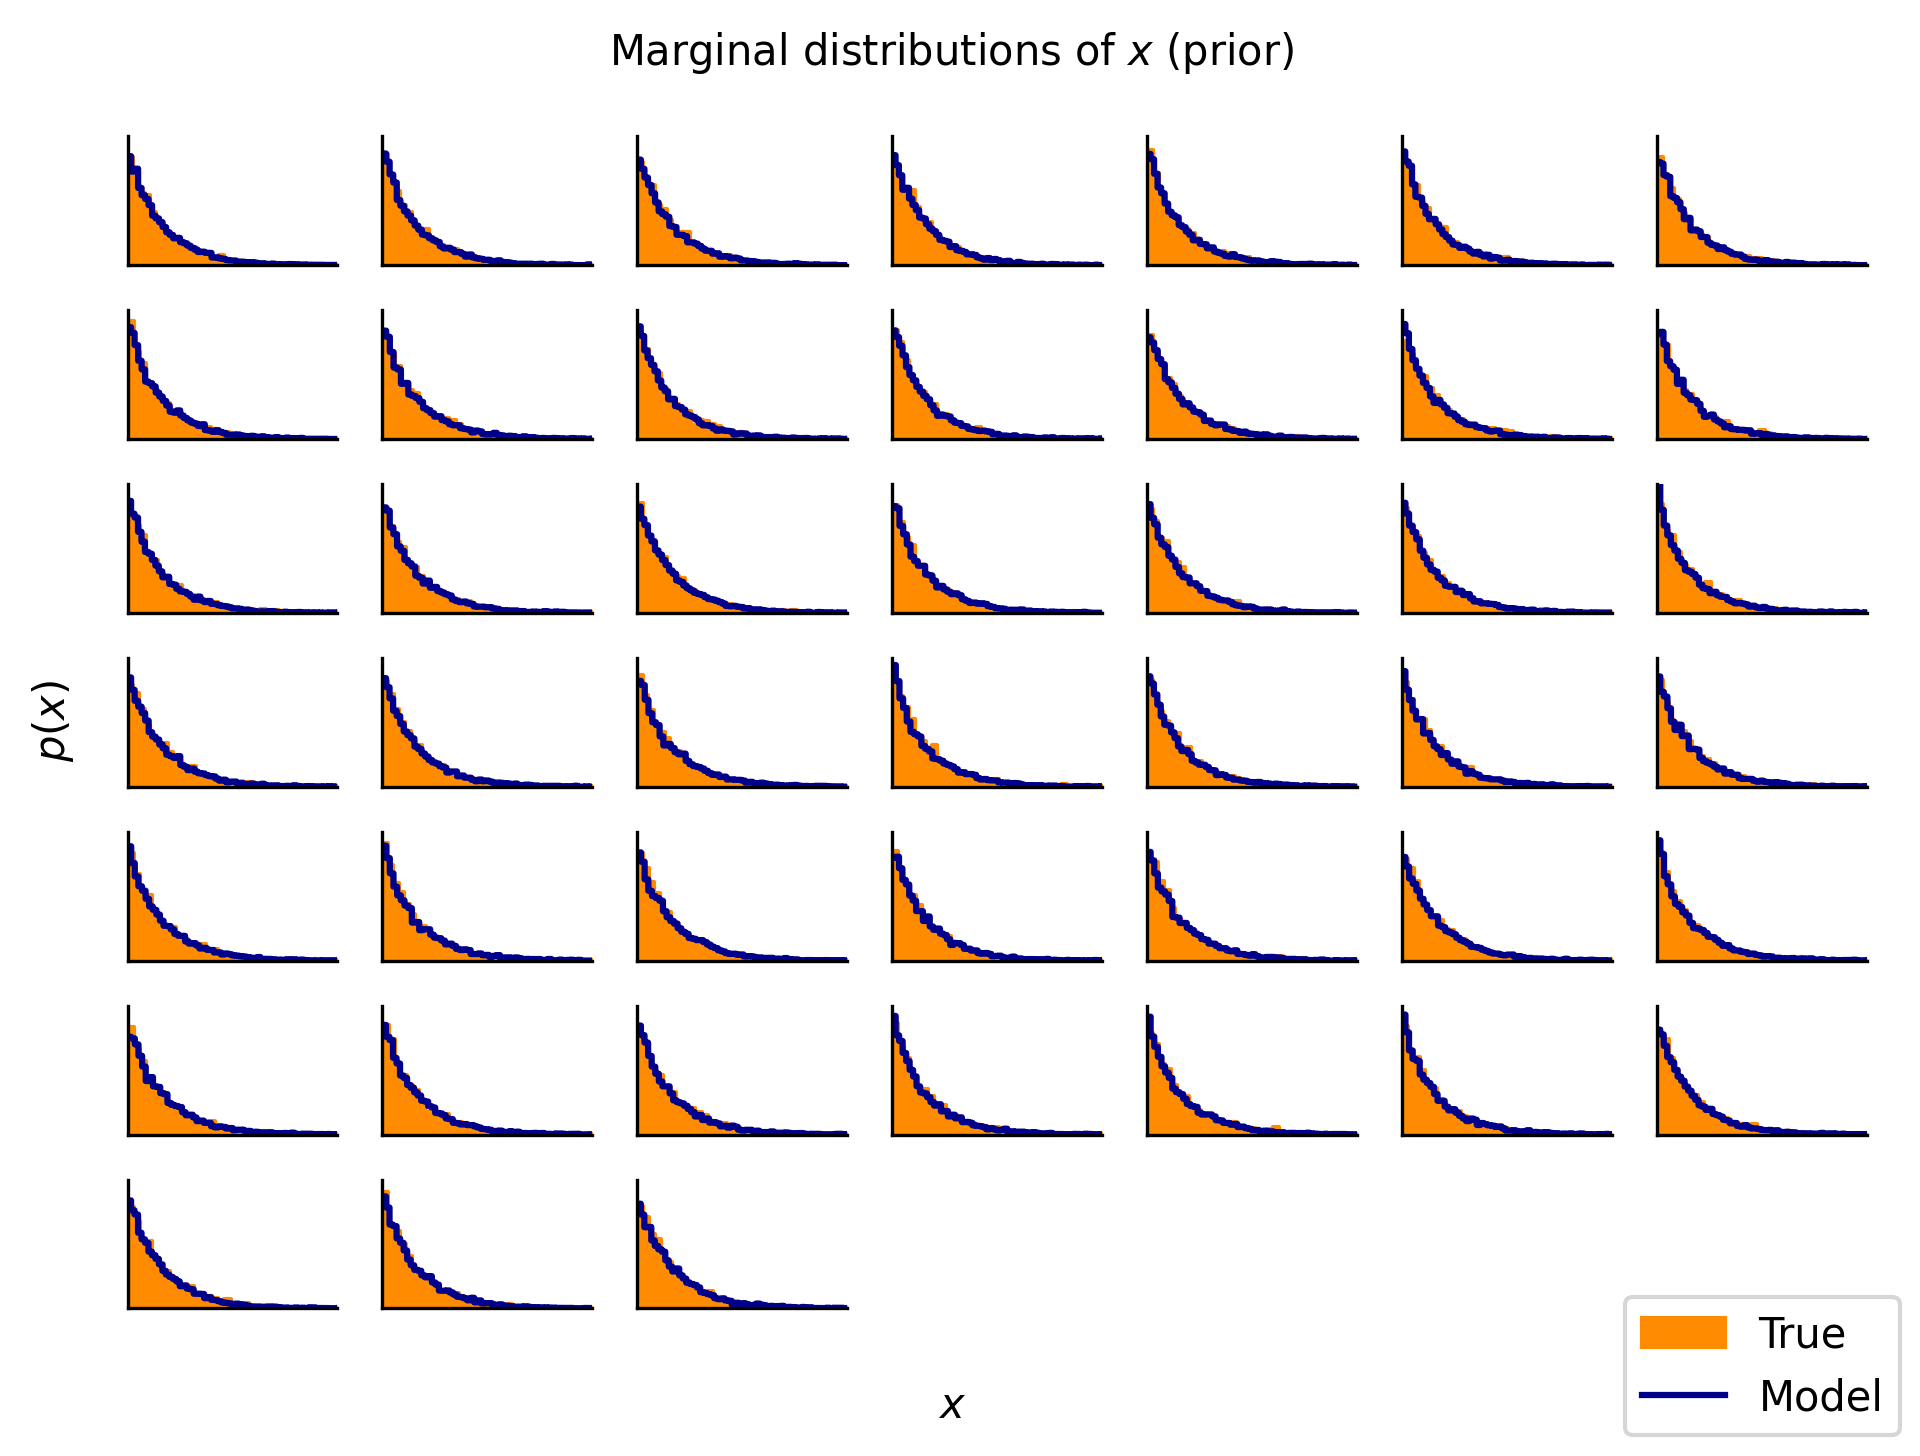

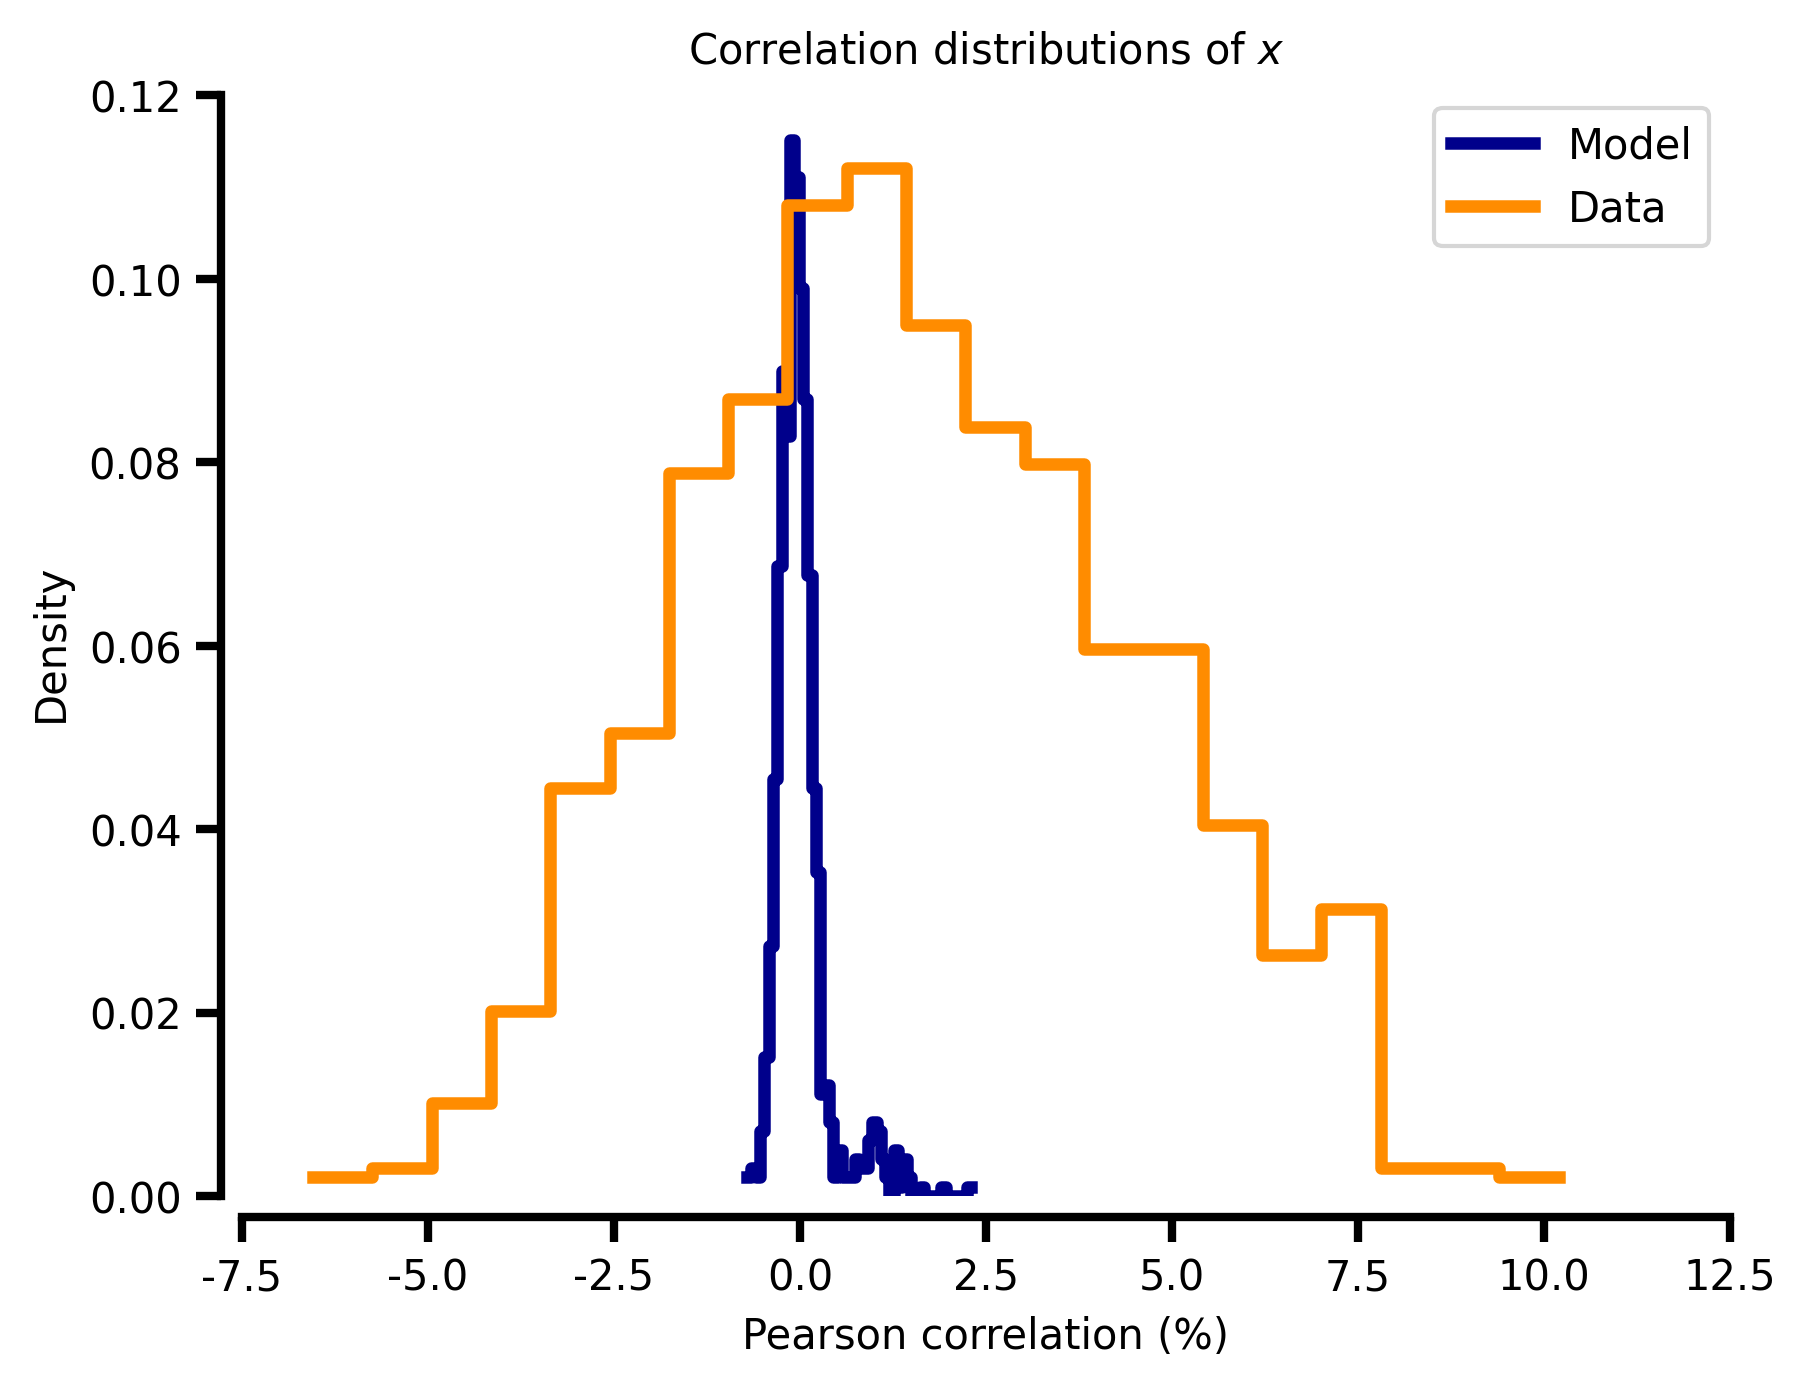

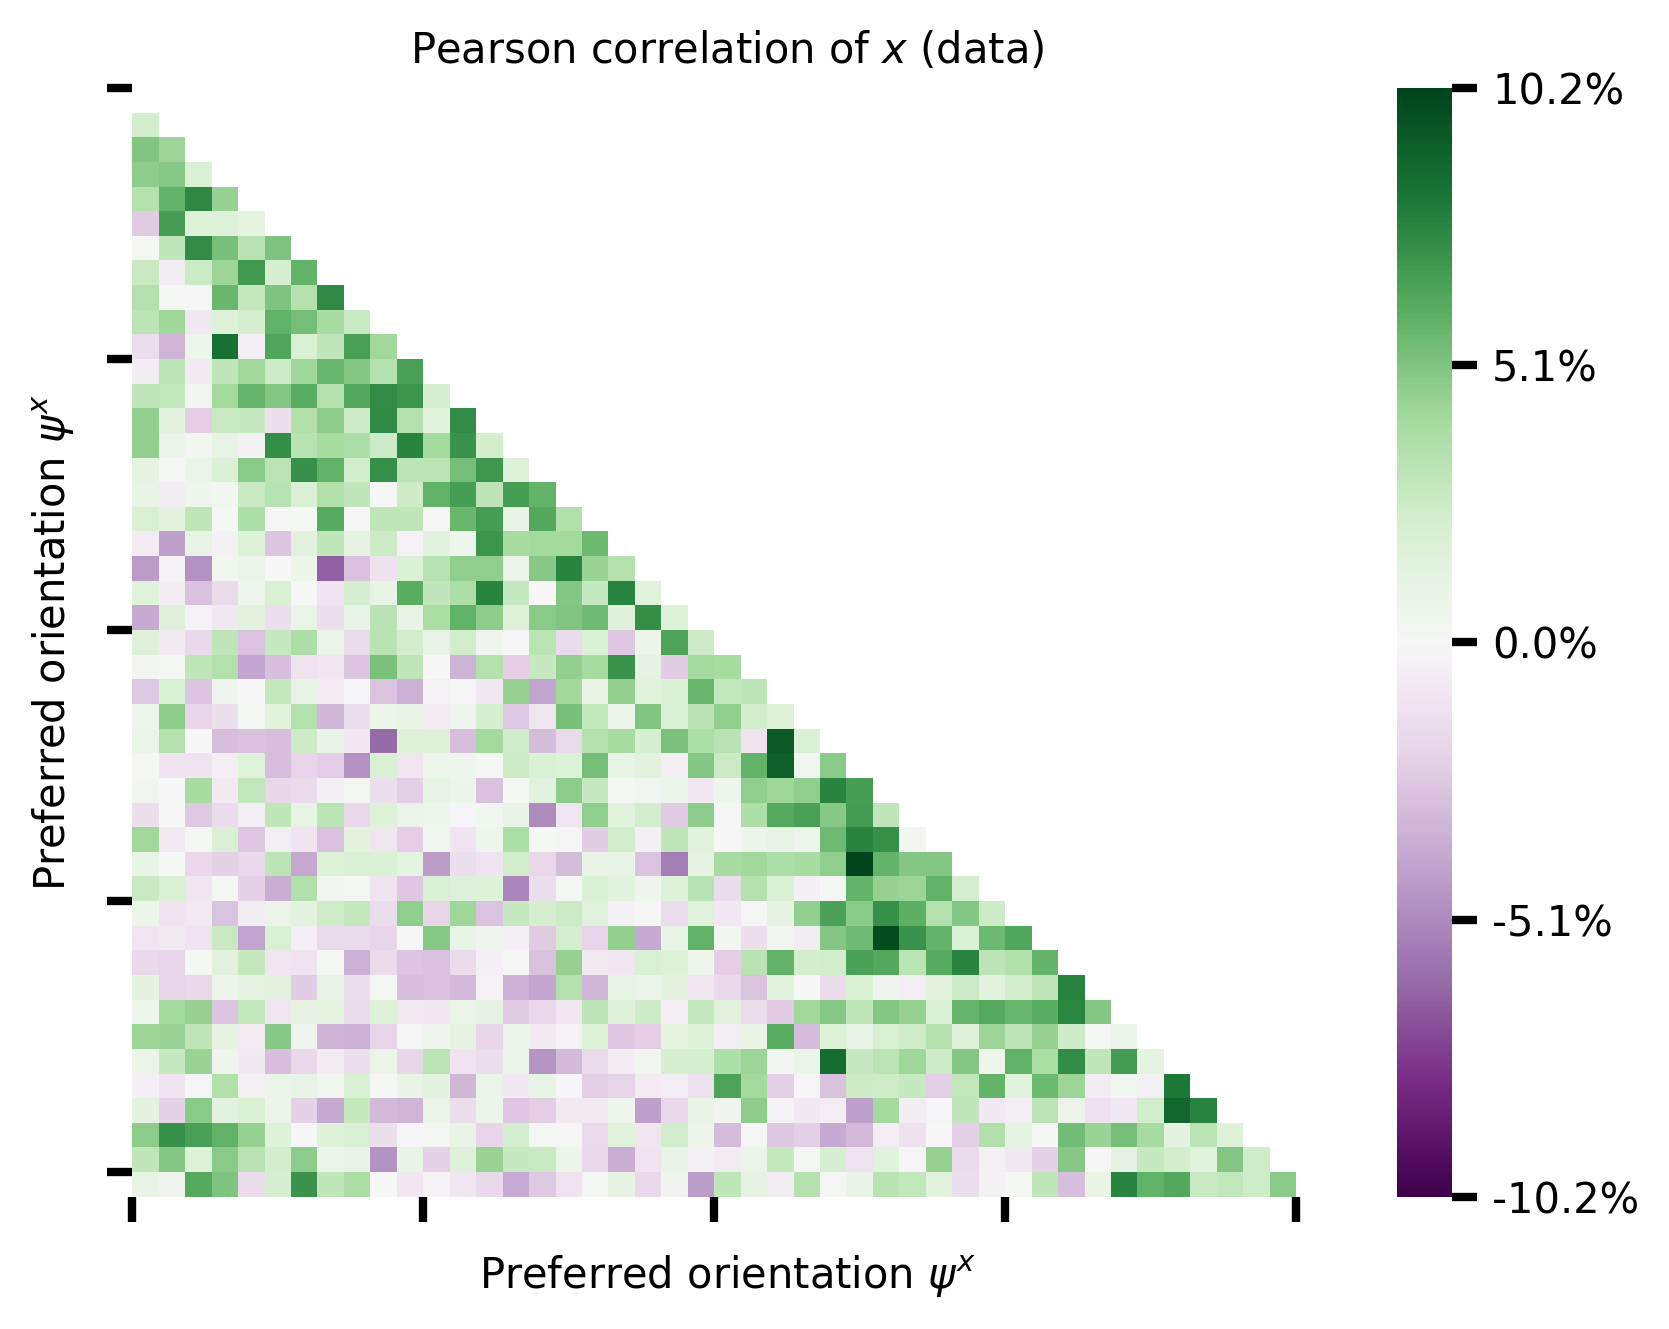

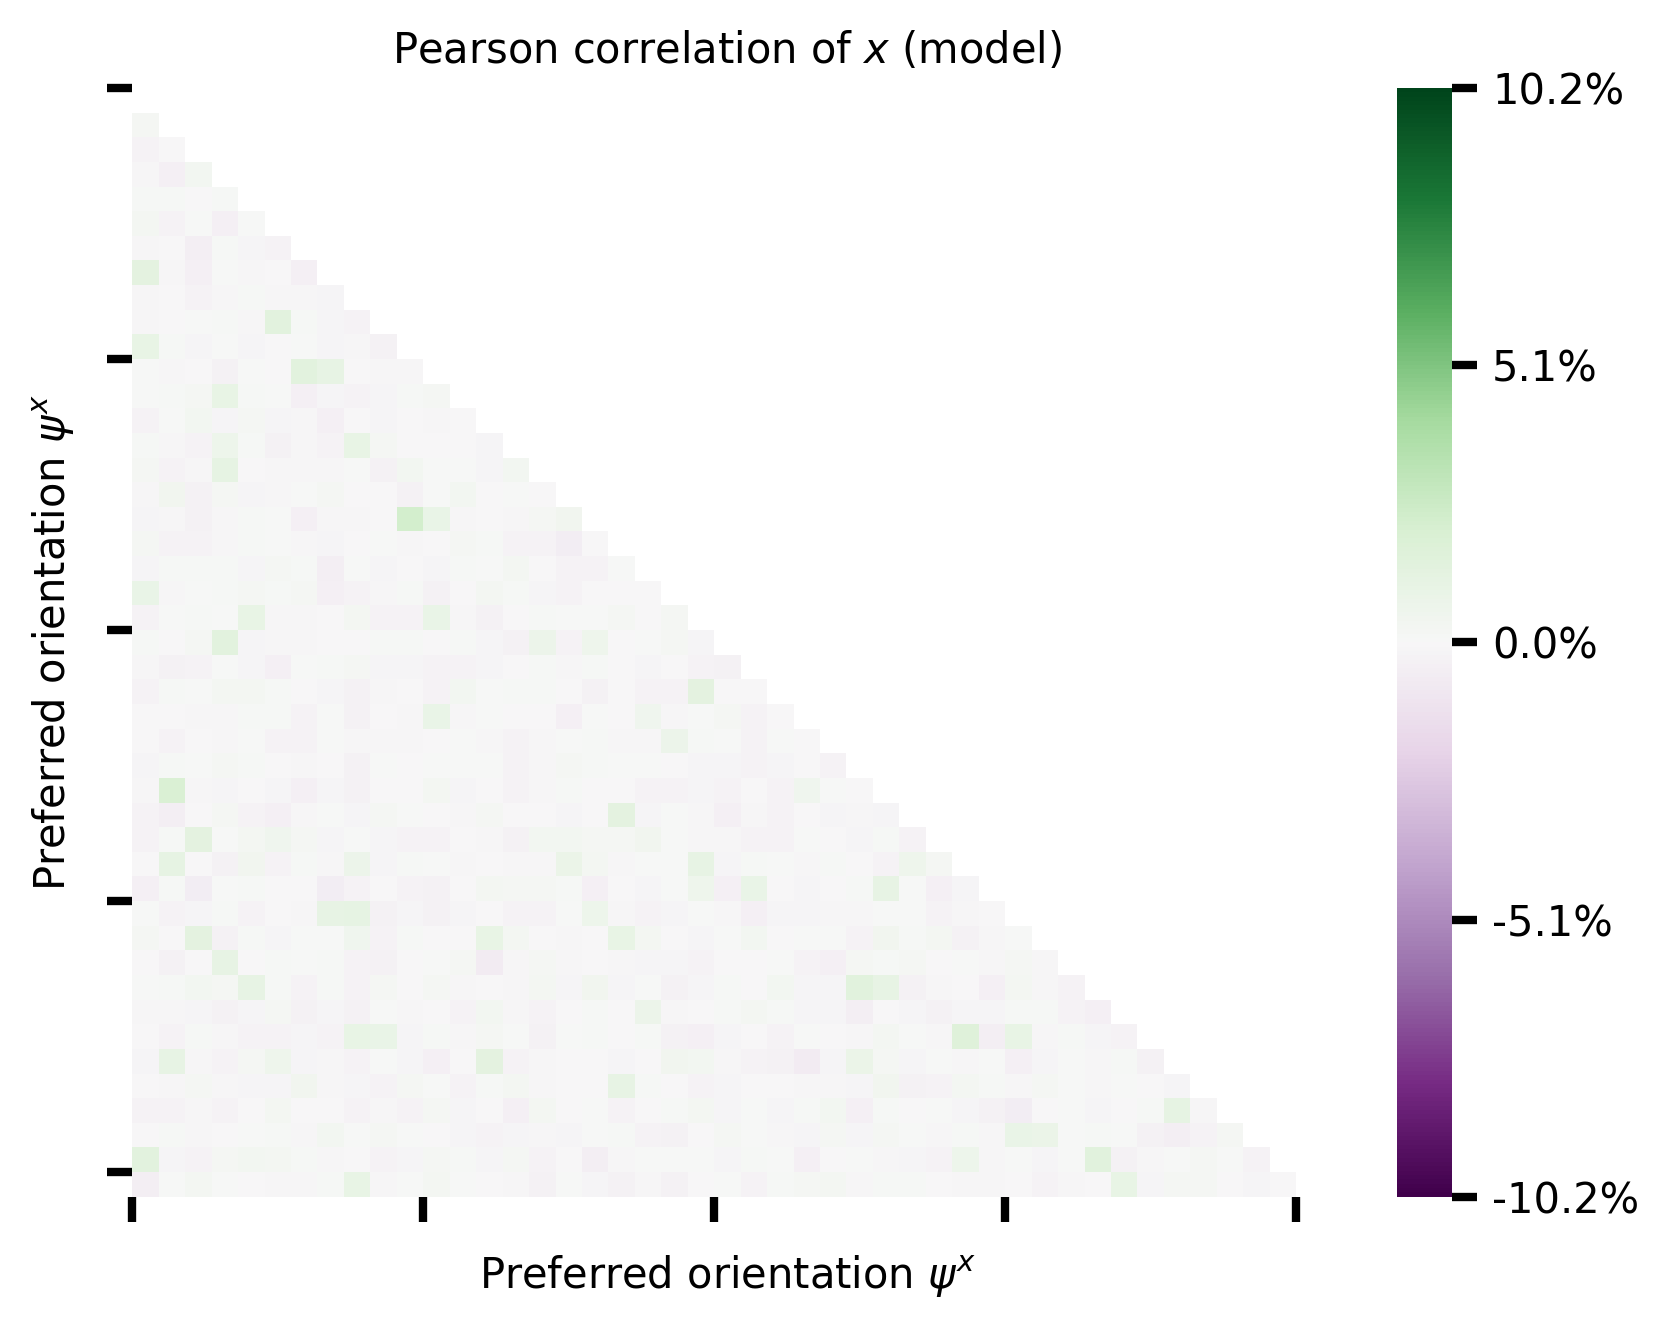

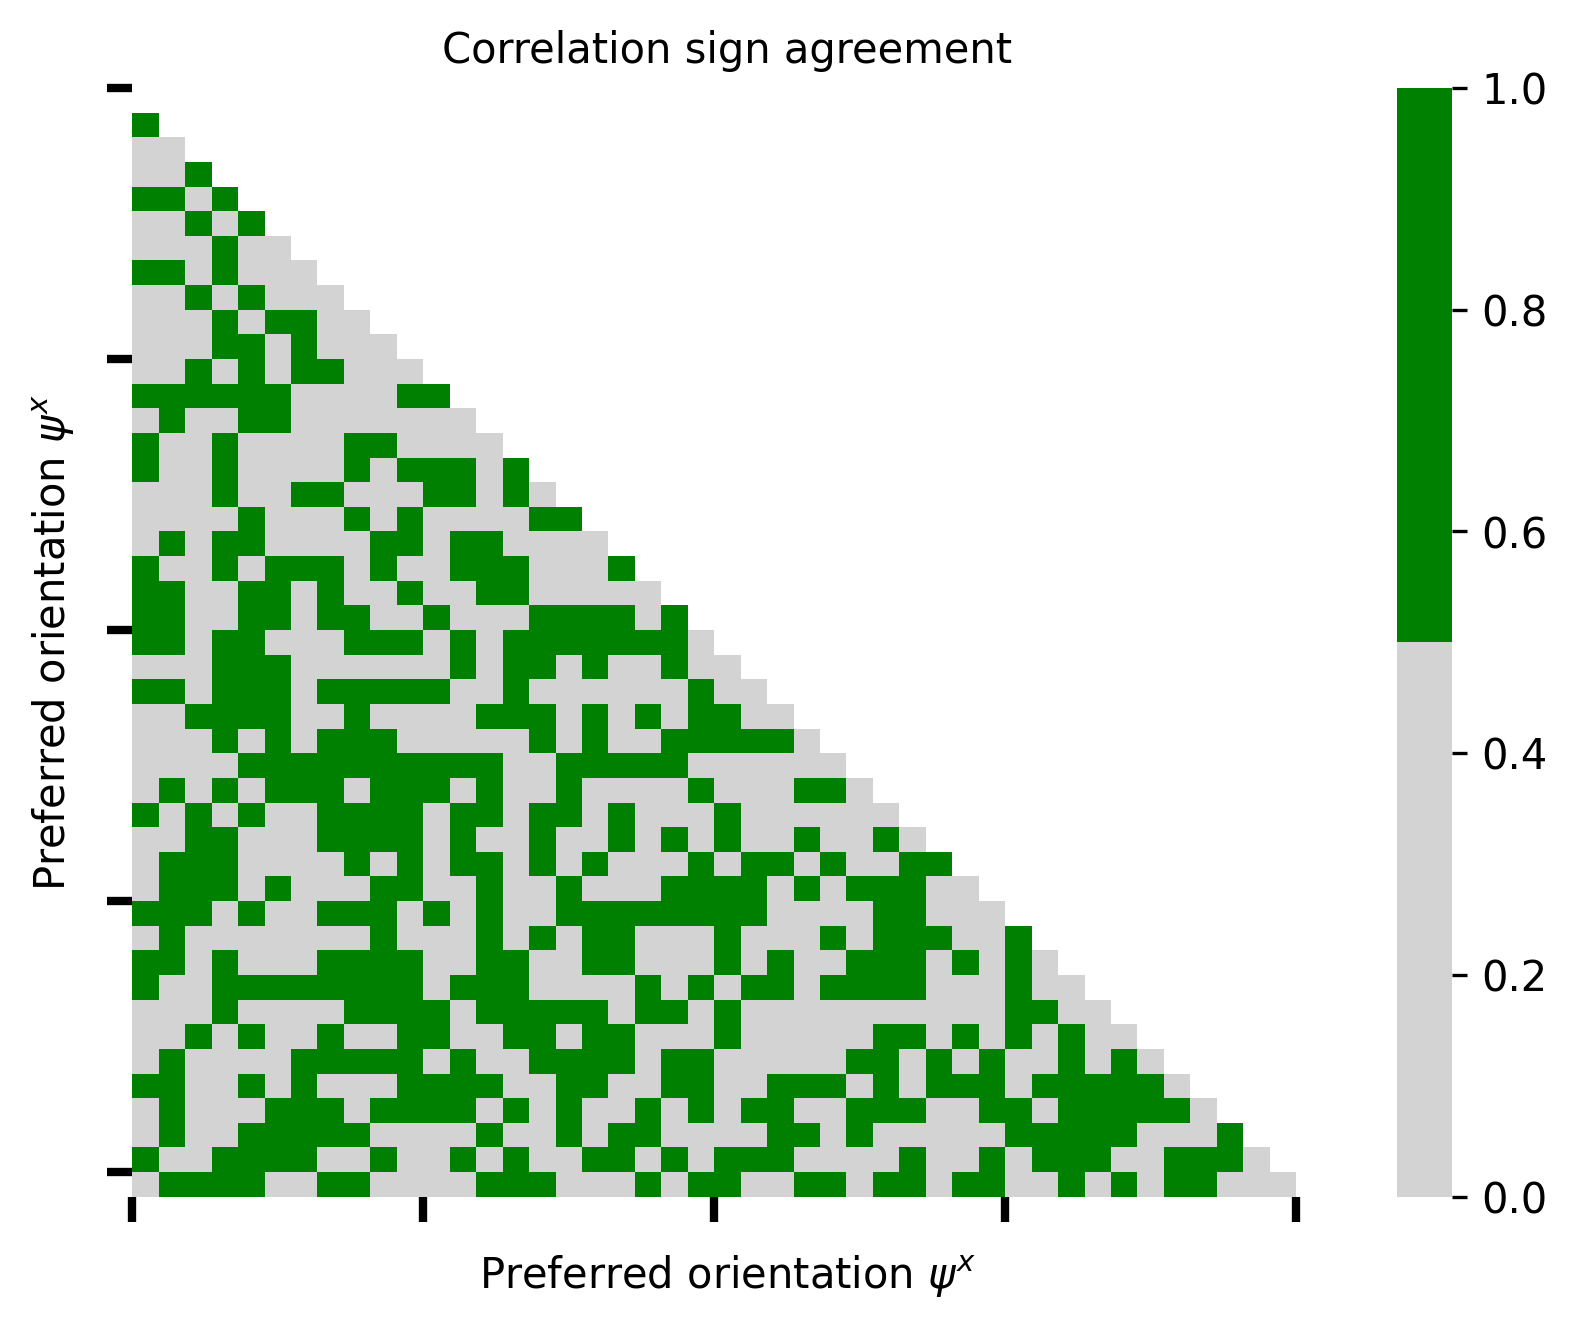

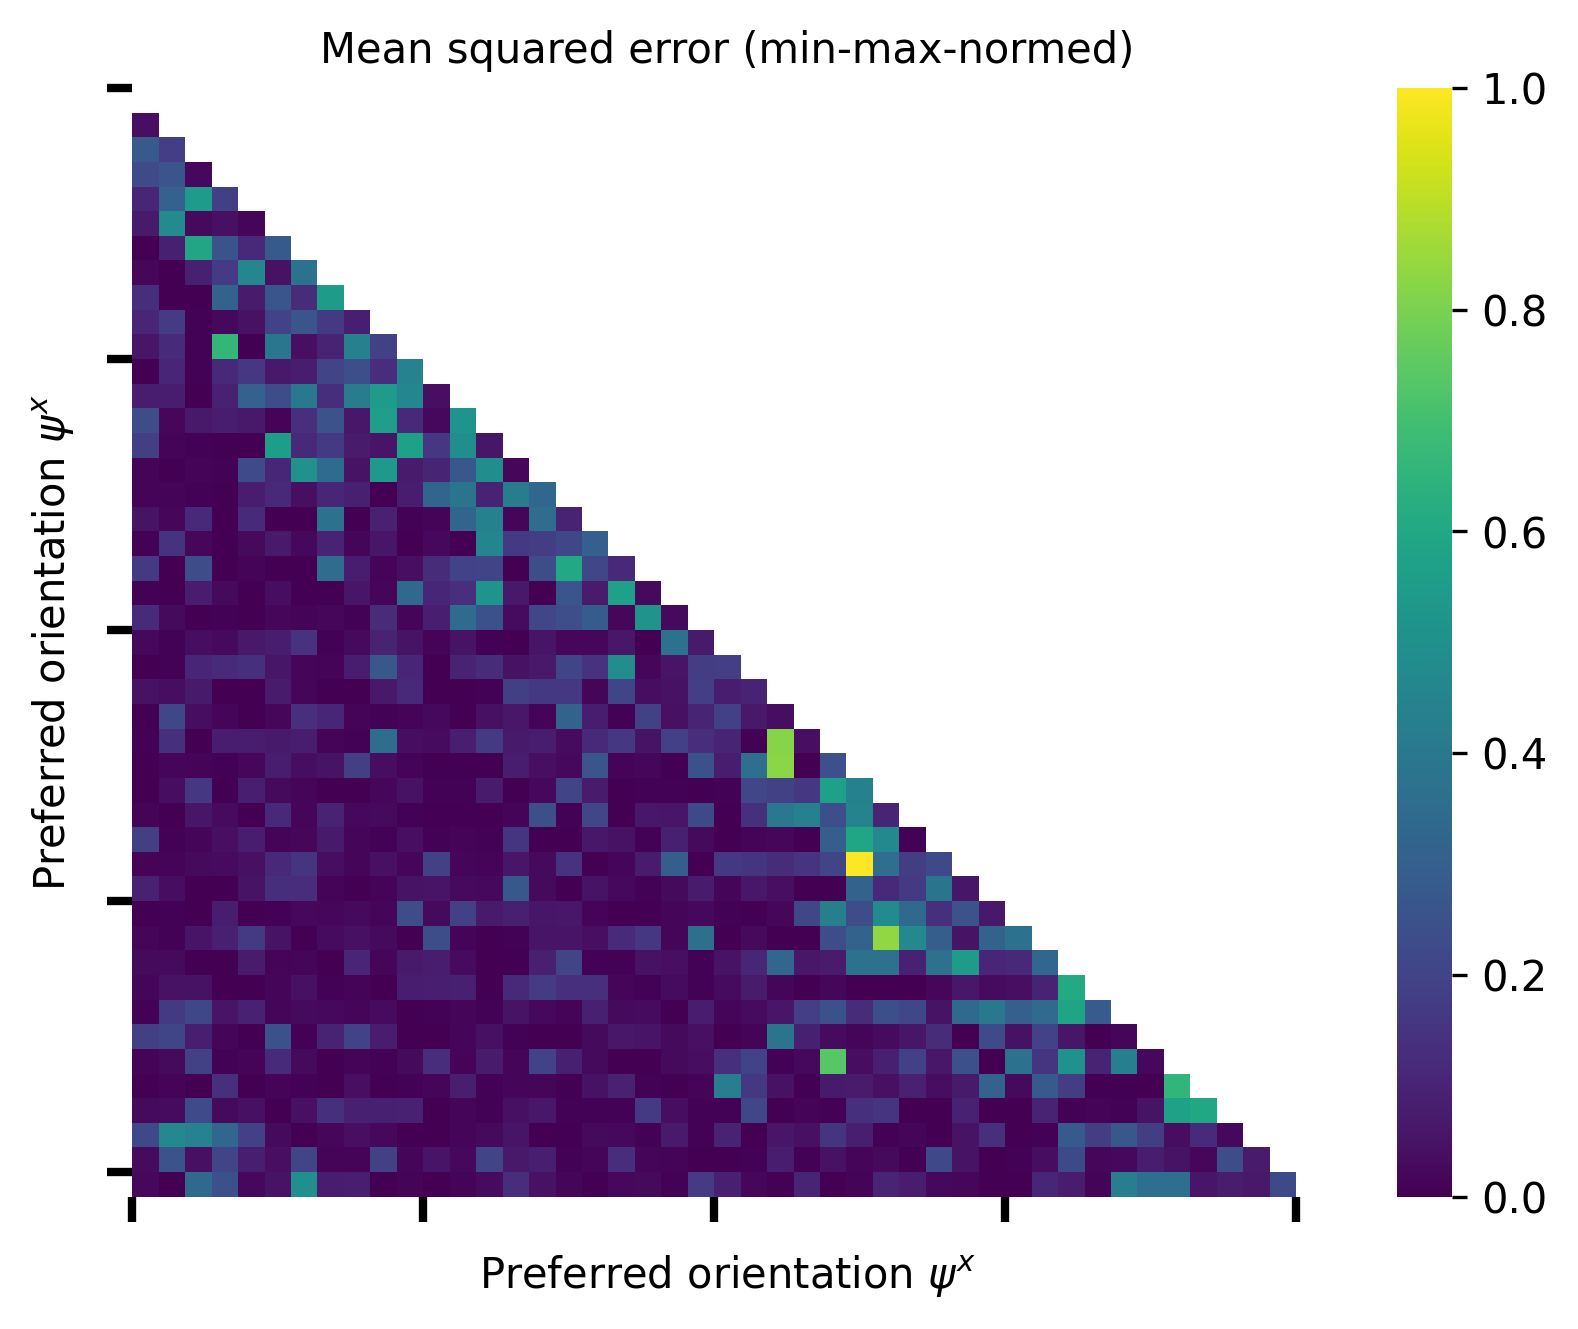

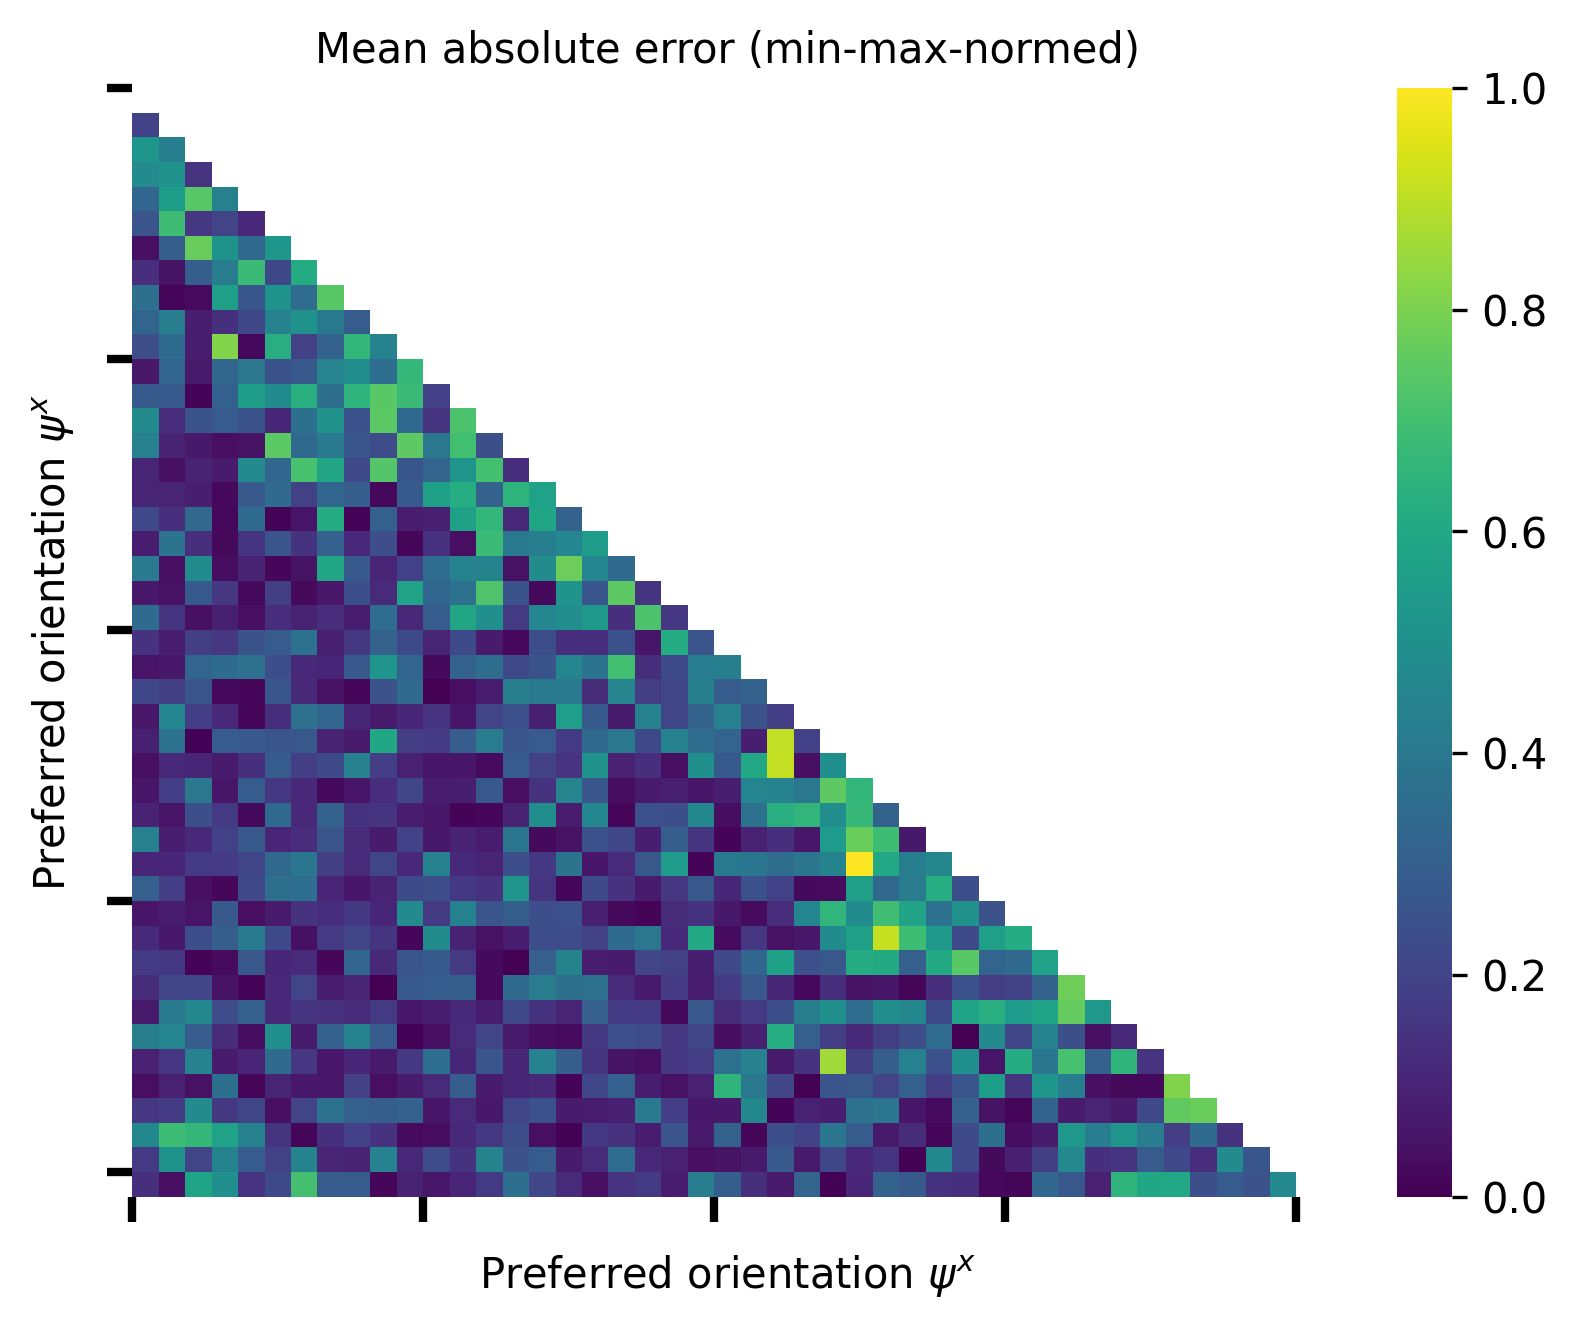

In [6]:
flow_path = best_val["model"]
flow_model = torch.load(flow_path)
flow_model.eval()
data_path = best_val["data_fname"]
train_prop = best_val["train_prop"]
val_prop = best_val["val_prop"]
batch_size = int(best_val["batch_size"])
train_loader, val_loader, test_loader = build_dataloaders(
    data_path, train_prop, val_prop, batch_size
)
output = evaluate_flow_prior(flow_model, val_loader)

In [3]:
best_val_results = result_table.fetch(download_path="/tmp", order_by="val_ll_mean DESC", limit=3)

In [4]:
best_val_results

array([('89c1053a65023b042dc63f7f852bb5b0', 'f89651063b51487dcdf4041336ef89db', '260a5ea8175f75eaef132f42873ad14a', -51.37348557, 1.19026911, -51.2784996 , 2.23057818, -51.2784996 , 2.23057818, '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_tracker_output.pkl', '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_eval_output.pkl', '/tmp/89c1053a65023b042dc63f7f852bb5b0_f89651063b51487dcdf4041336ef89db_260a5ea8175f75eaef132f42873ad14a_model.pt',  42, 2, 'inv_softplus', 'none', 'tanh', 'multivariate_normal', 'factorized', '/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl', 0.7, 0.2, 0.001, 0.001, 250, 128, 10, 10),
       ('d78dc2d7d2fd04d25b7a03ec065acca2', 'c40a50ce9c77369770dddd5129836477', '260a5ea8175f75eaef132f42873ad14a', -51.3728447 , 1.19626045, -51.27913666, 2.24291182, -51.27913666, 2.24291182, '/tmp/d78dc2d7d2fd04d25b7a03ec065acca2_c40

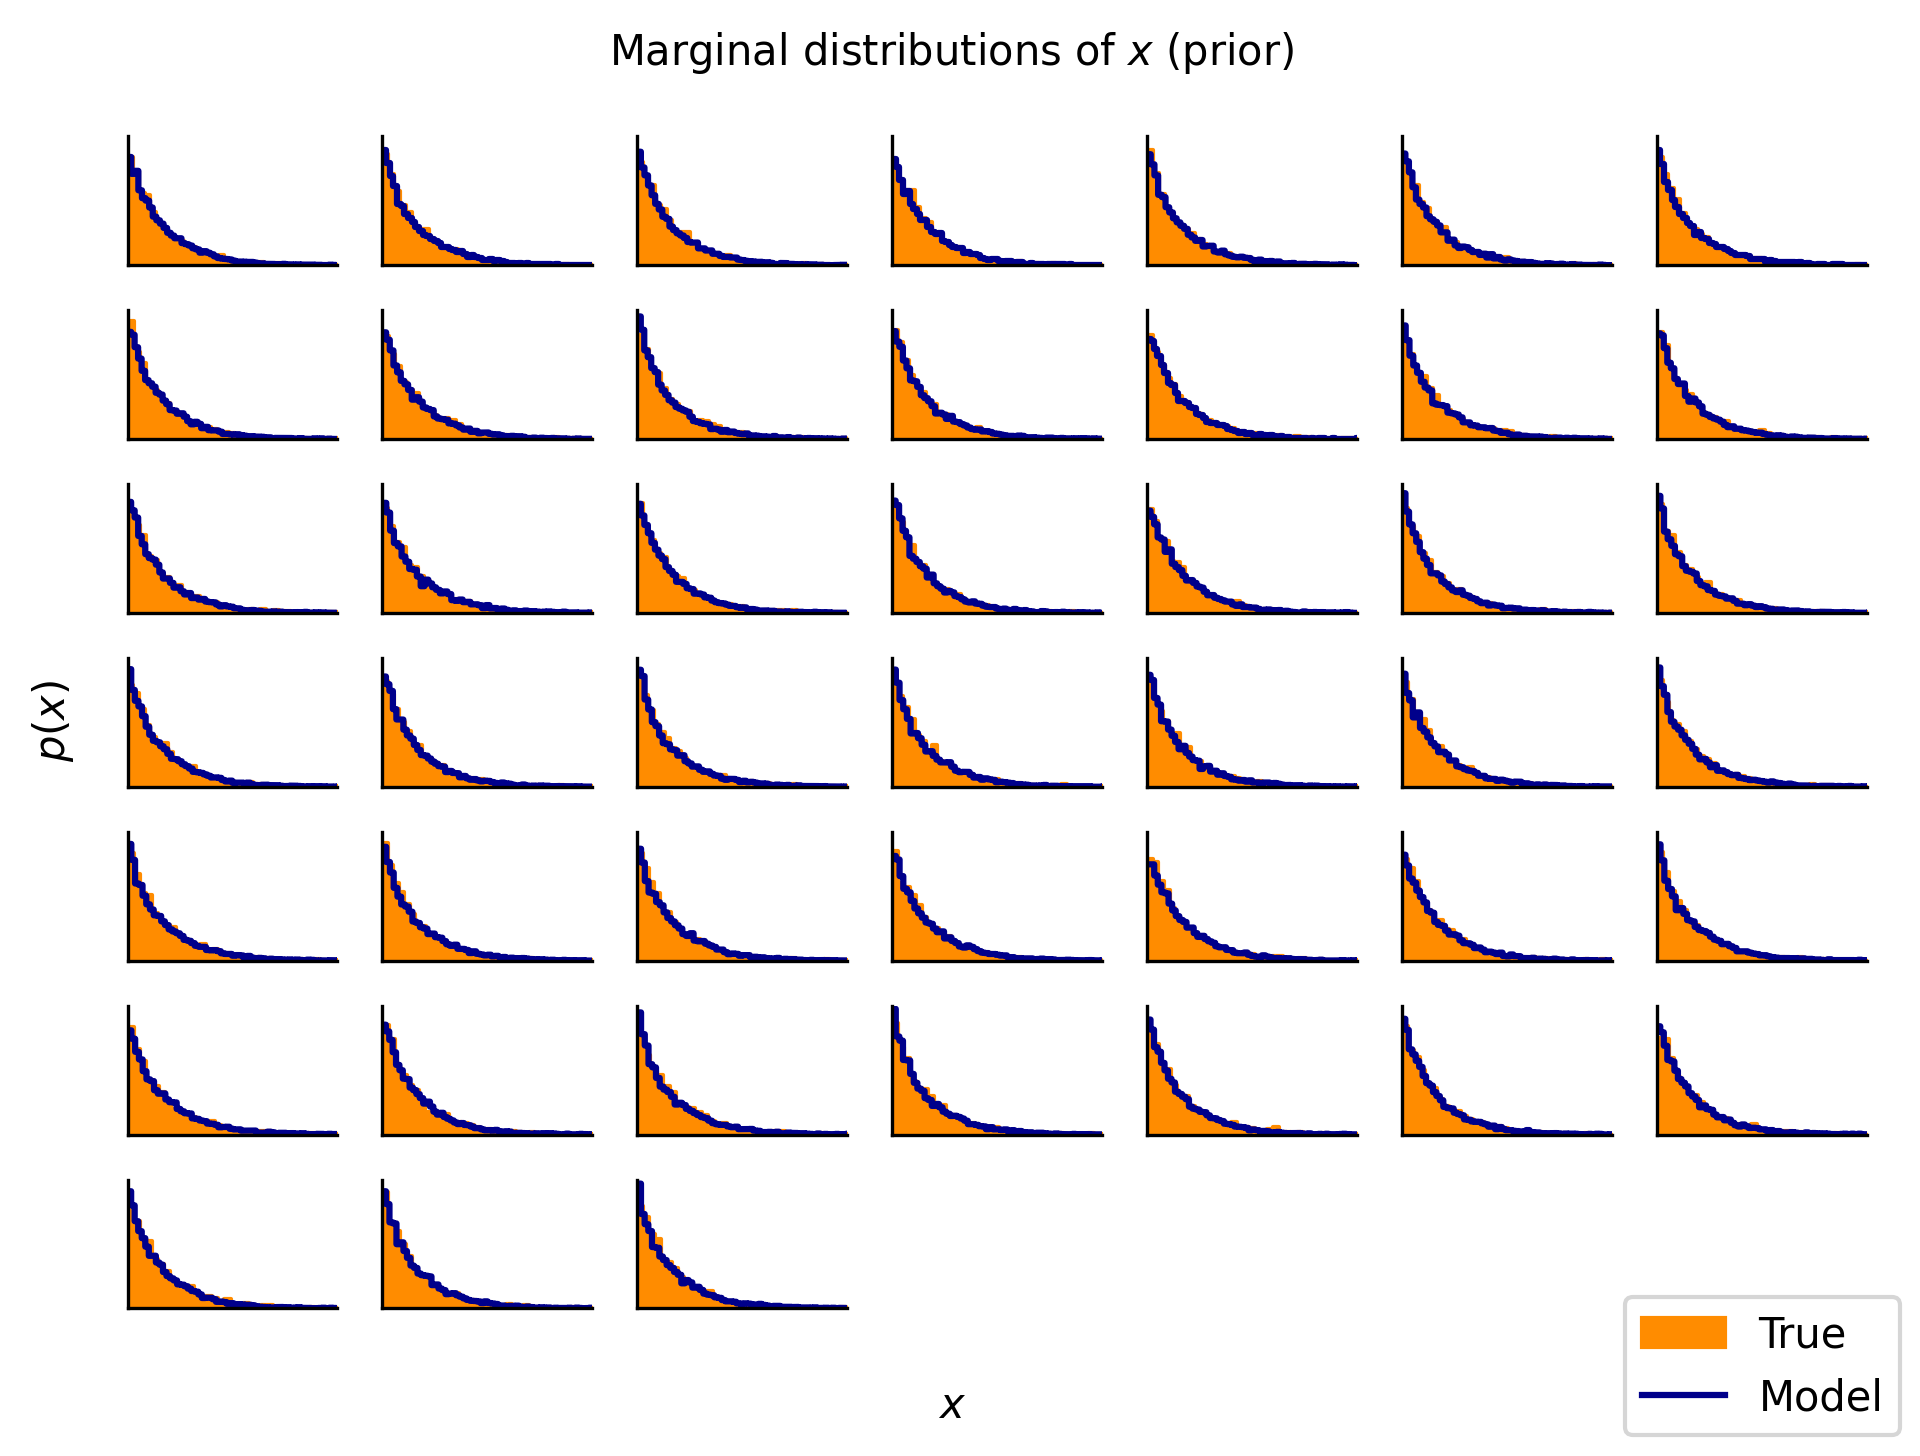

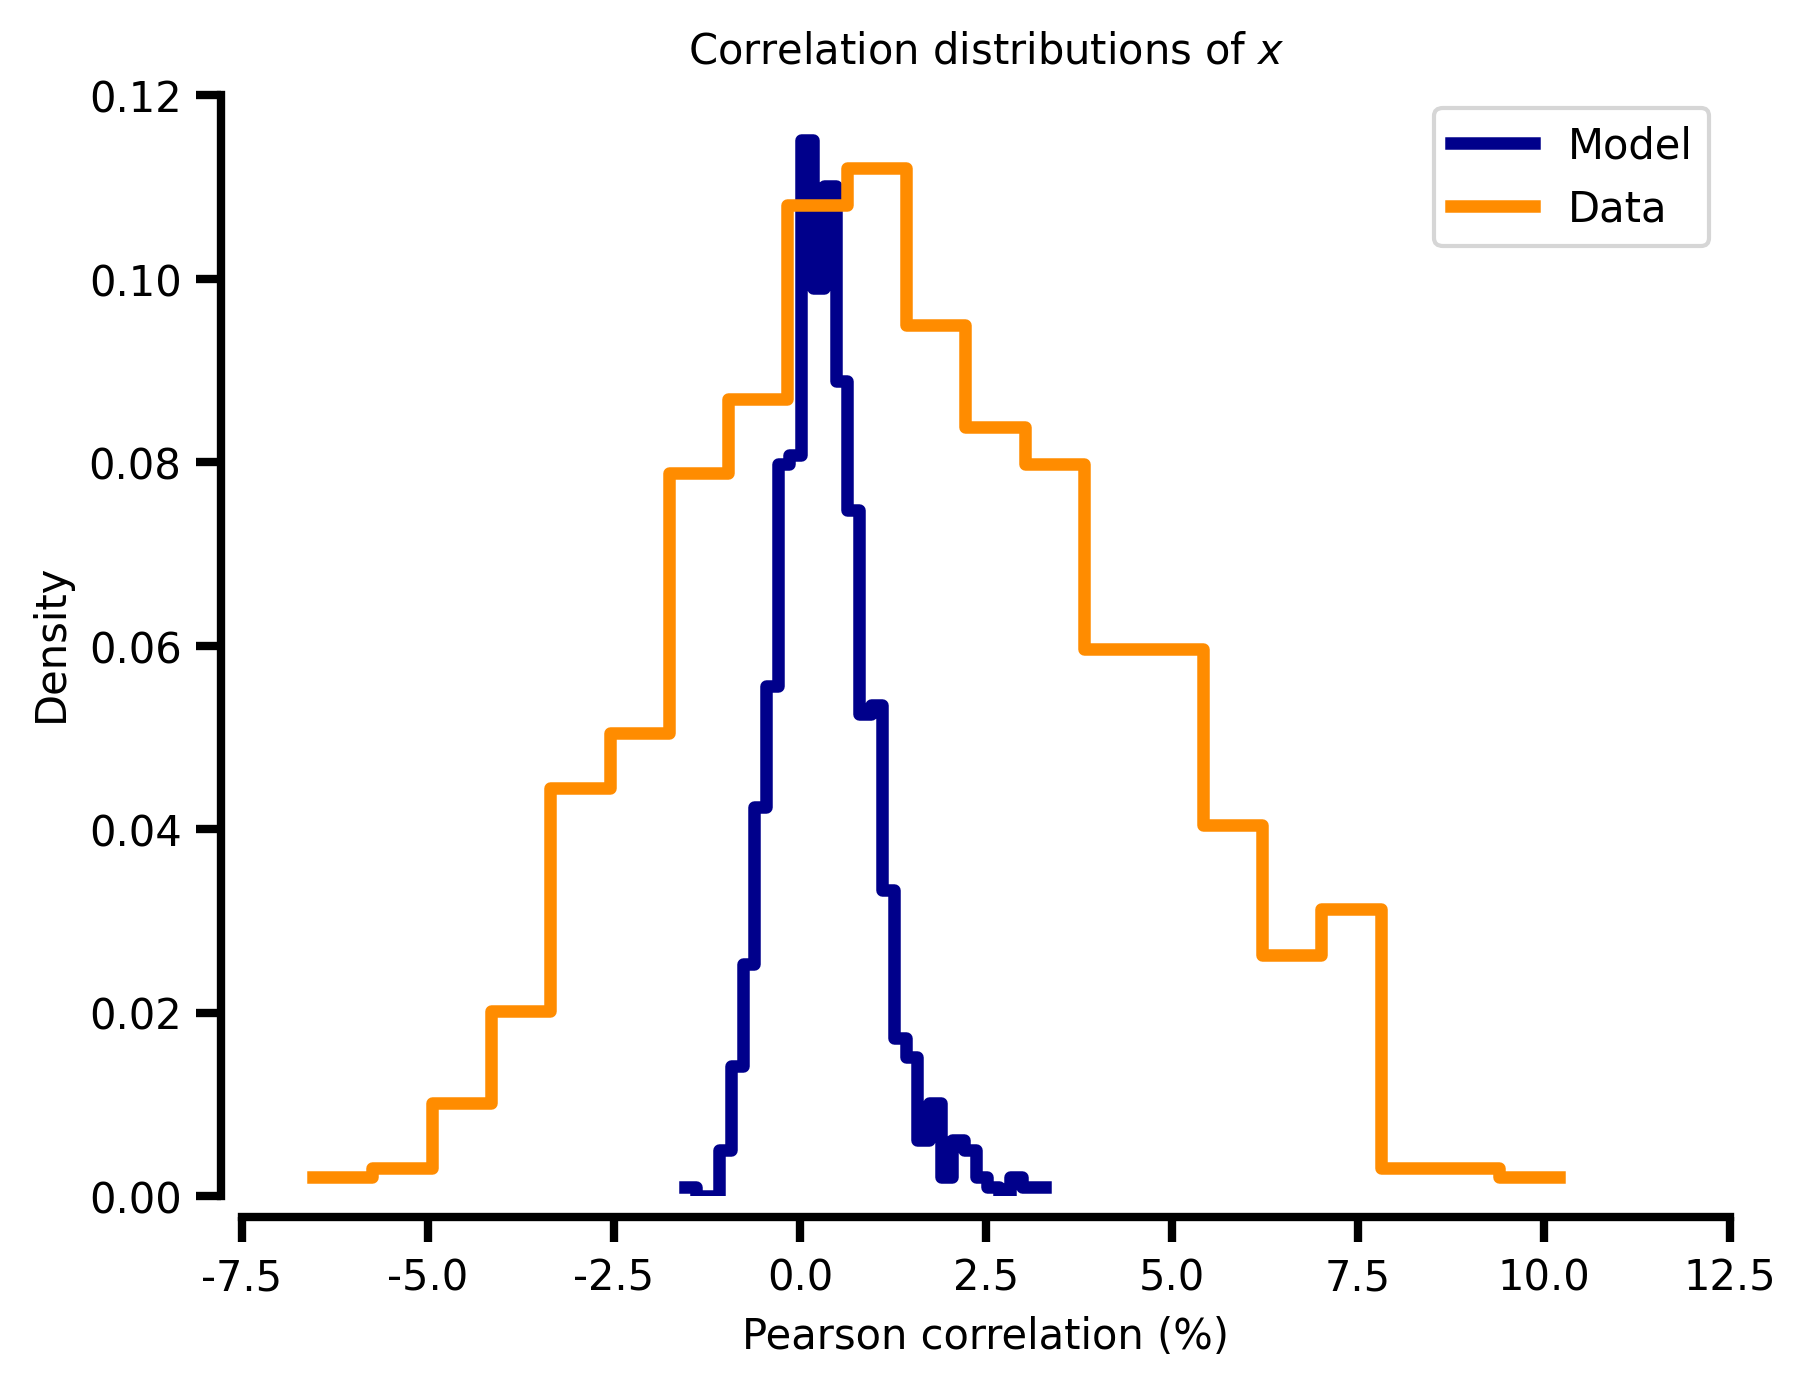

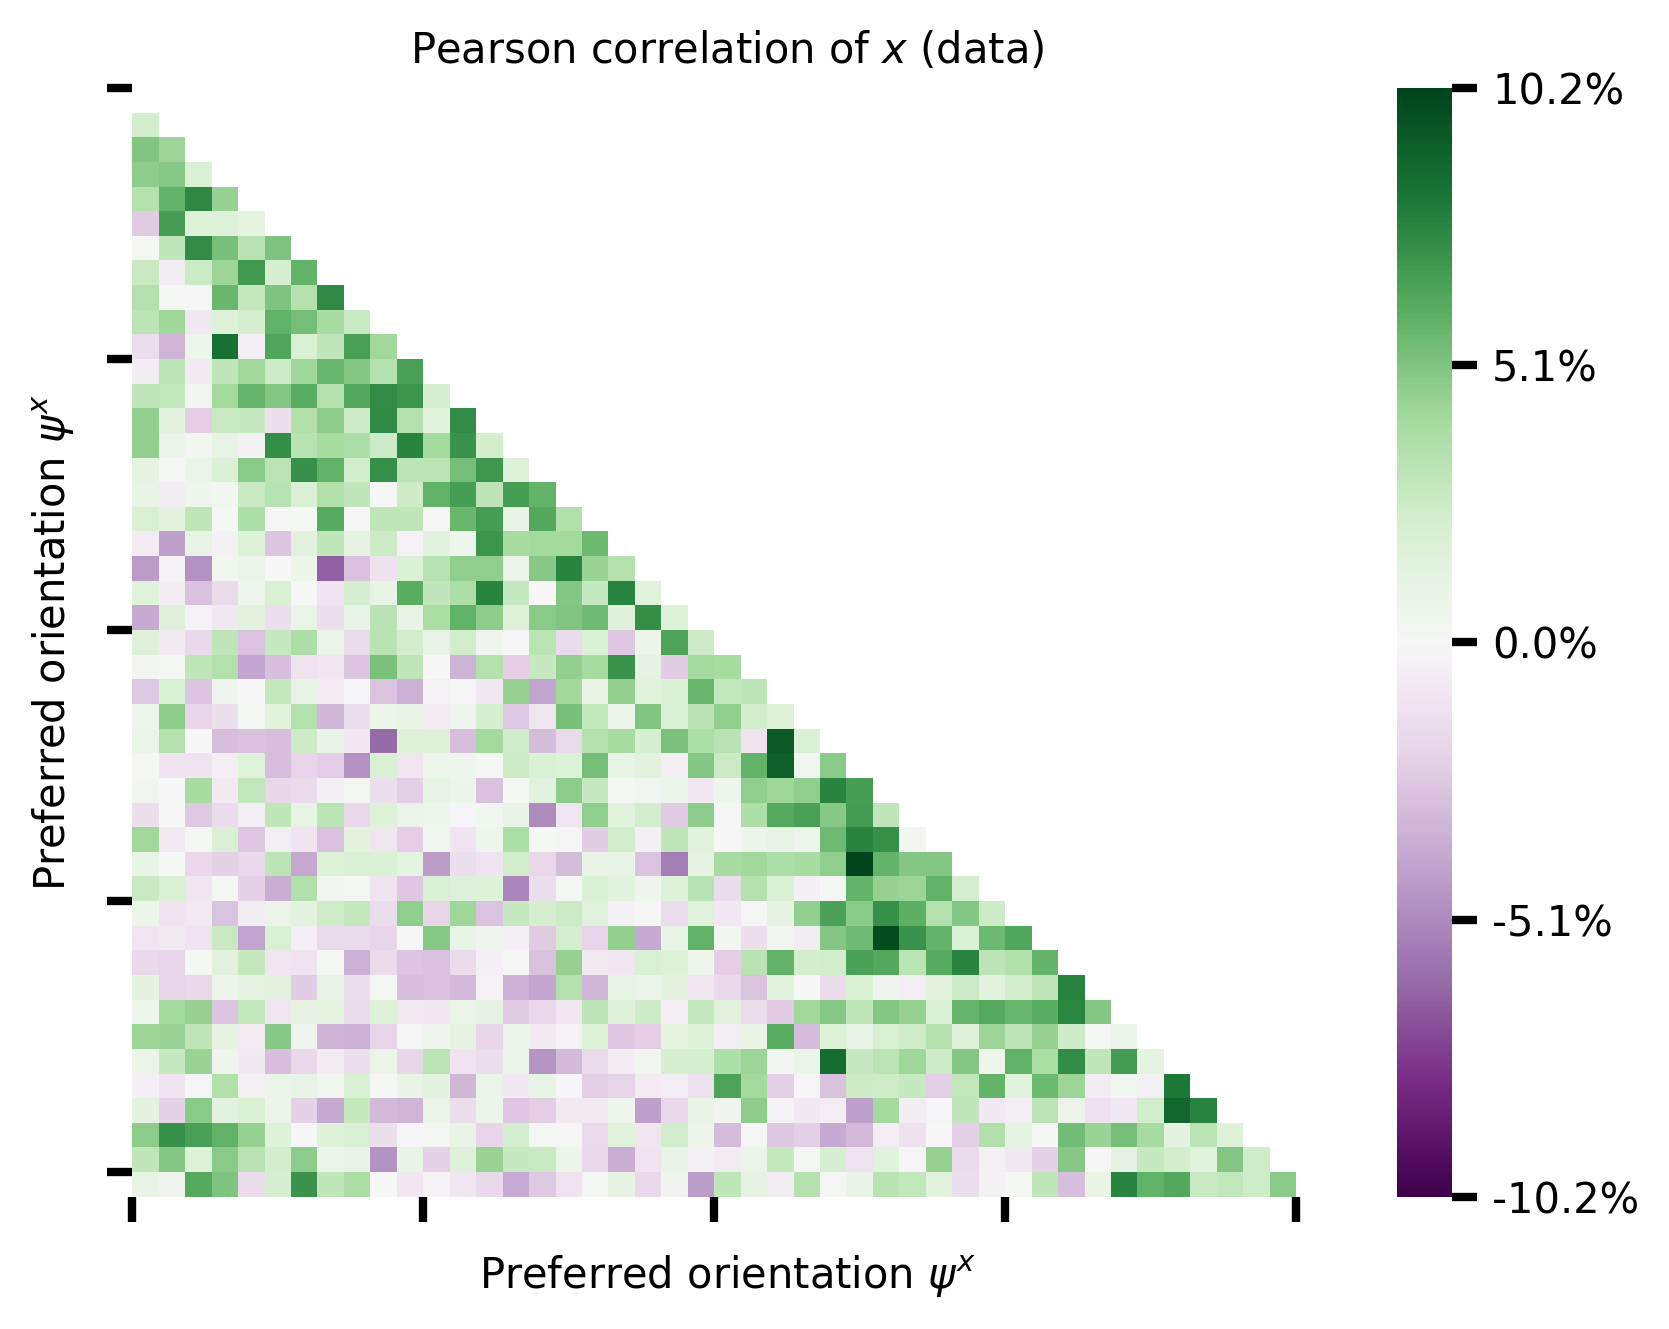

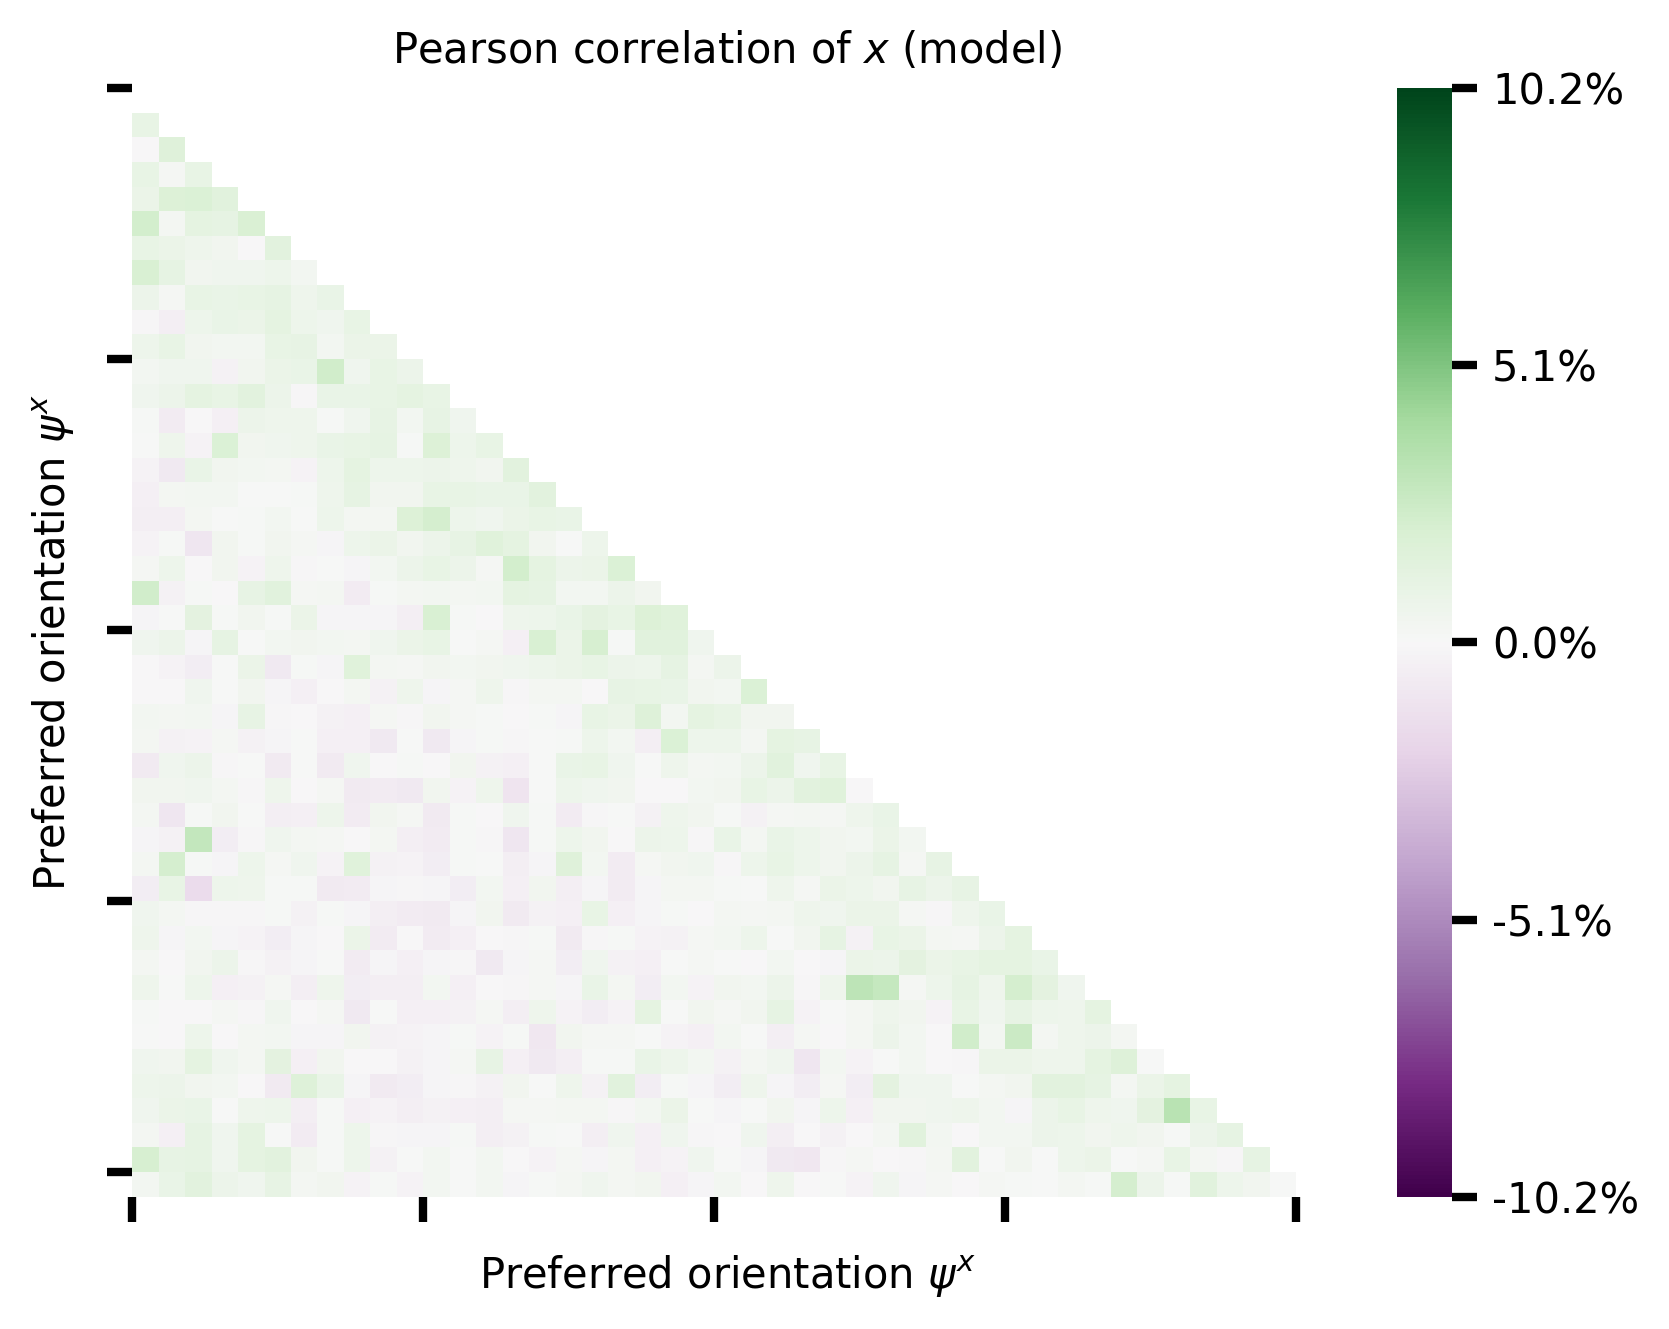

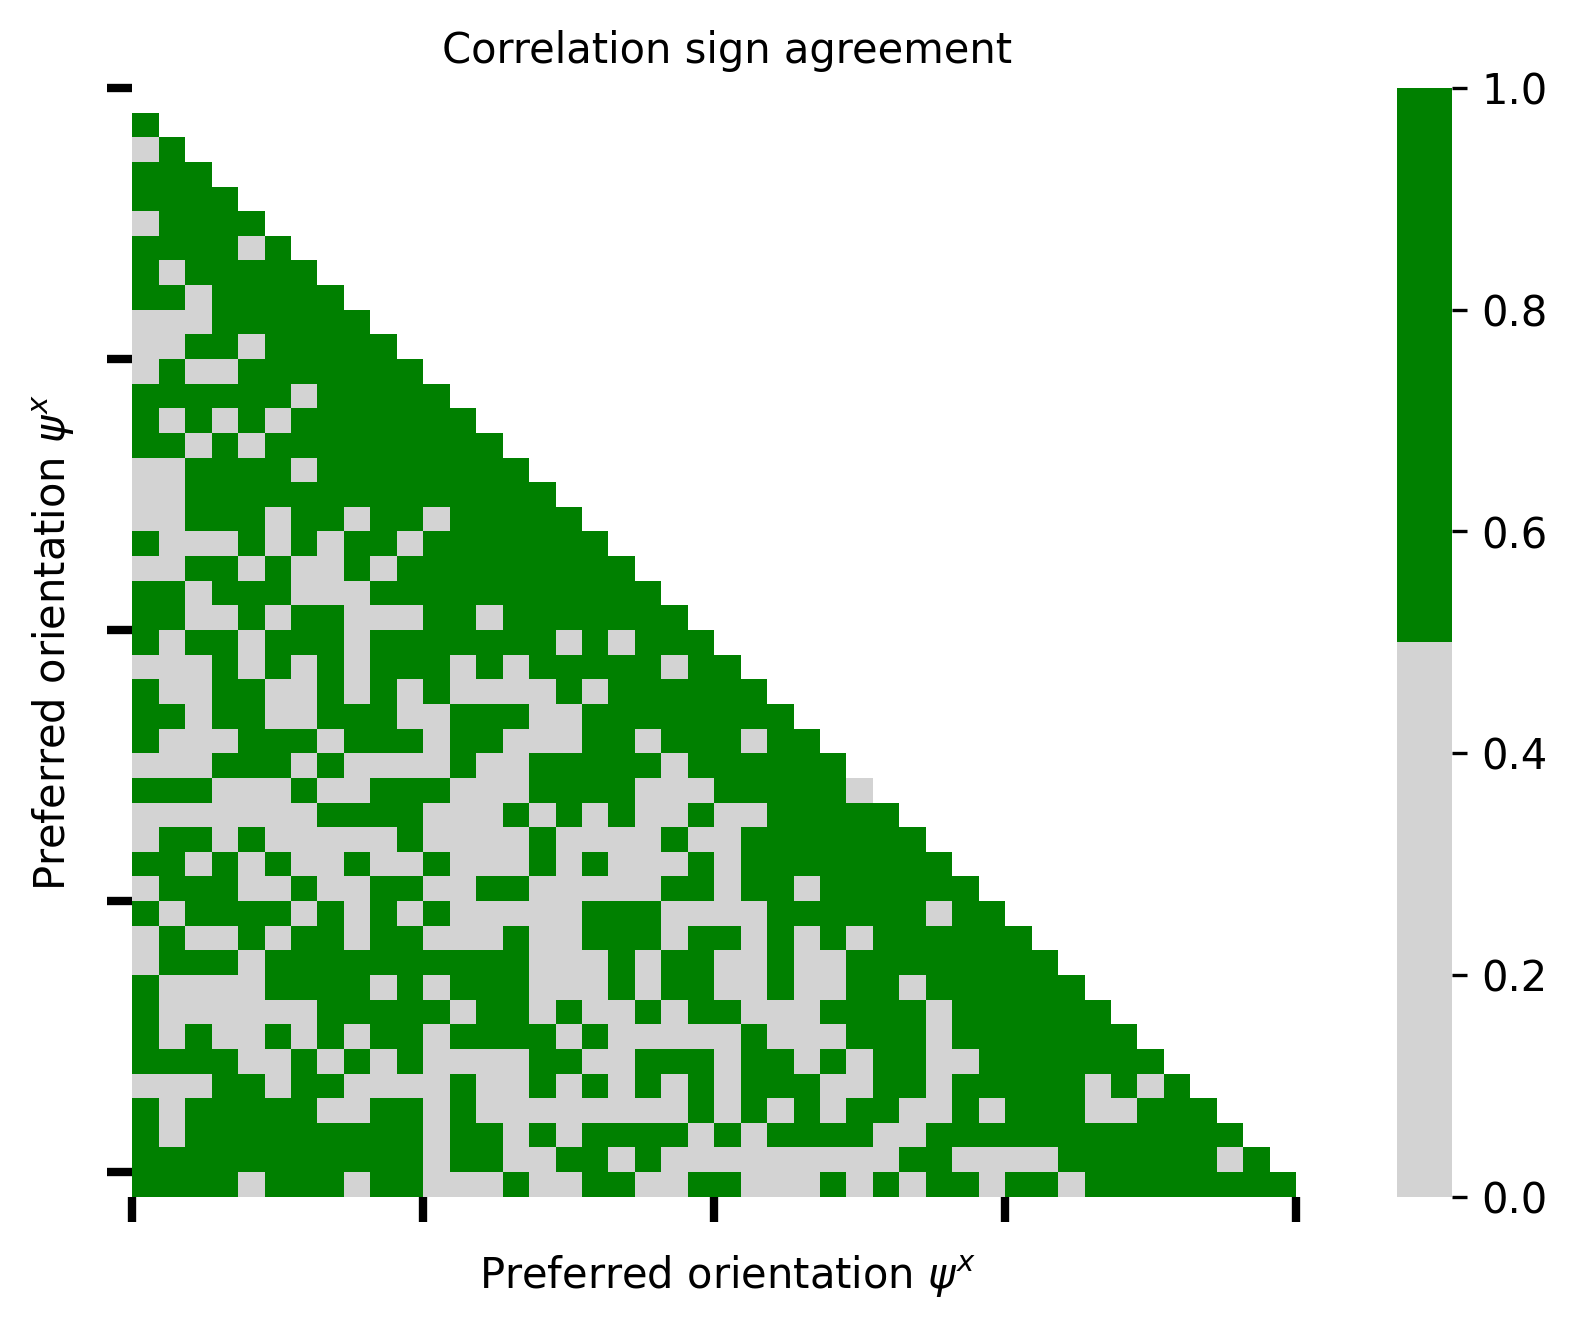

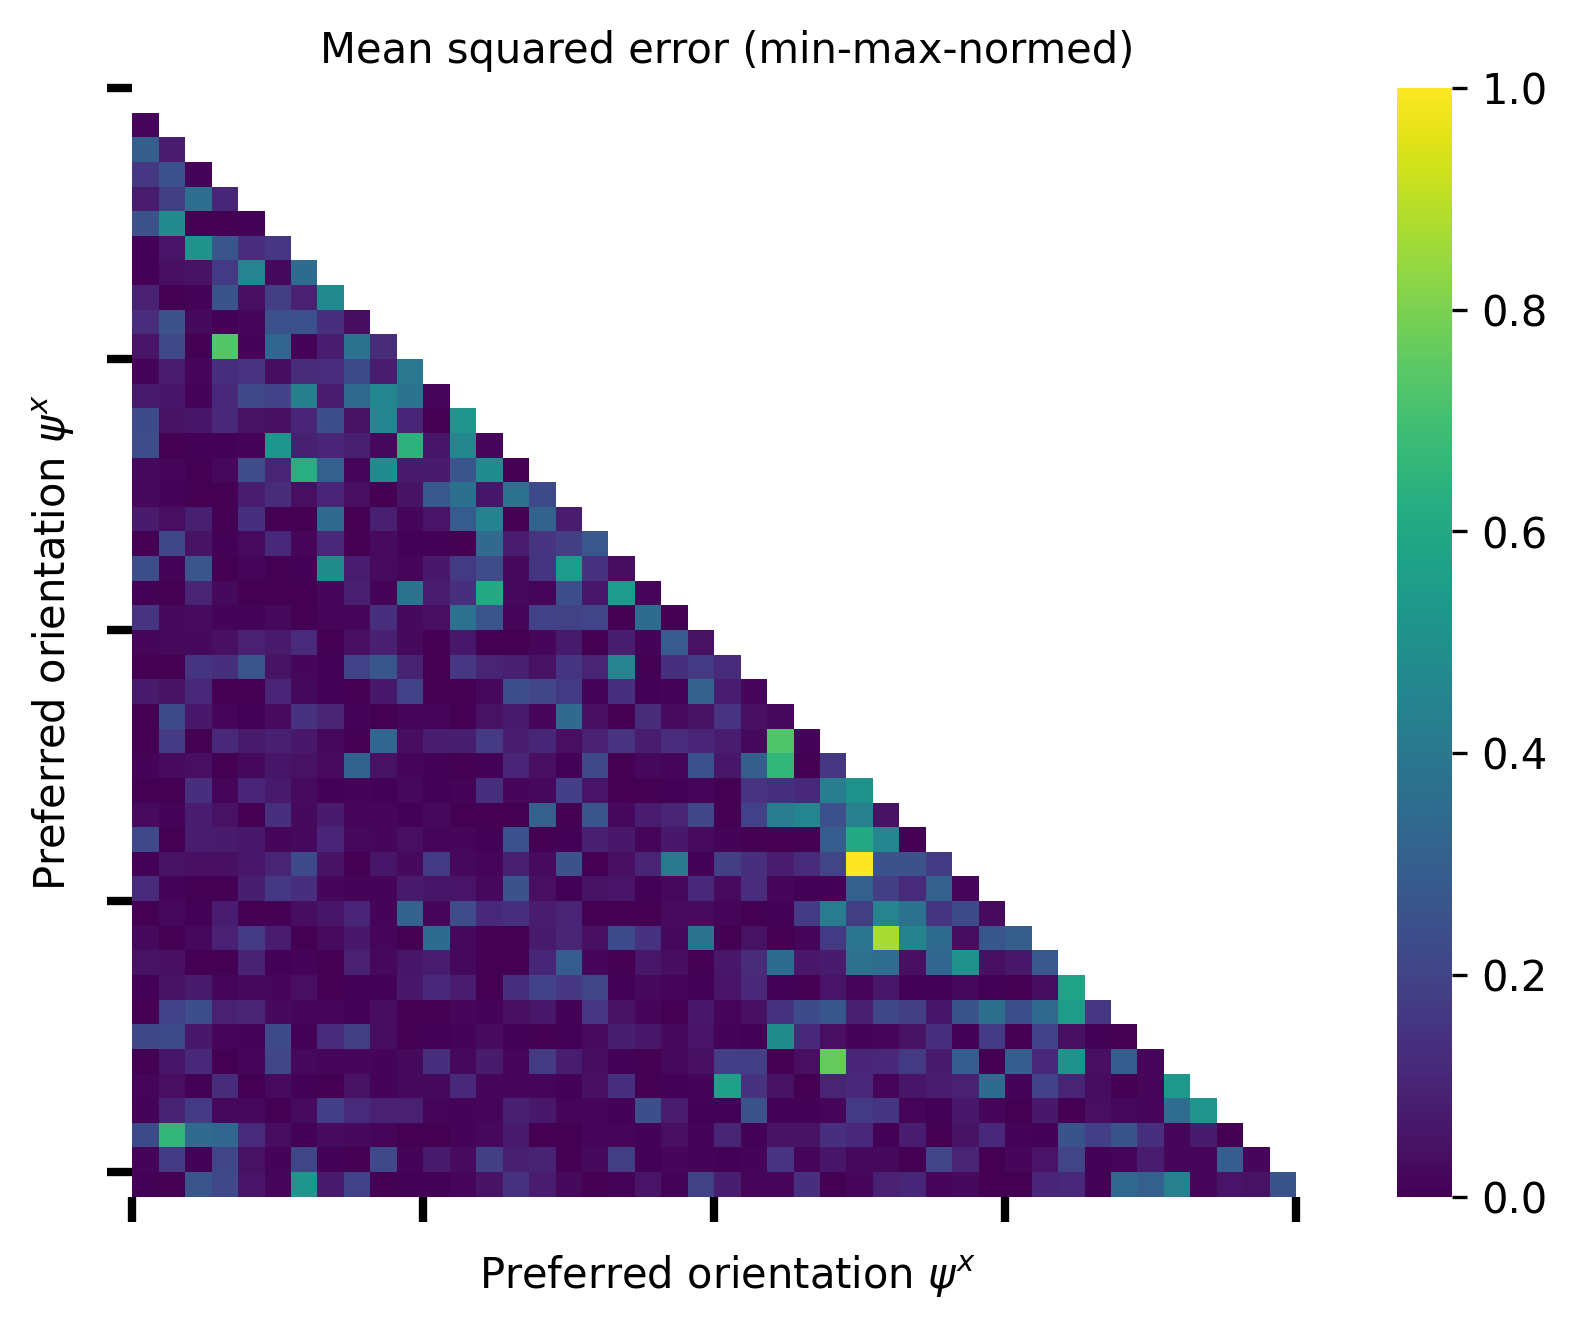

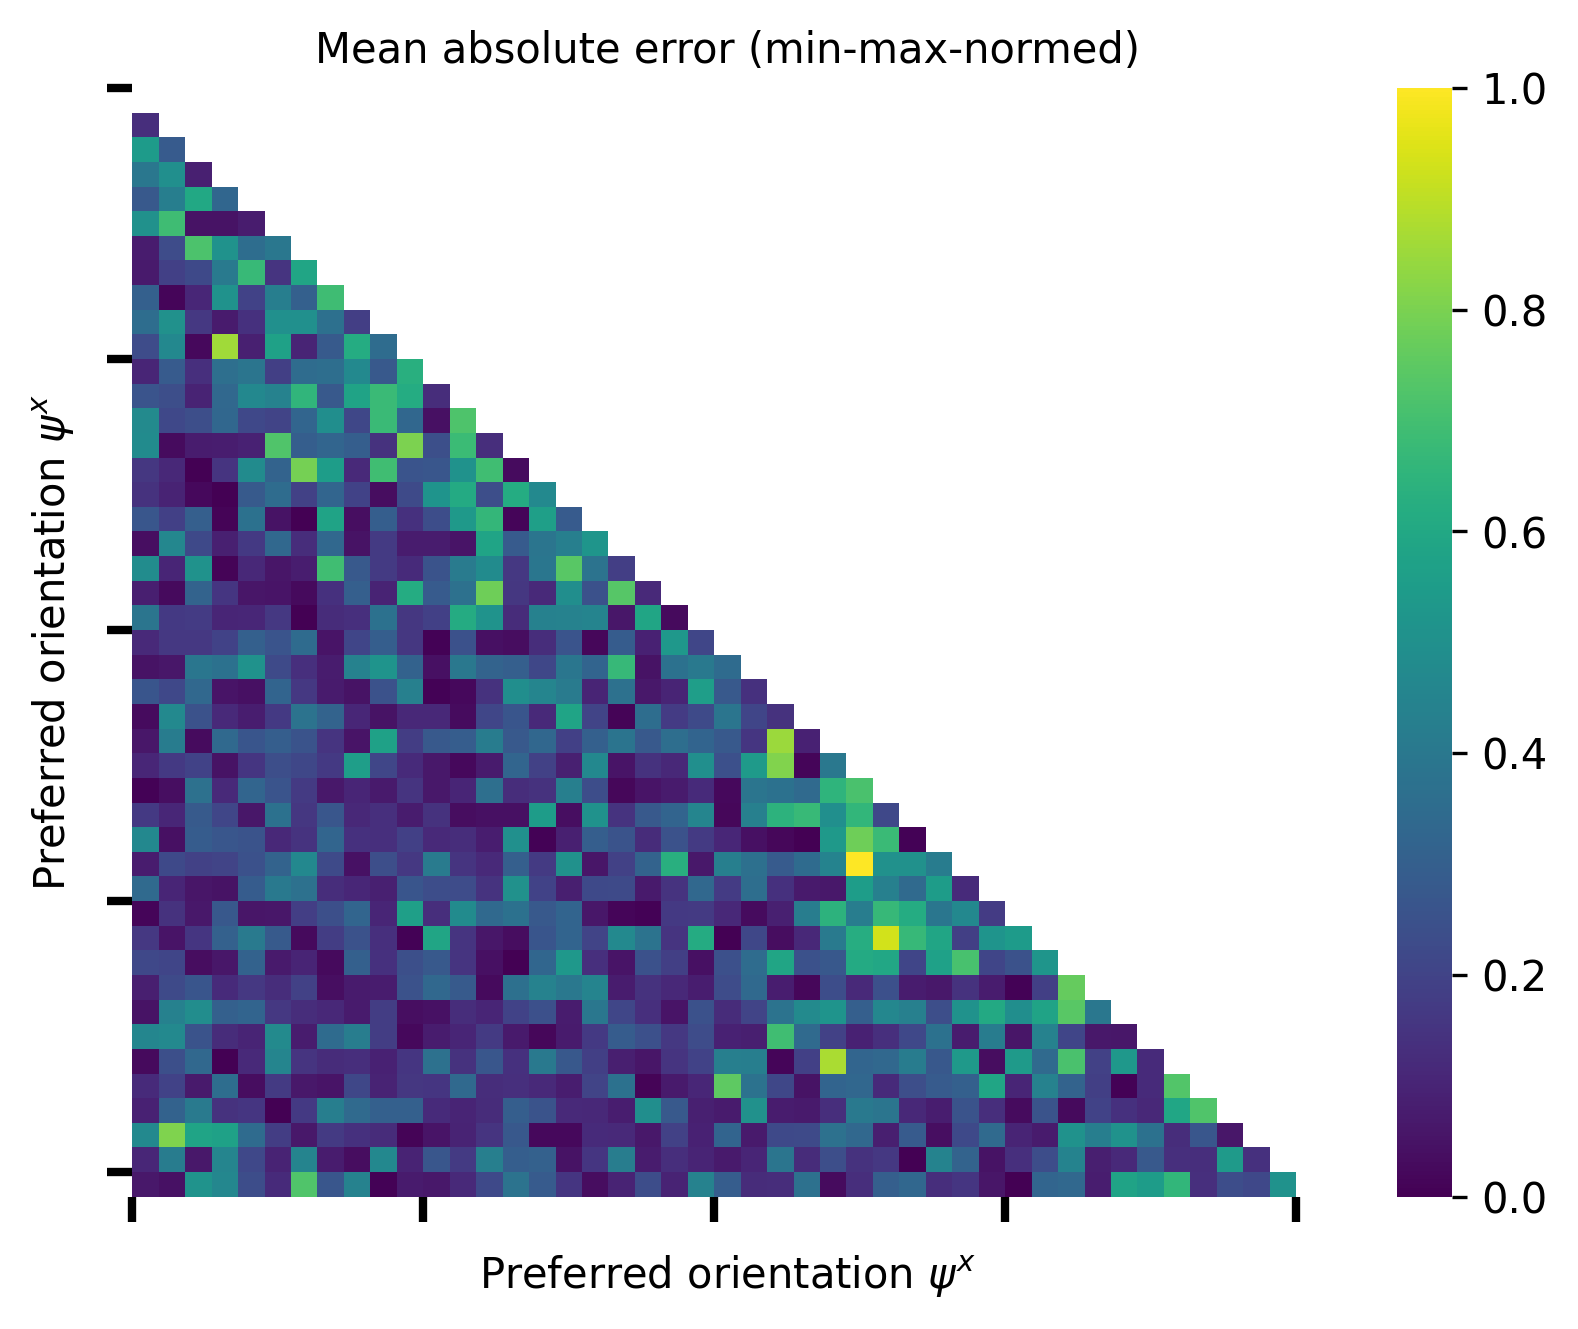

Press enter to continue to 1


In [9]:
for idx, best_val in enumerate(best_val_results):
    flow_path = best_val["model"]
    flow_model = torch.load(flow_path)
    flow_model.eval()
    data_path = best_val["data_fname"]
    train_prop = best_val["train_prop"]
    val_prop = best_val["val_prop"]
    batch_size = int(best_val["batch_size"])
    train_loader, val_loader, test_loader = build_dataloaders(
        data_path, train_prop, val_prop, batch_size
    )
    output = evaluate_flow_prior(flow_model, val_loader)
    print(f"Press enter to continue to {idx+1}")
    break

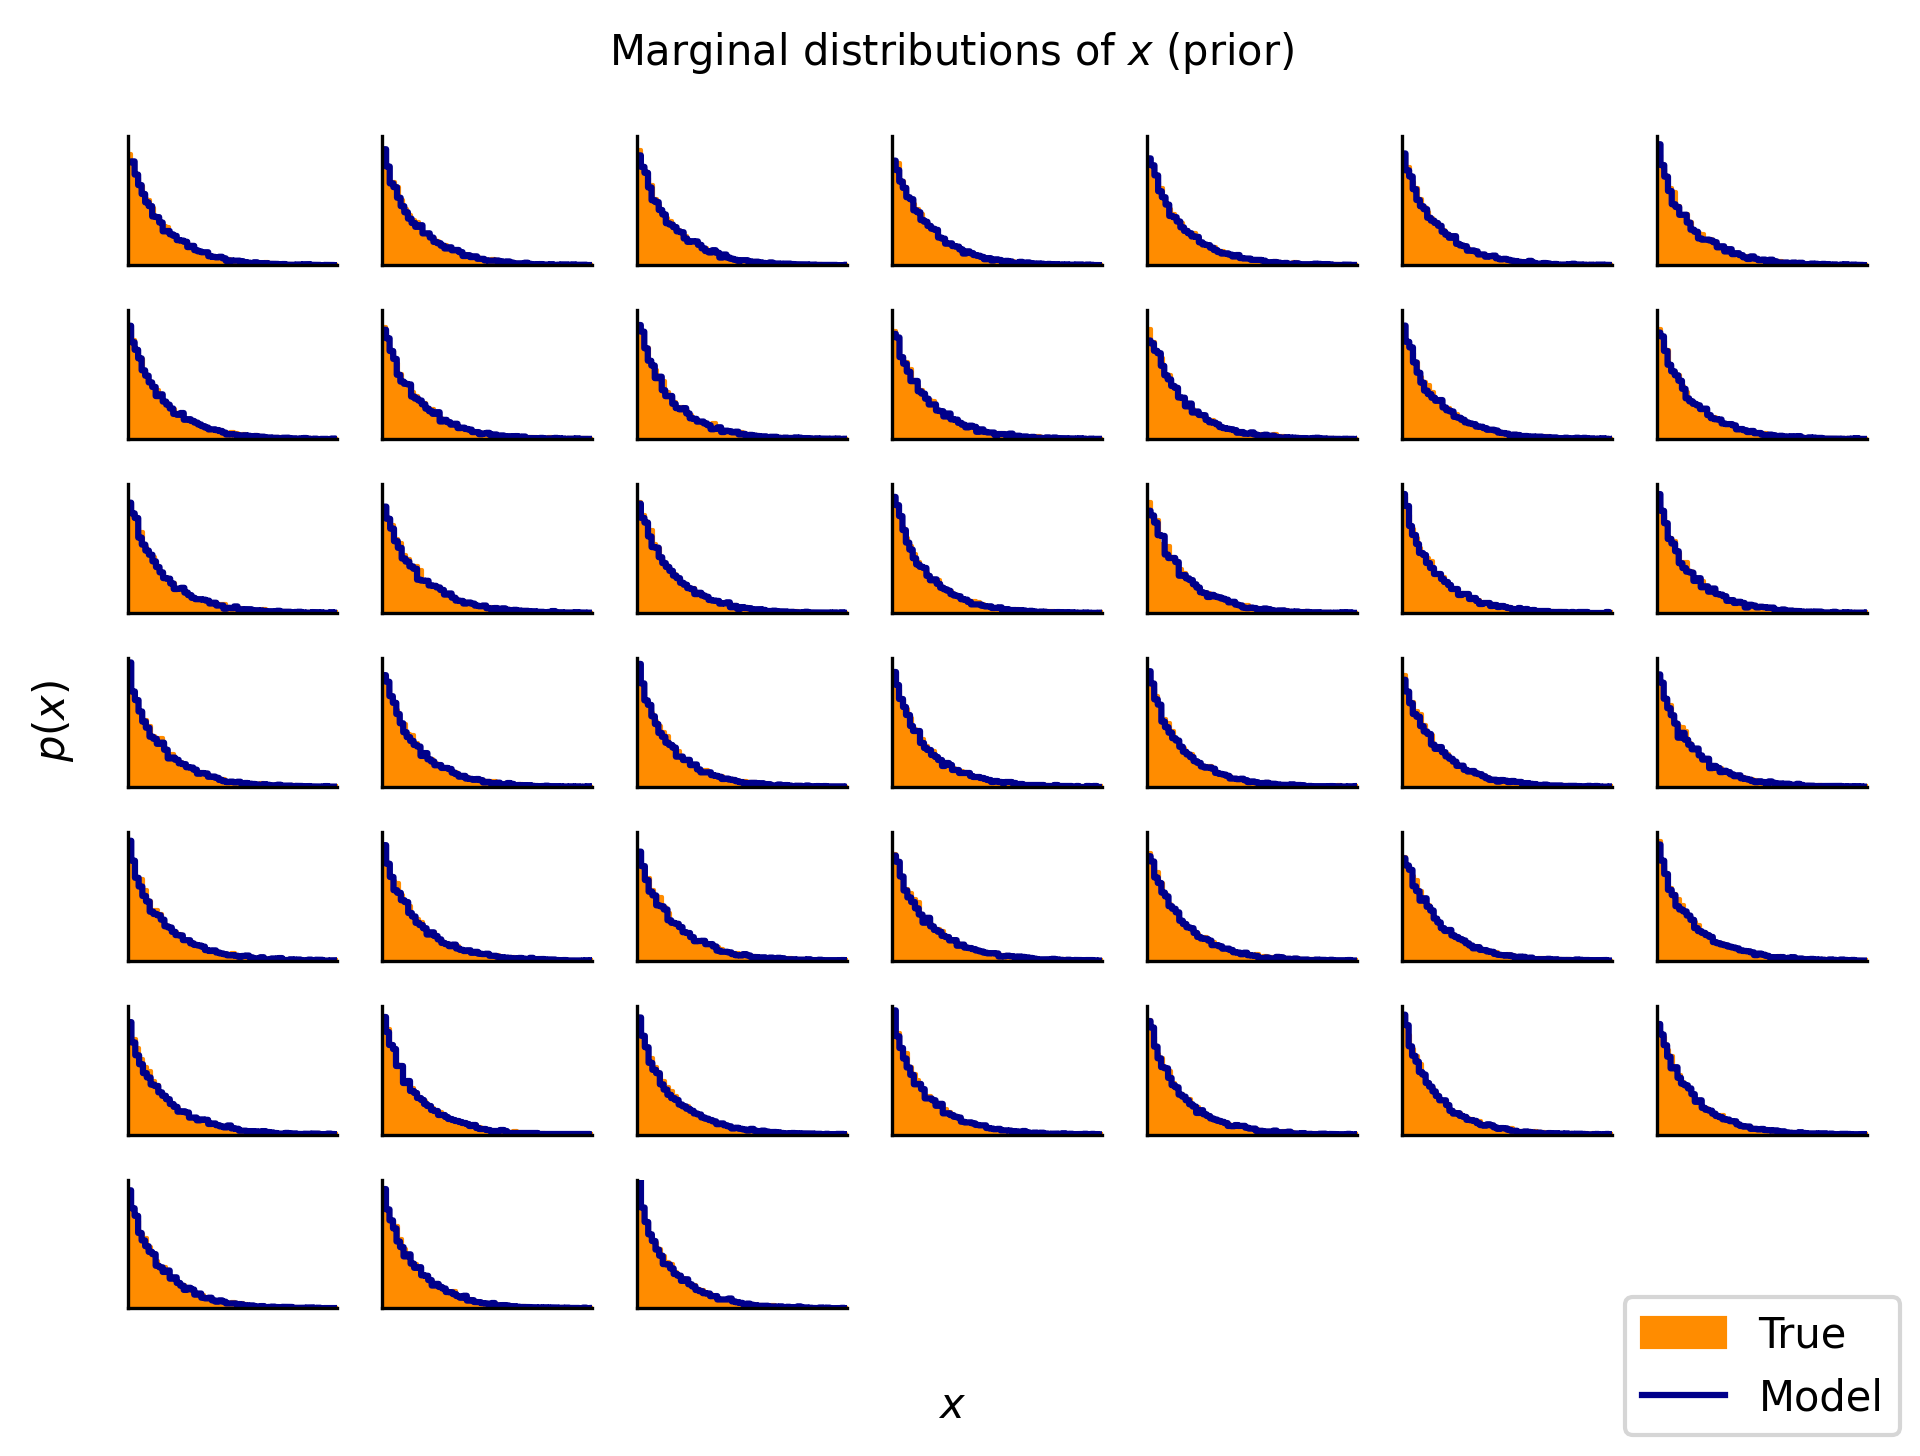

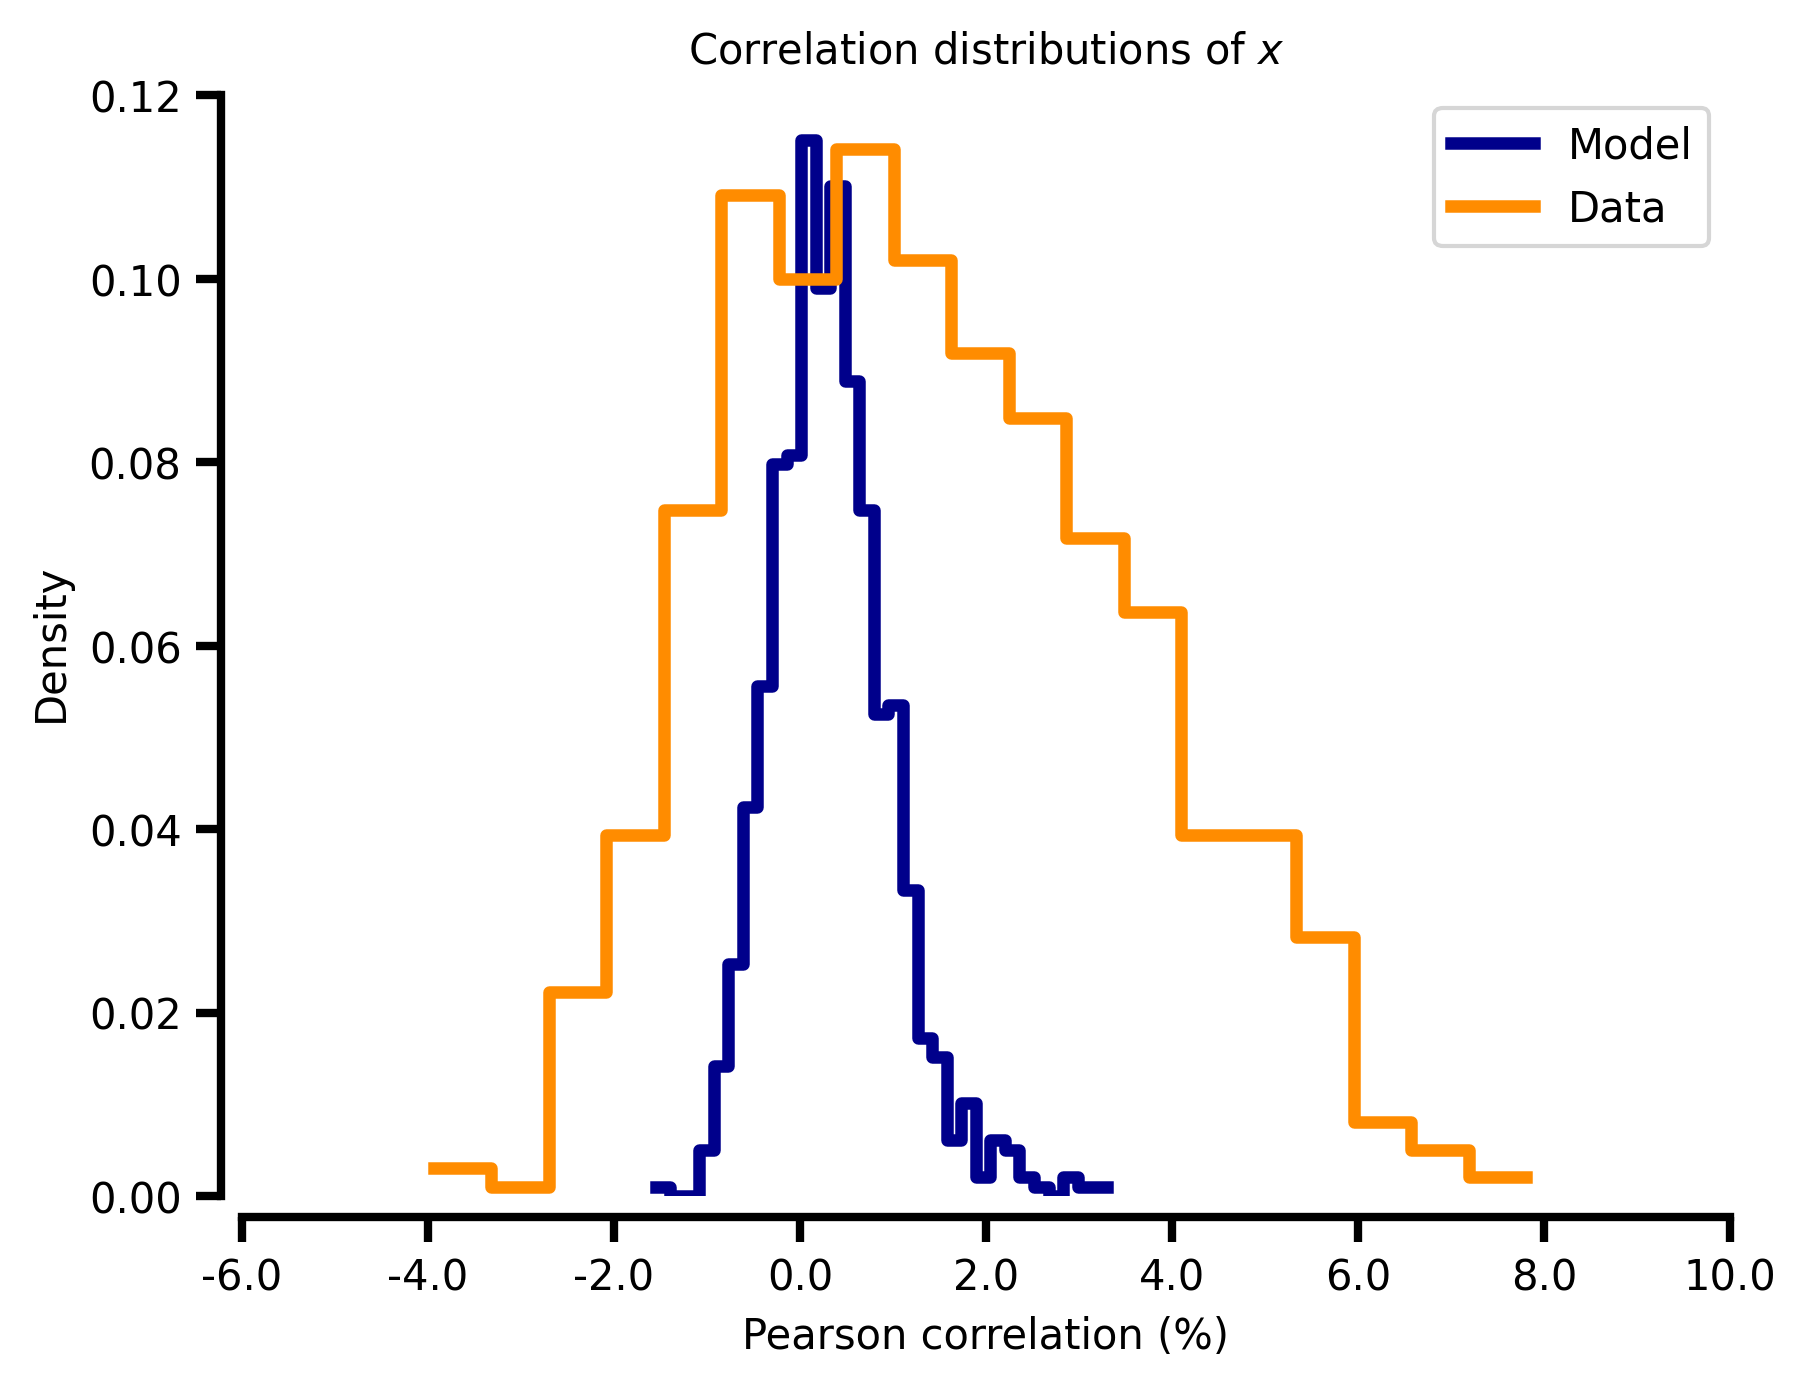

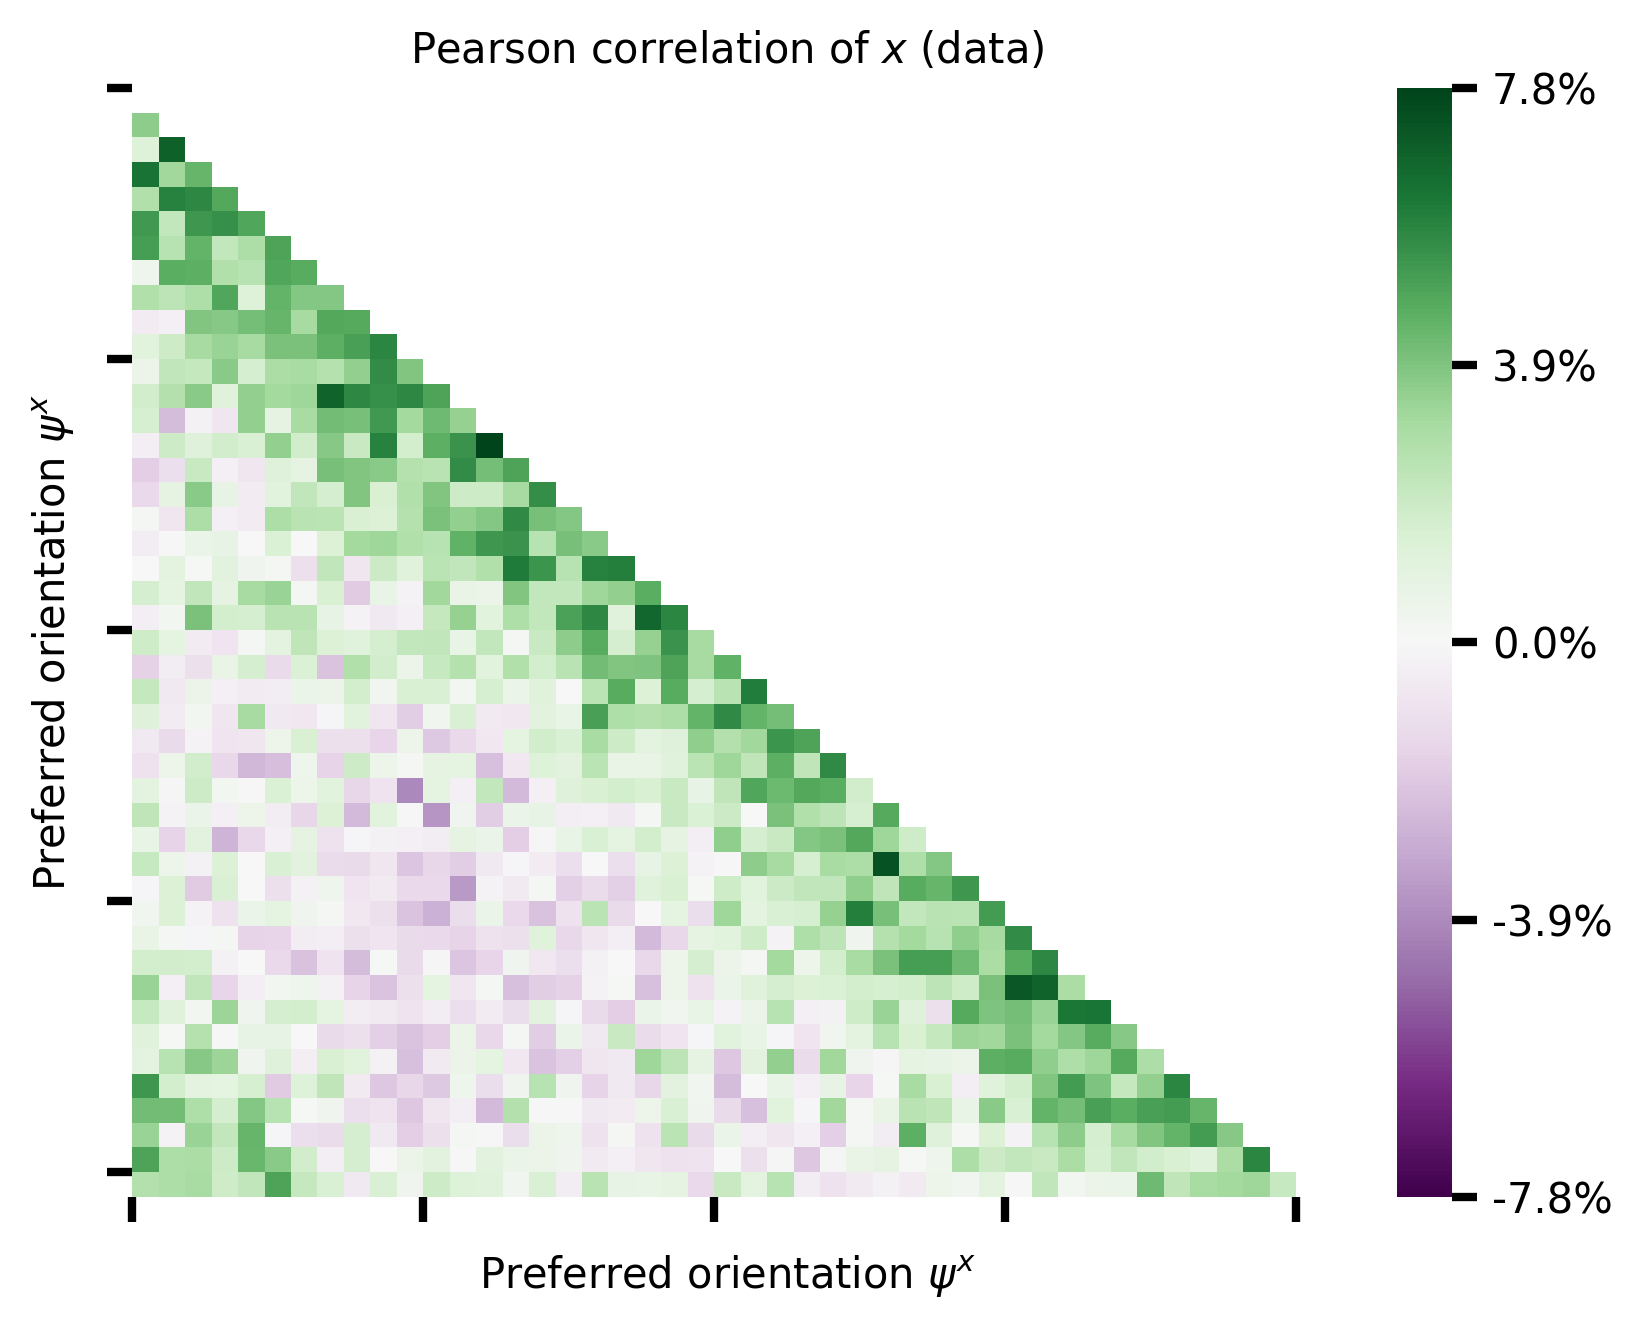

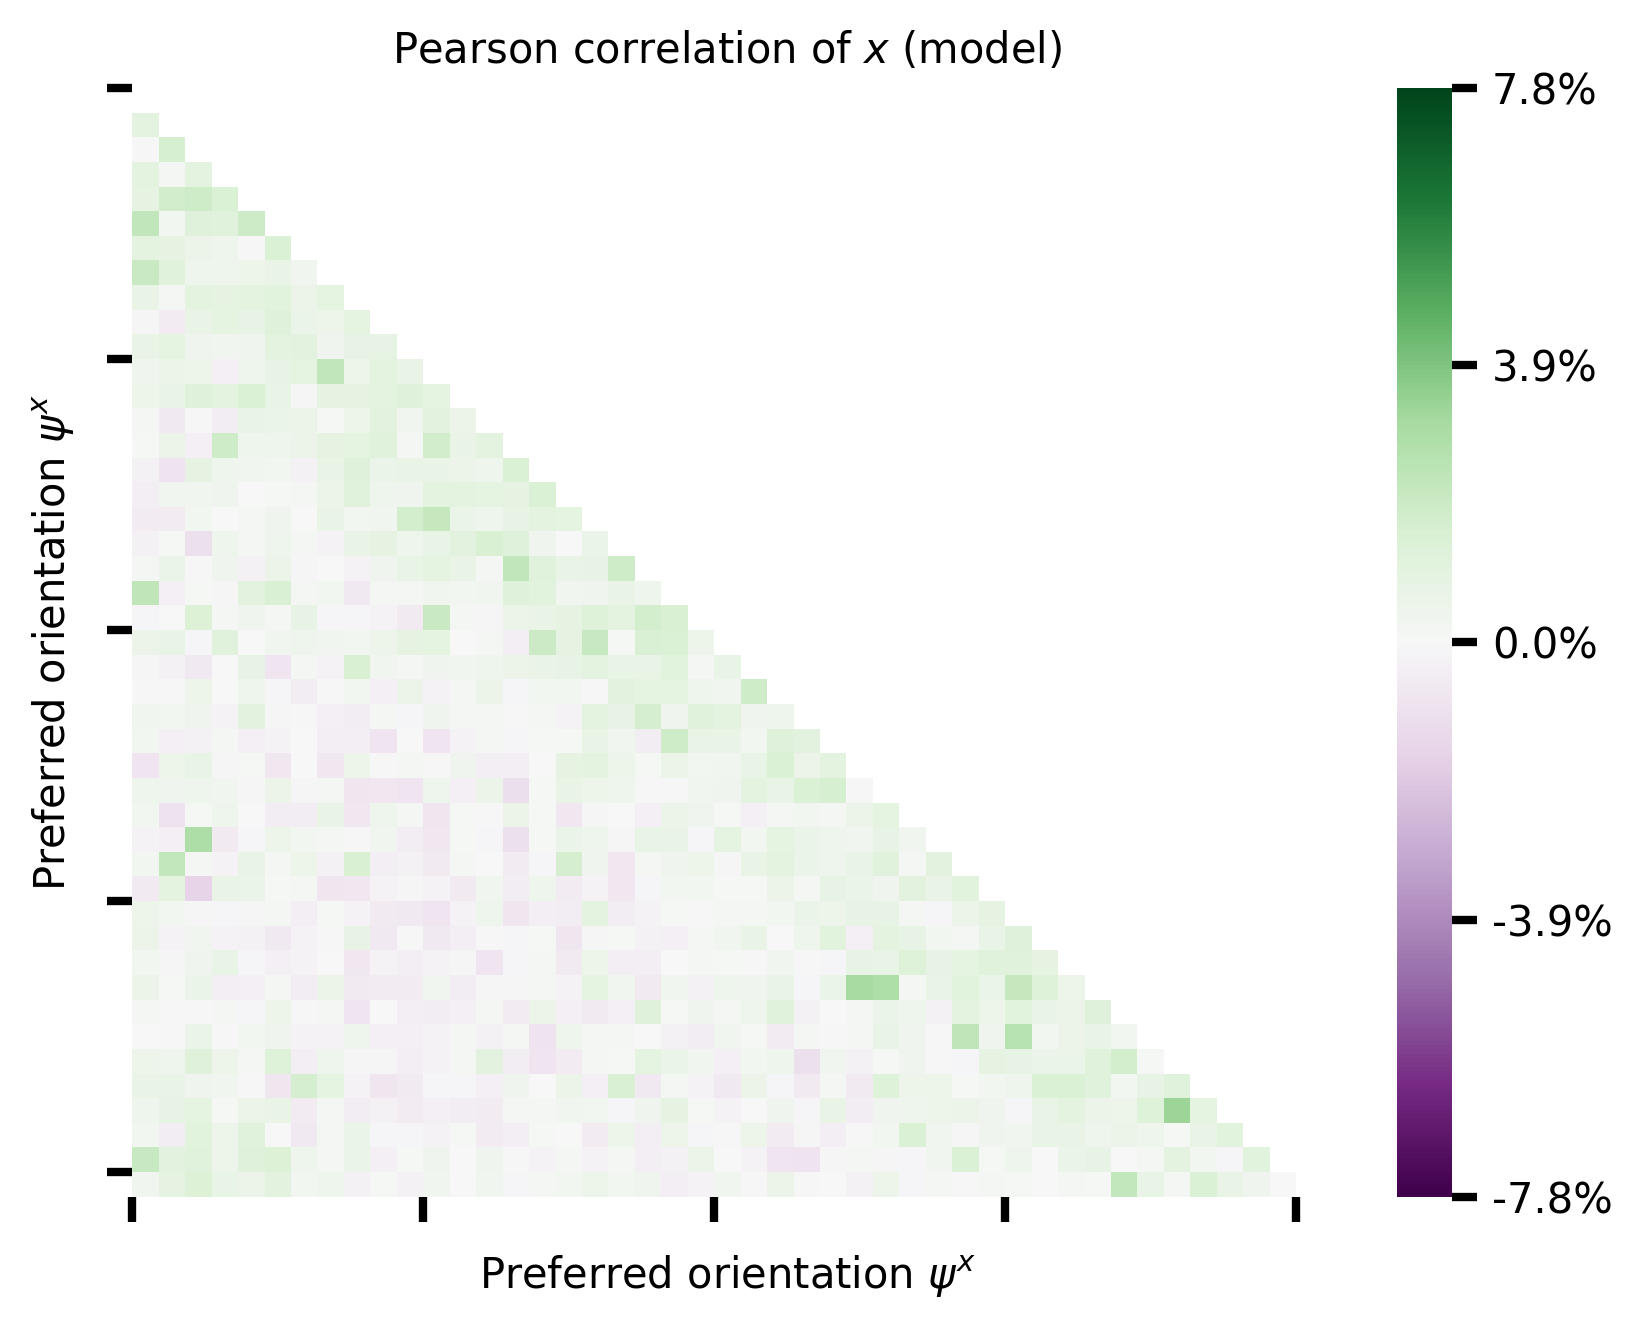

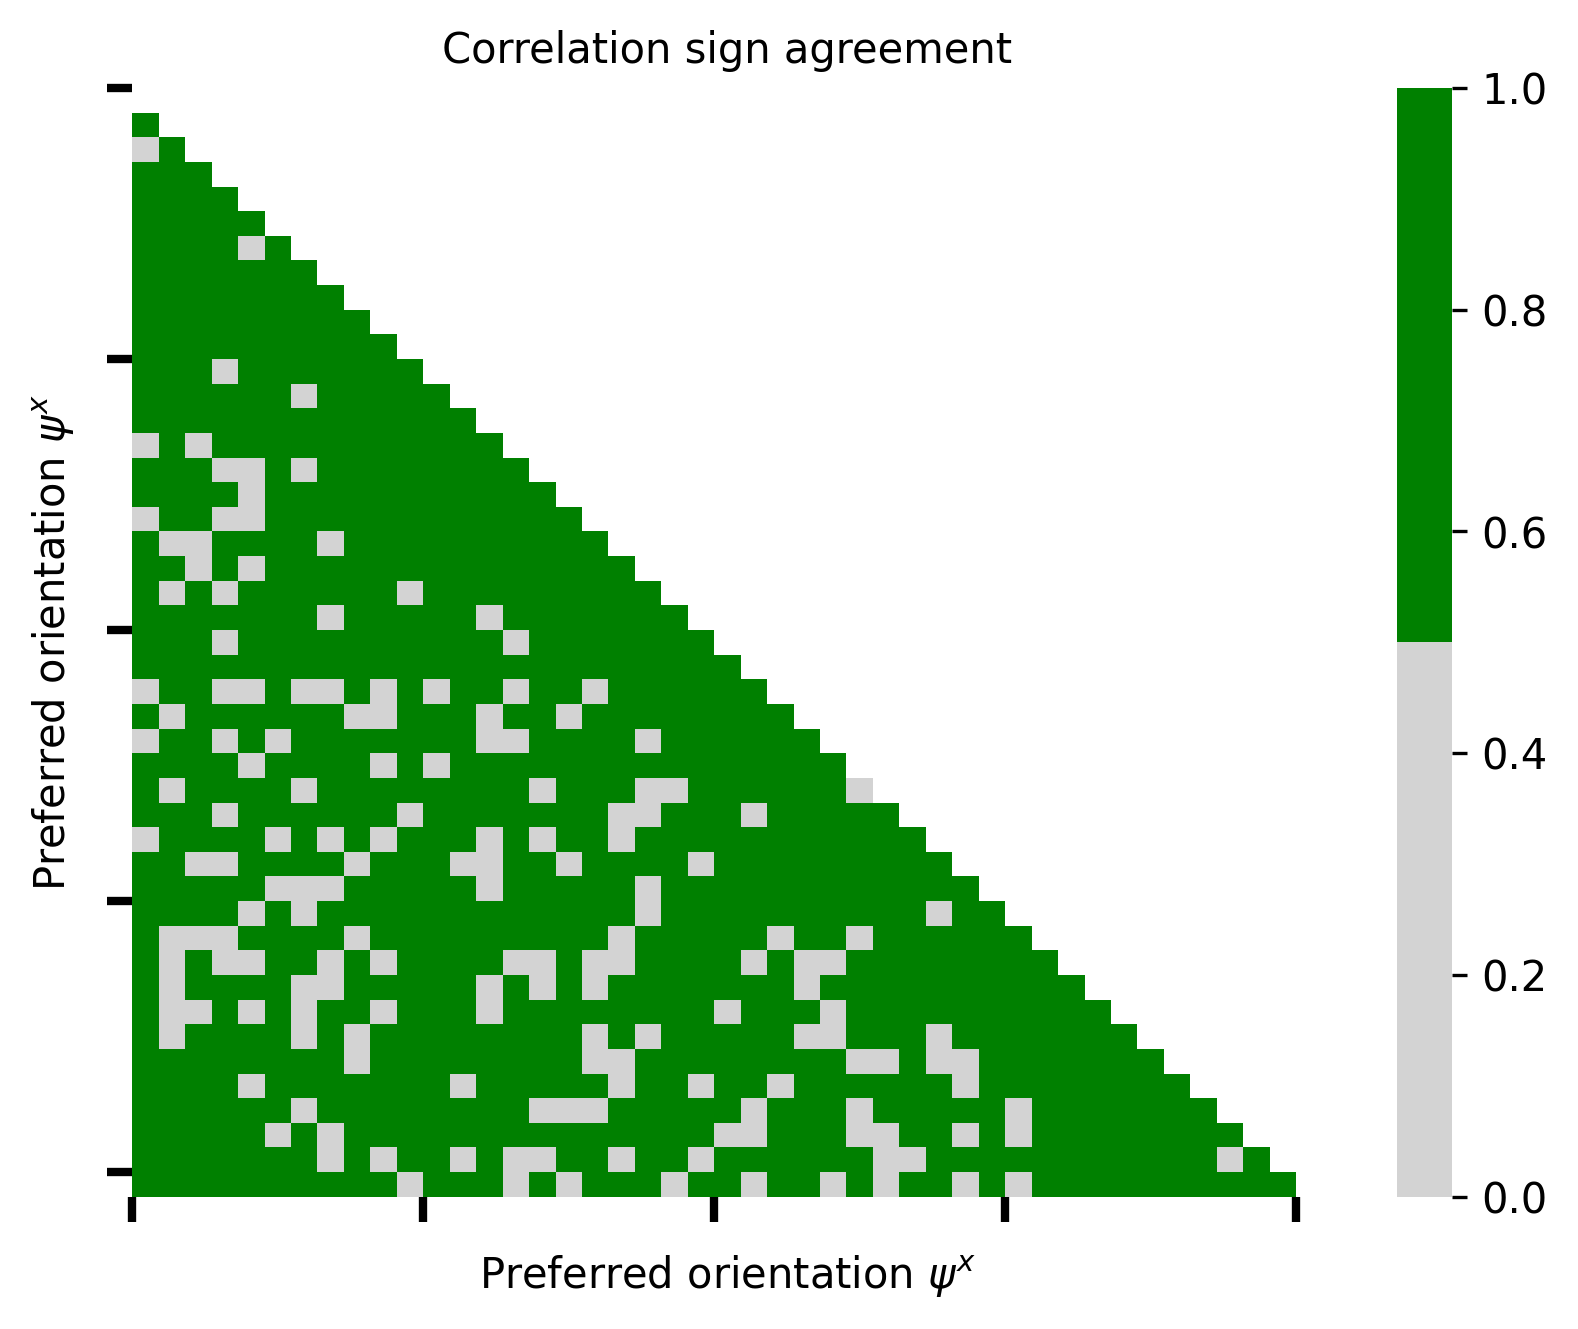

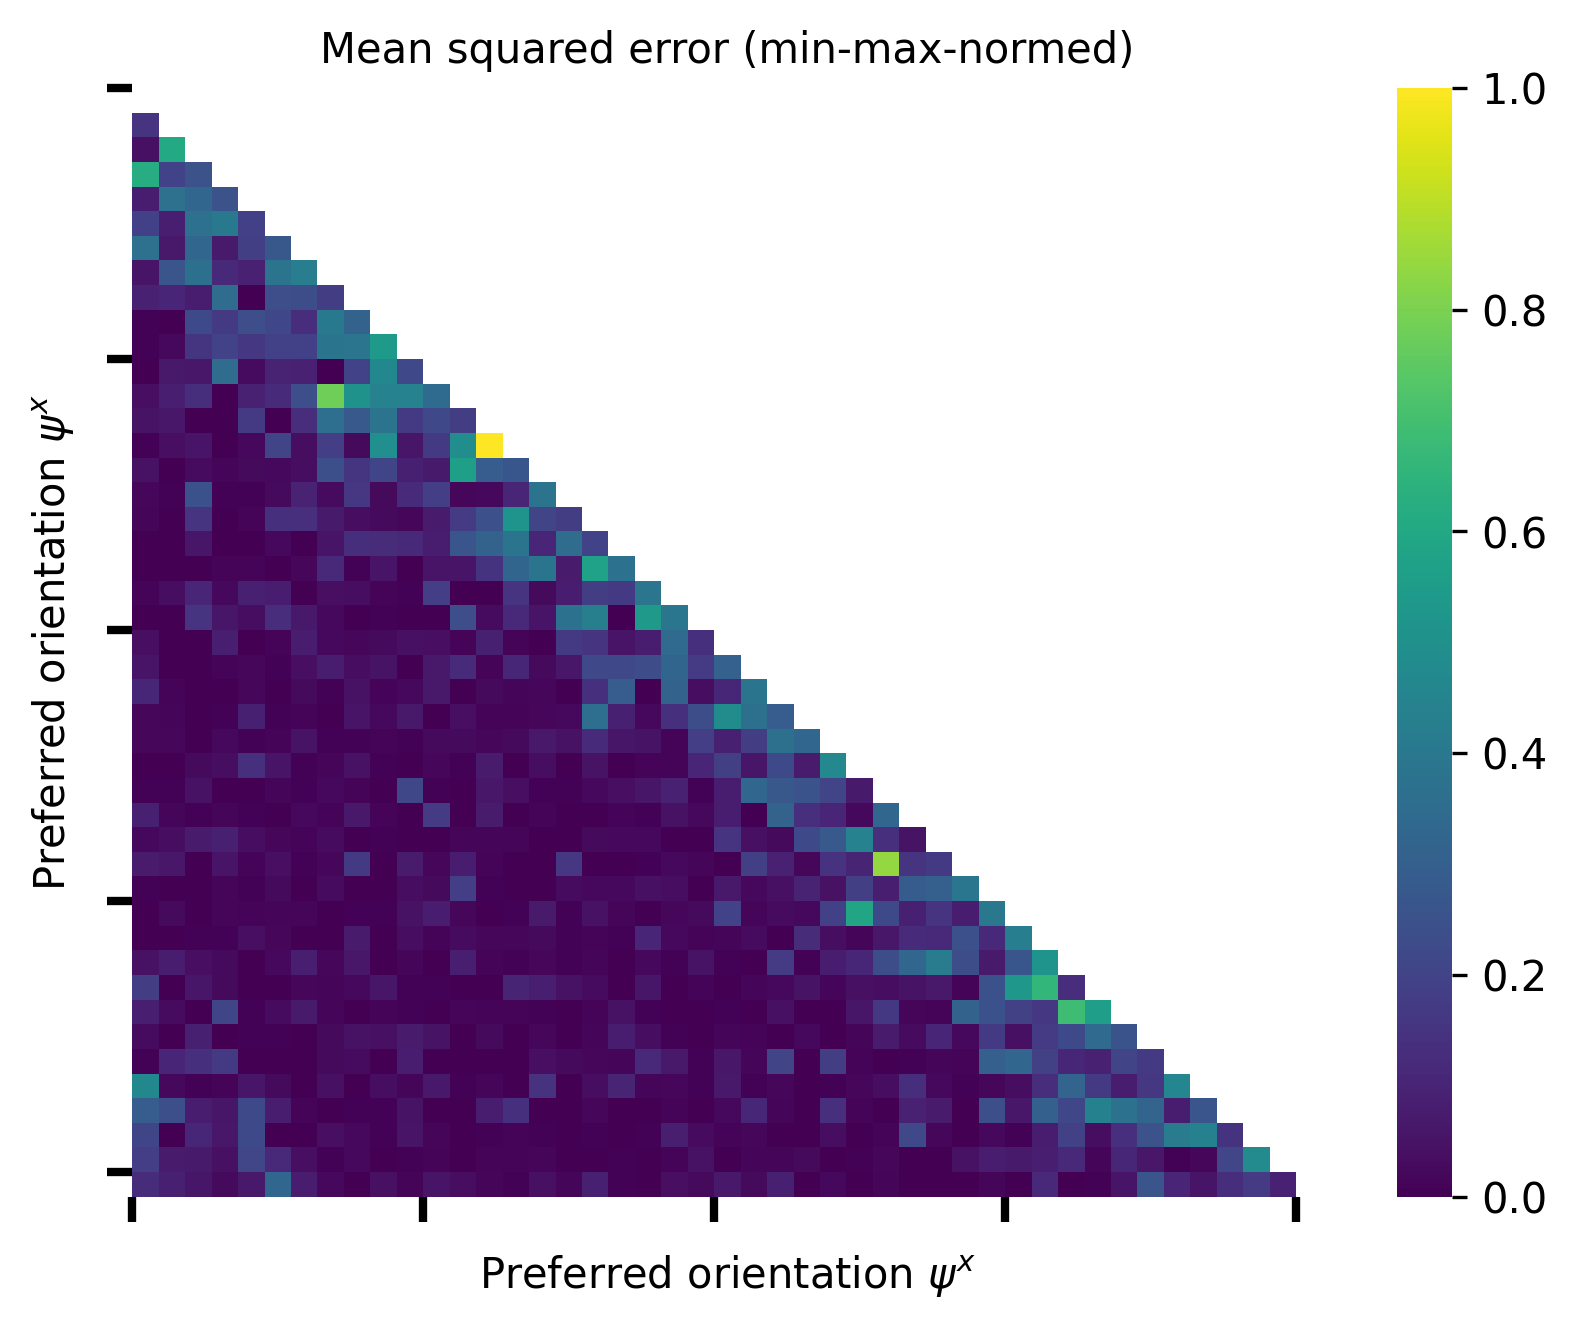

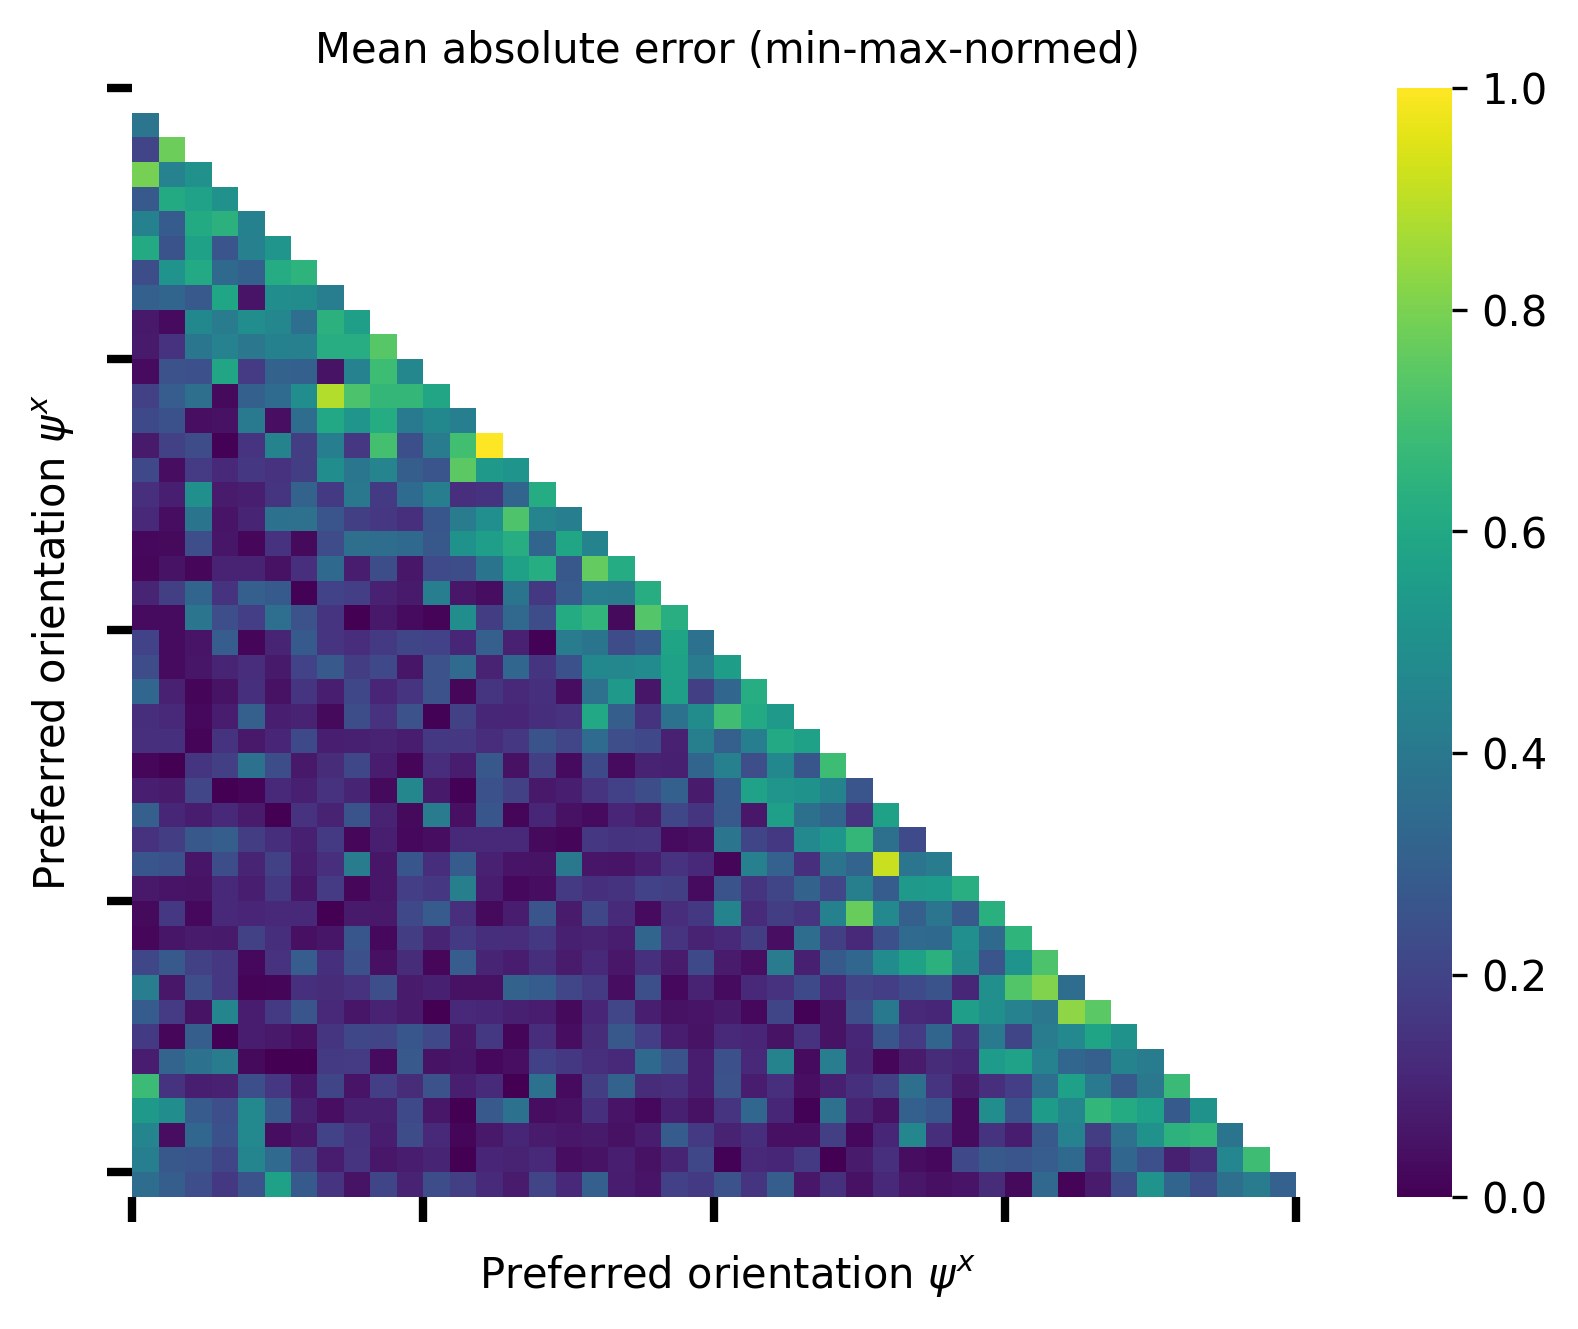

Press enter to continue to 1


In [10]:
for idx, best_val in enumerate(best_val_results):
    flow_path = best_val["model"]
    flow_model = torch.load(flow_path)
    flow_model.eval()
    data_path = best_val["data_fname"]
    train_prop = best_val["train_prop"]
    val_prop = best_val["val_prop"]
    batch_size = int(best_val["batch_size"])
    train_loader, val_loader, test_loader = build_dataloaders(
        data_path, train_prop, val_prop, batch_size
    )
    output = evaluate_flow_prior(flow_model, train_loader)
    print(f"Press enter to continue to {idx+1}")
    break

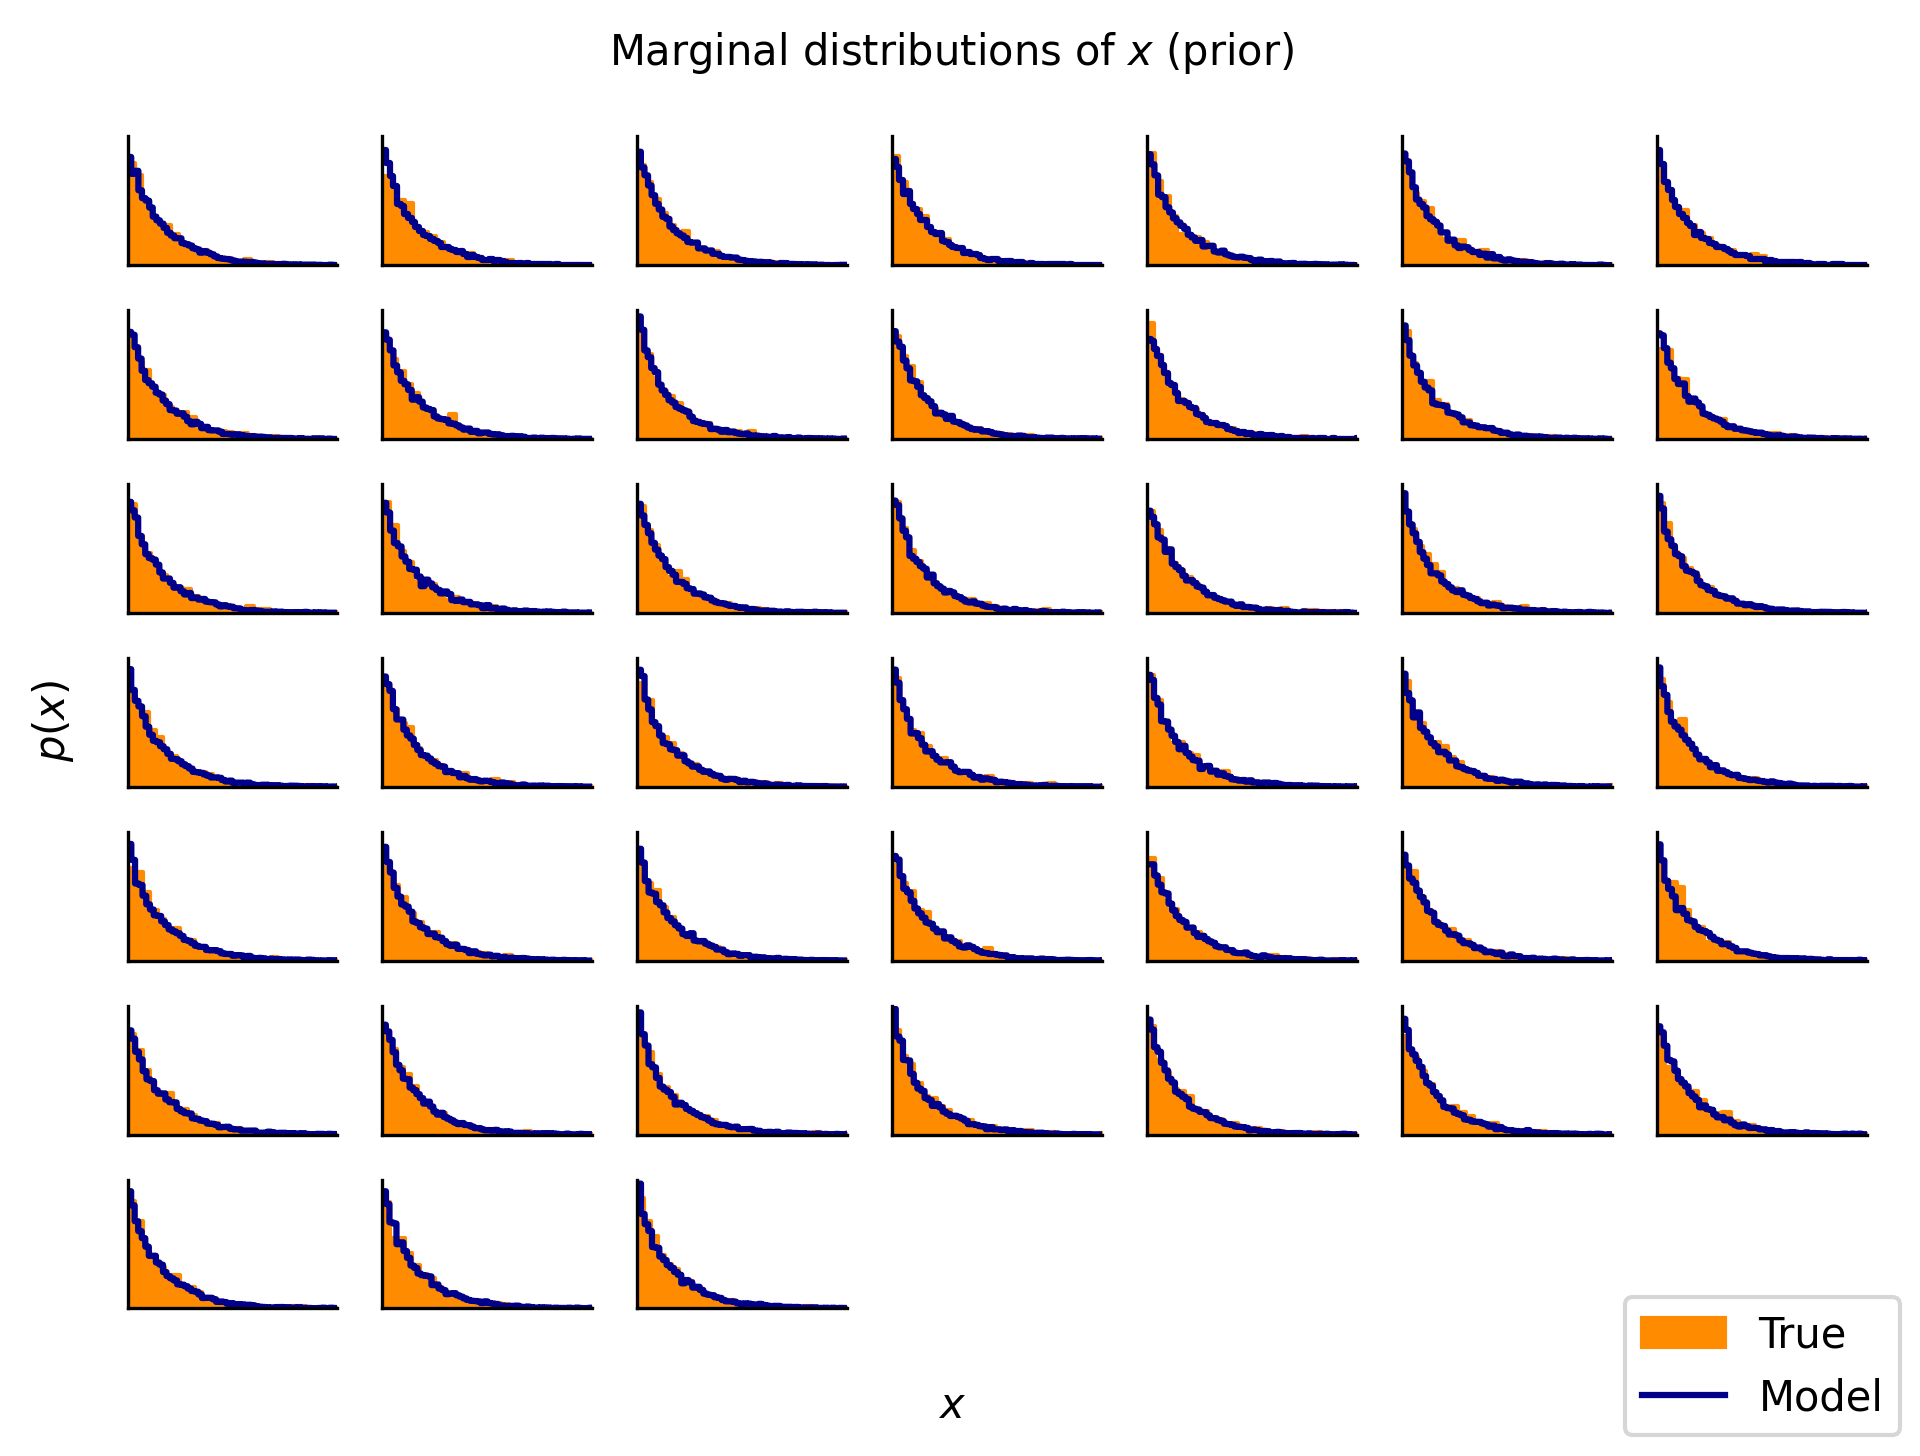

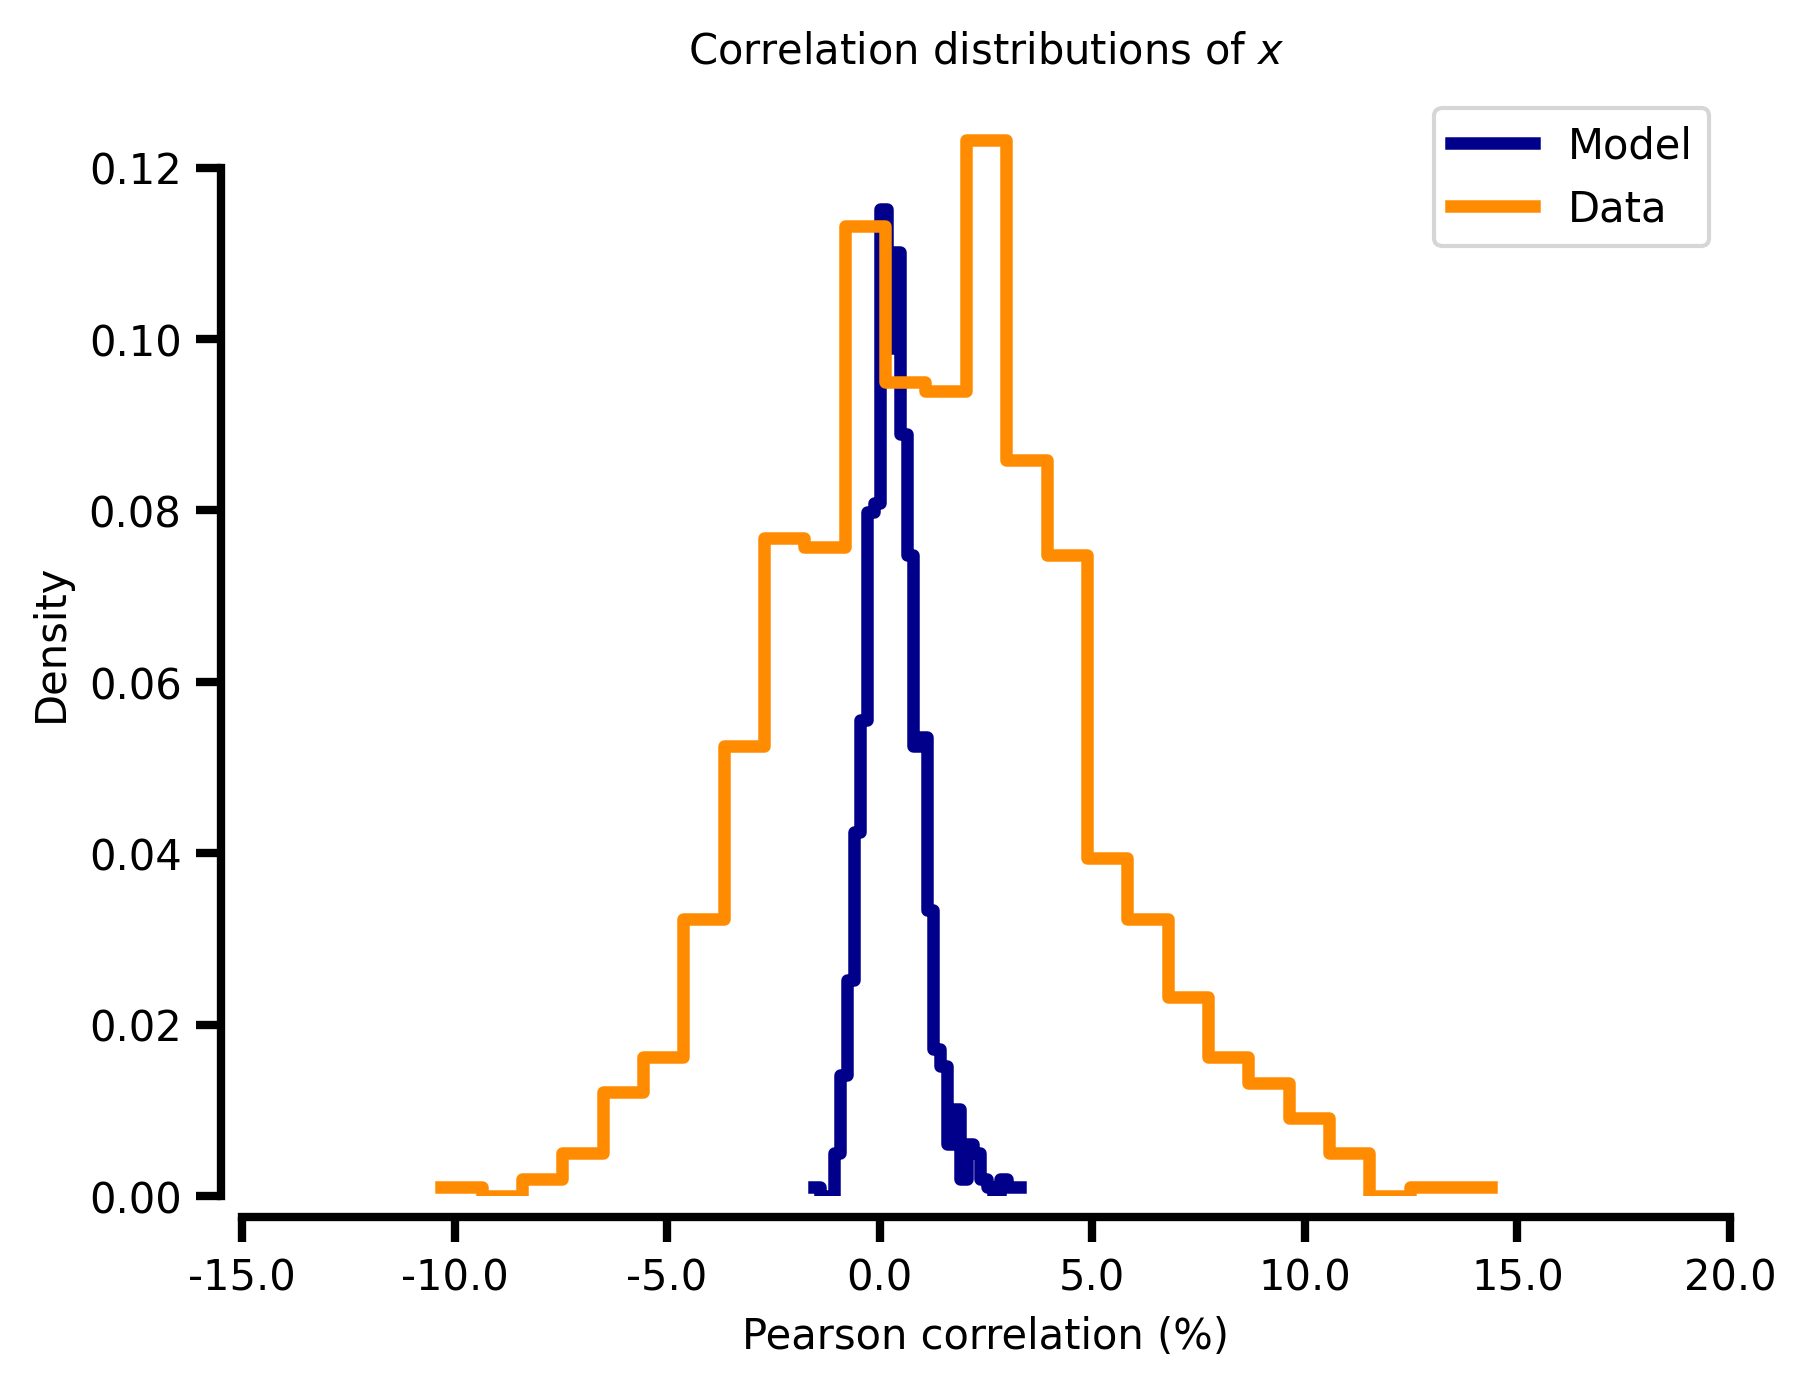

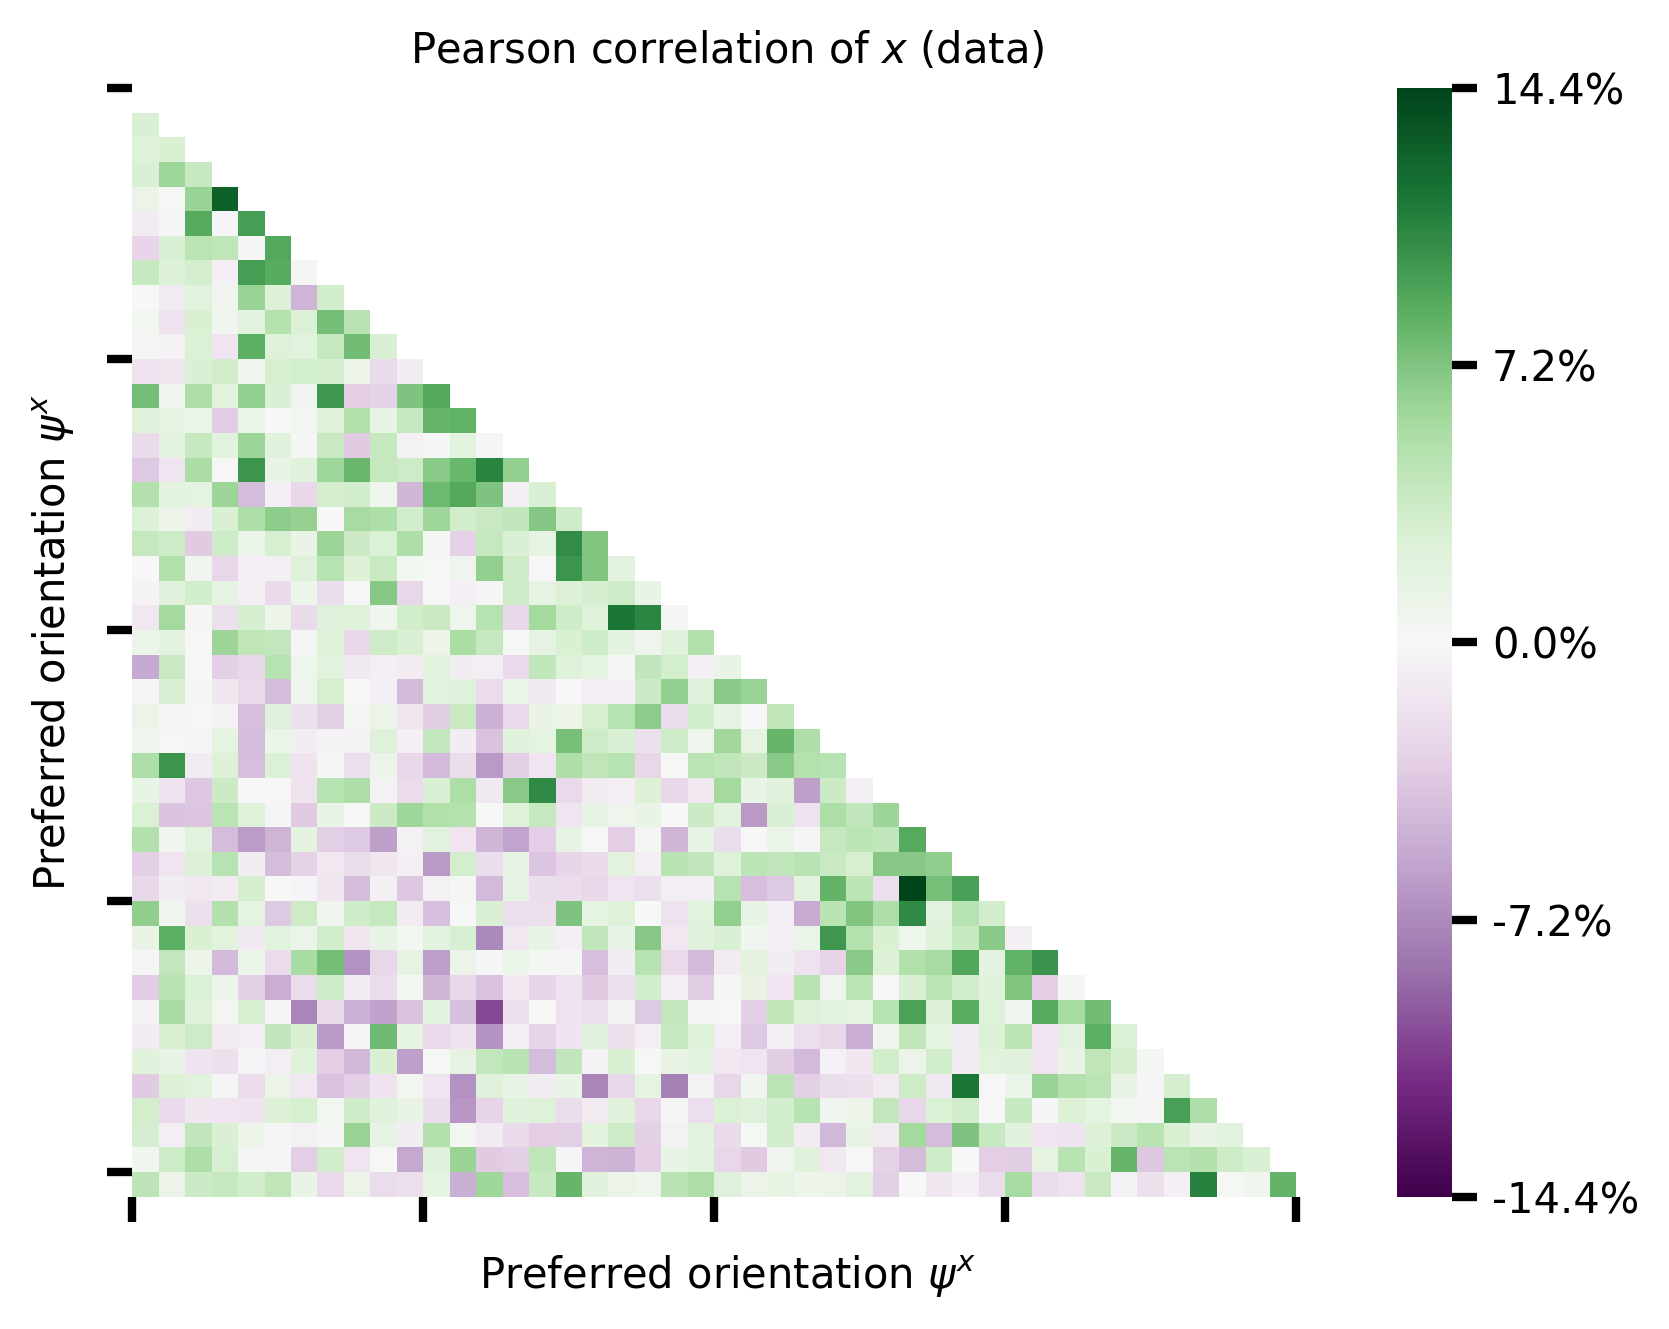

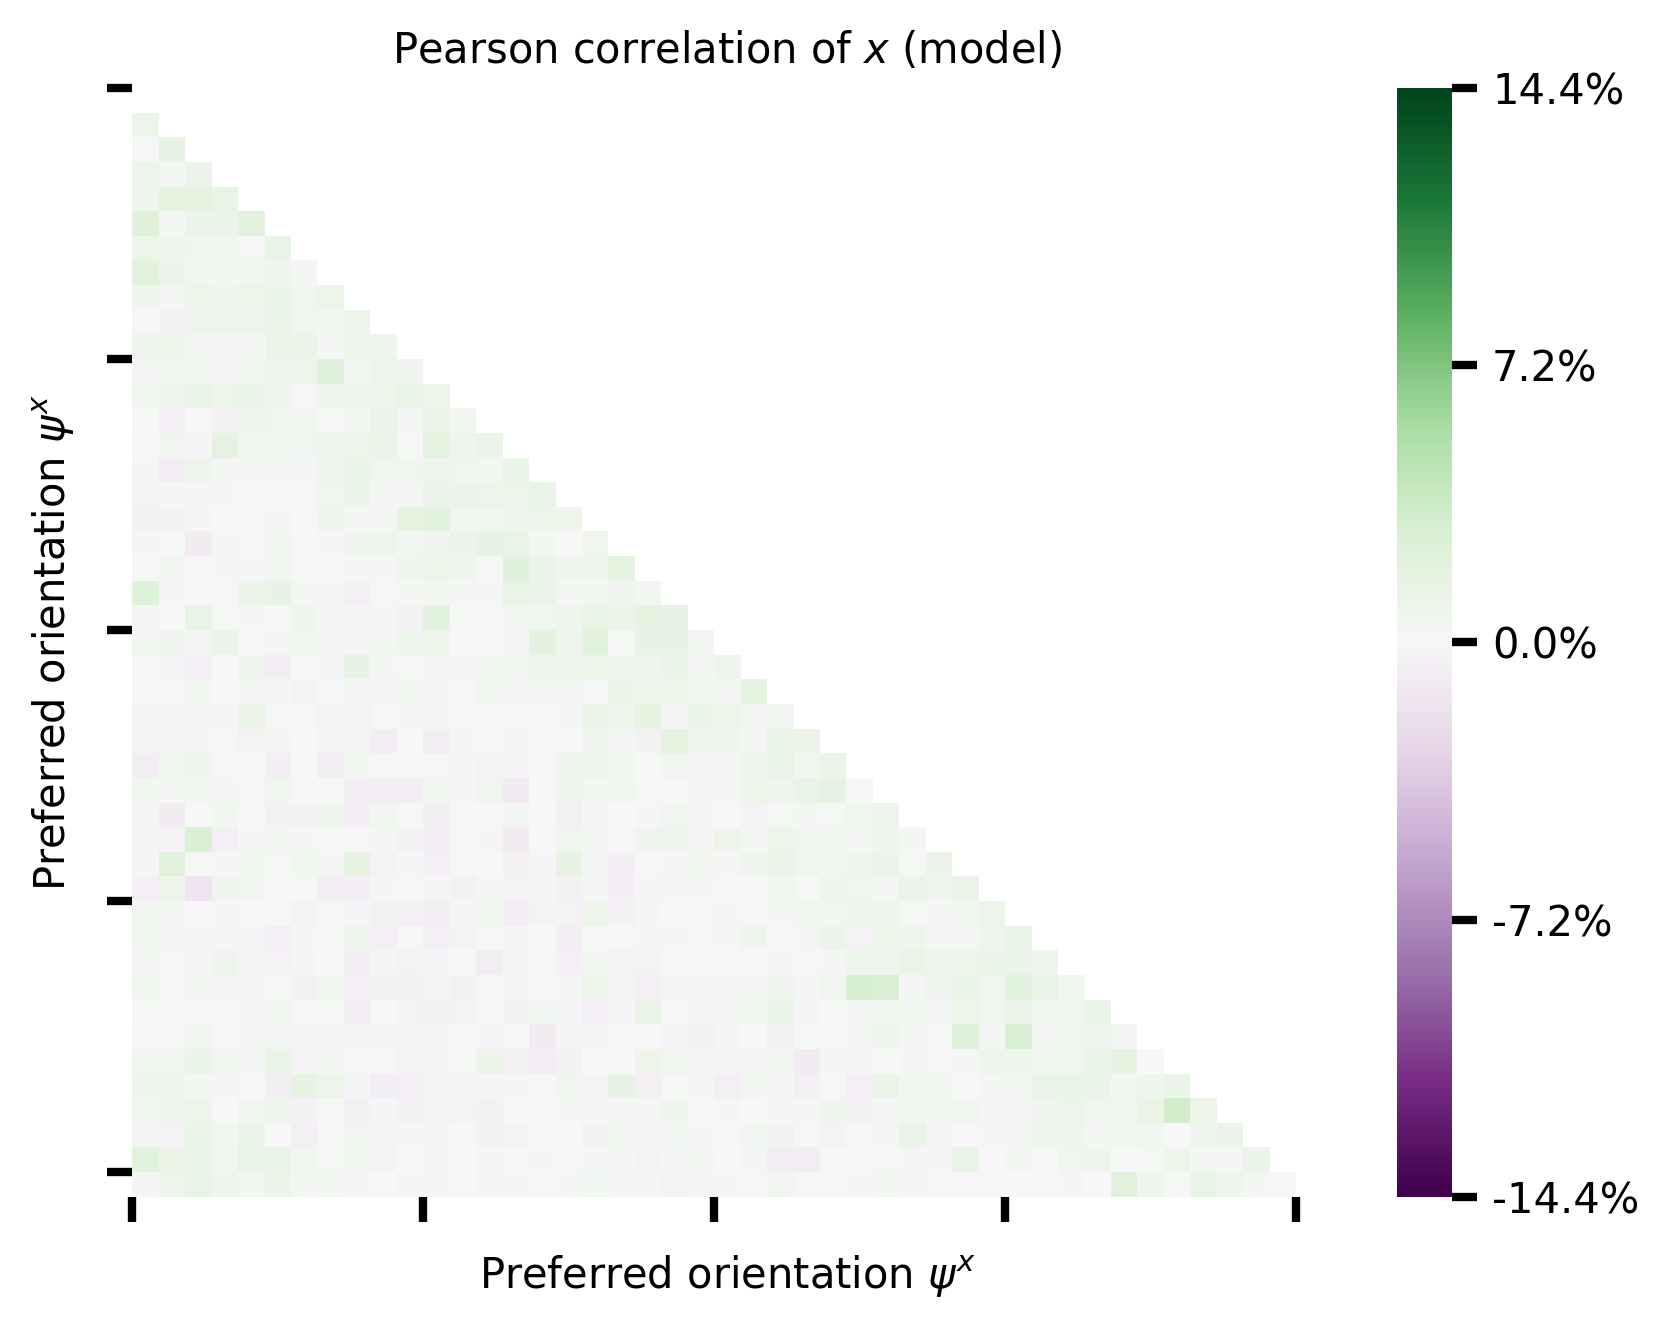

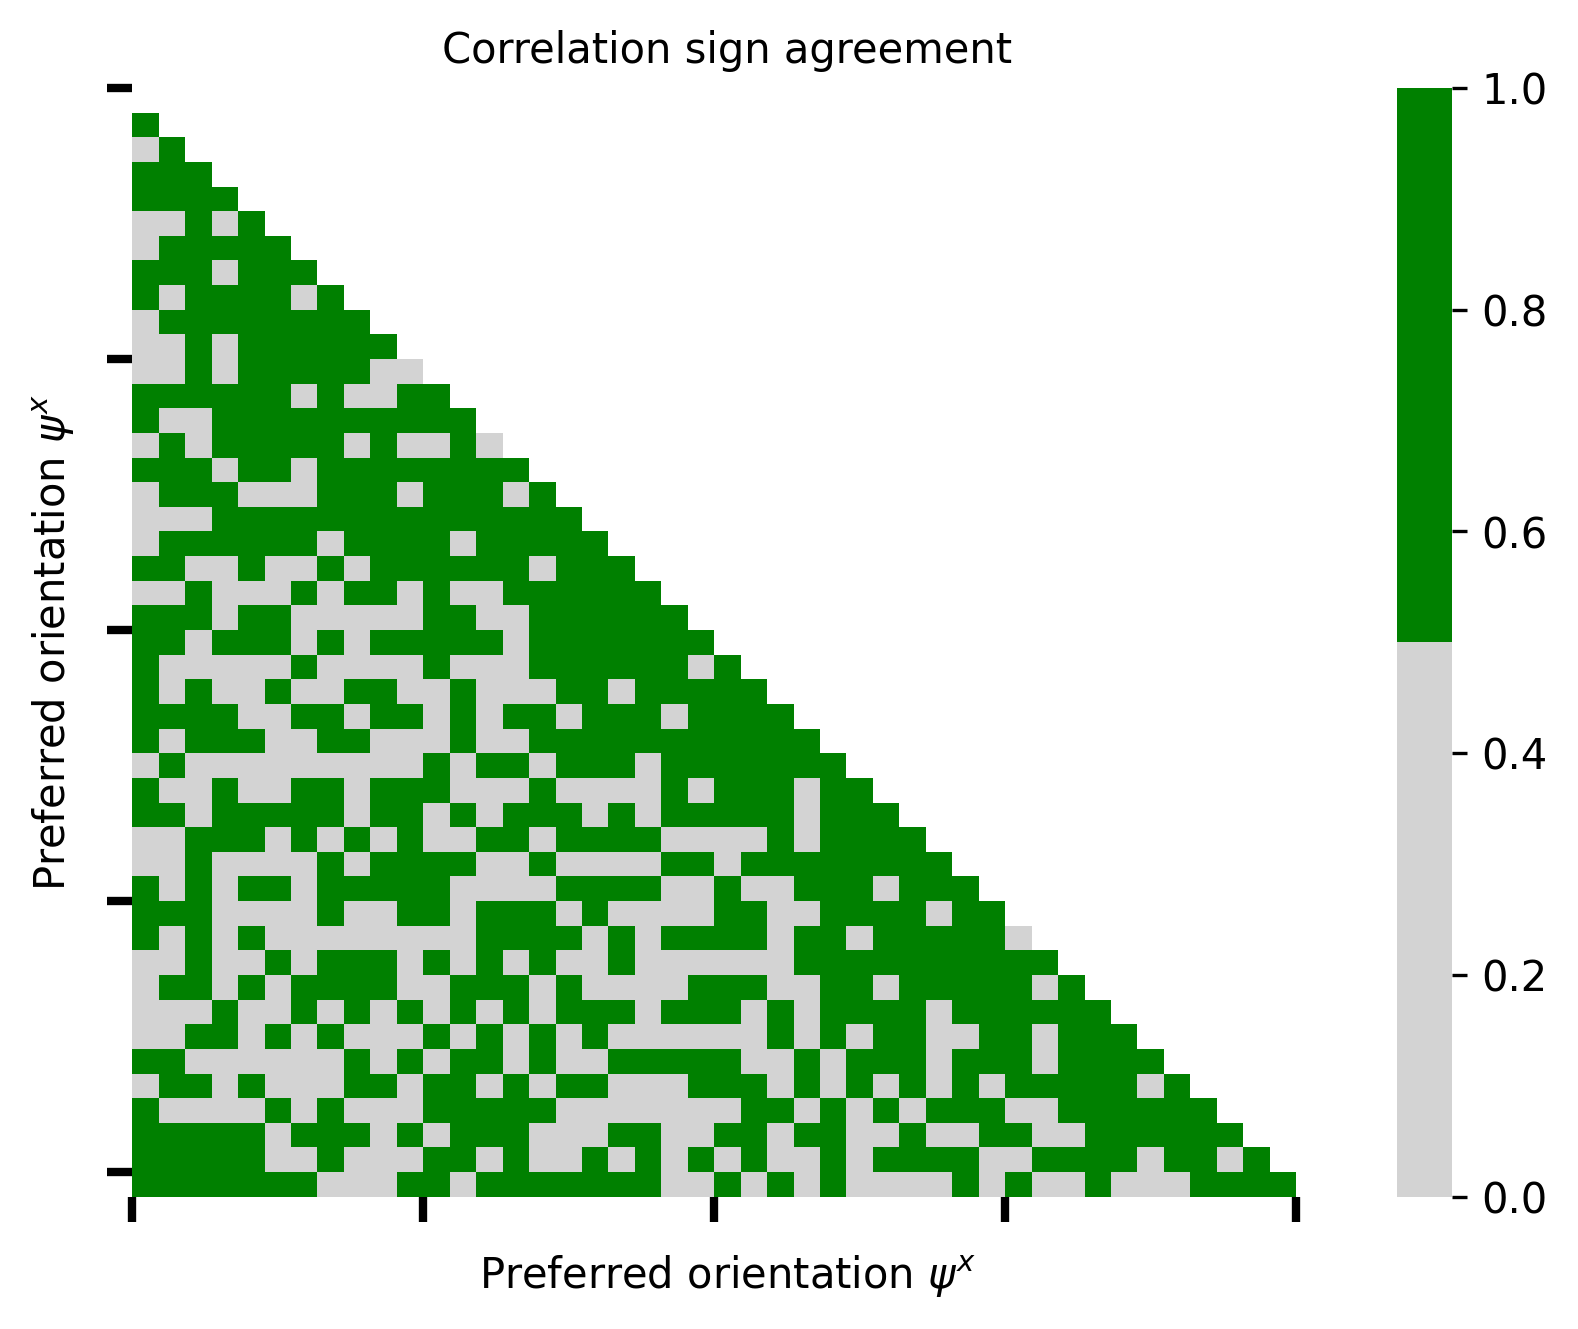

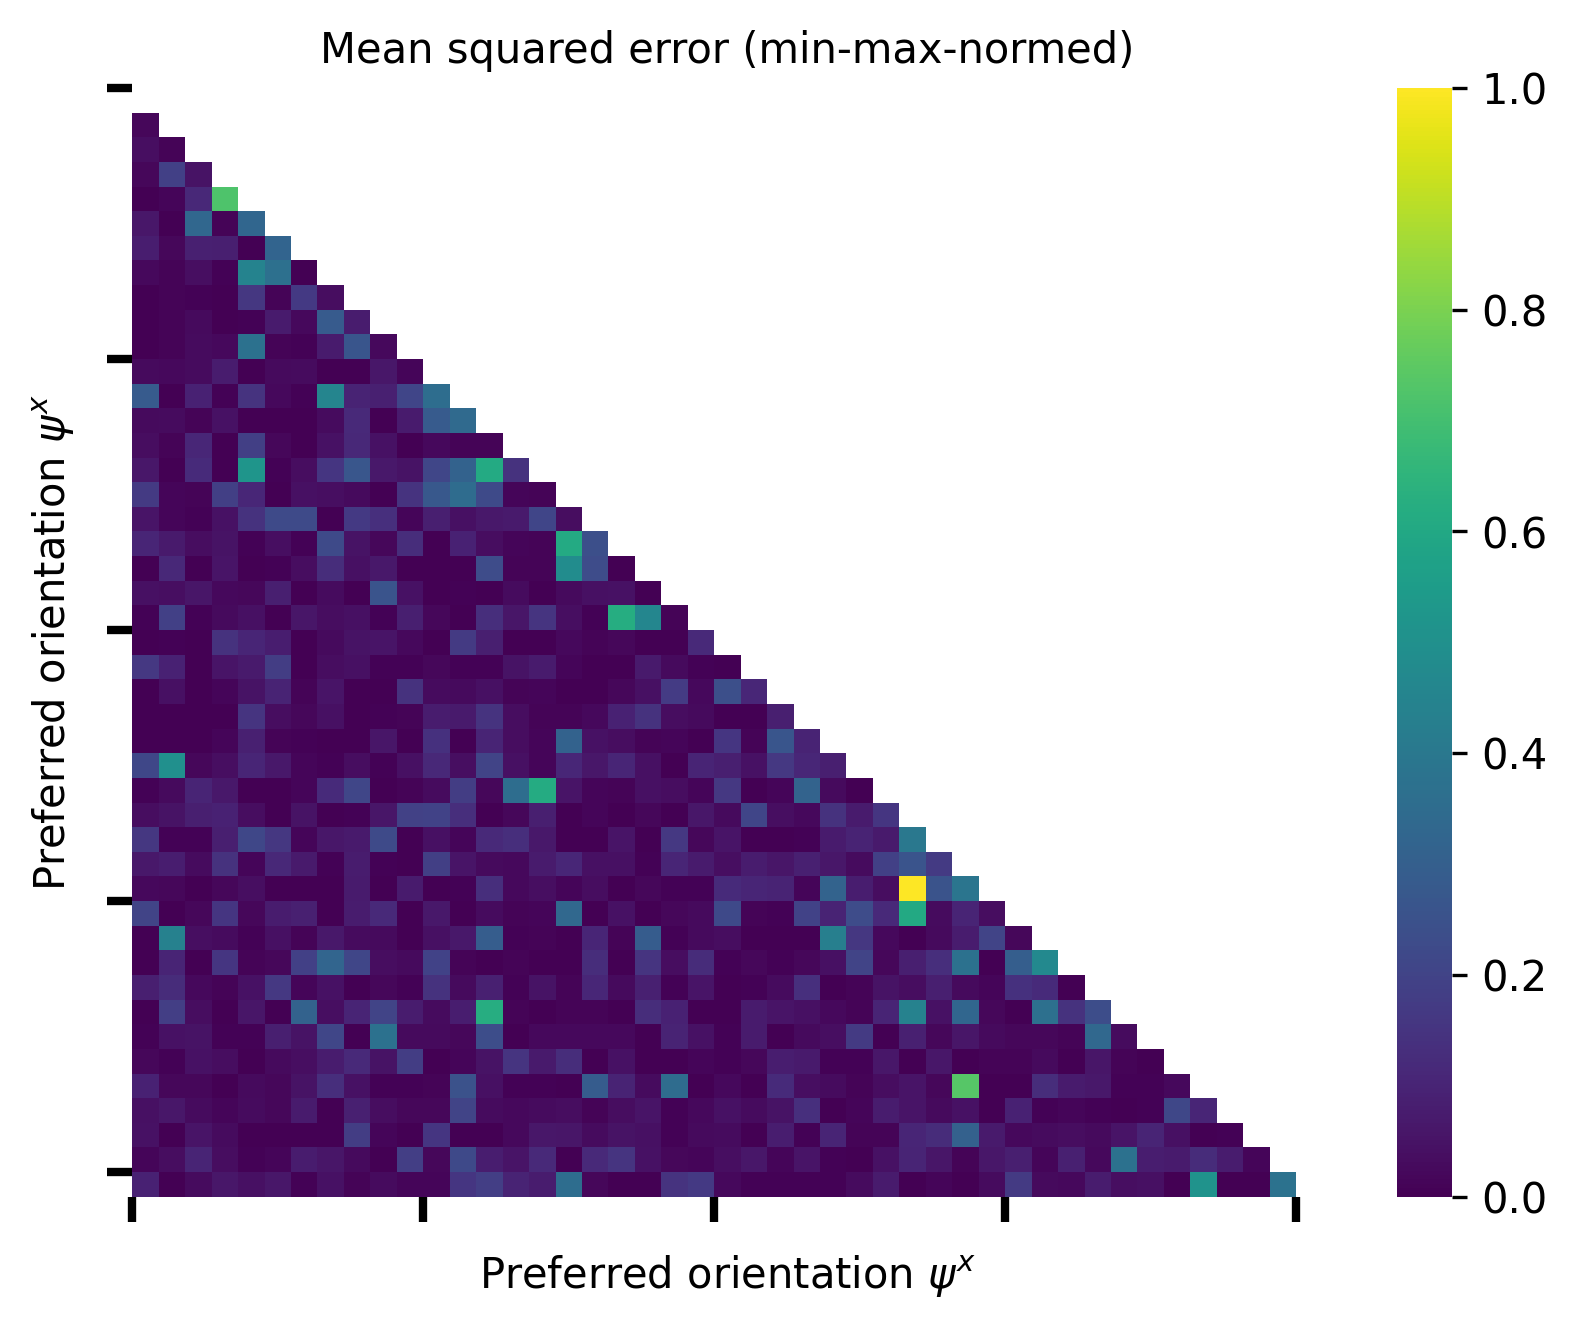

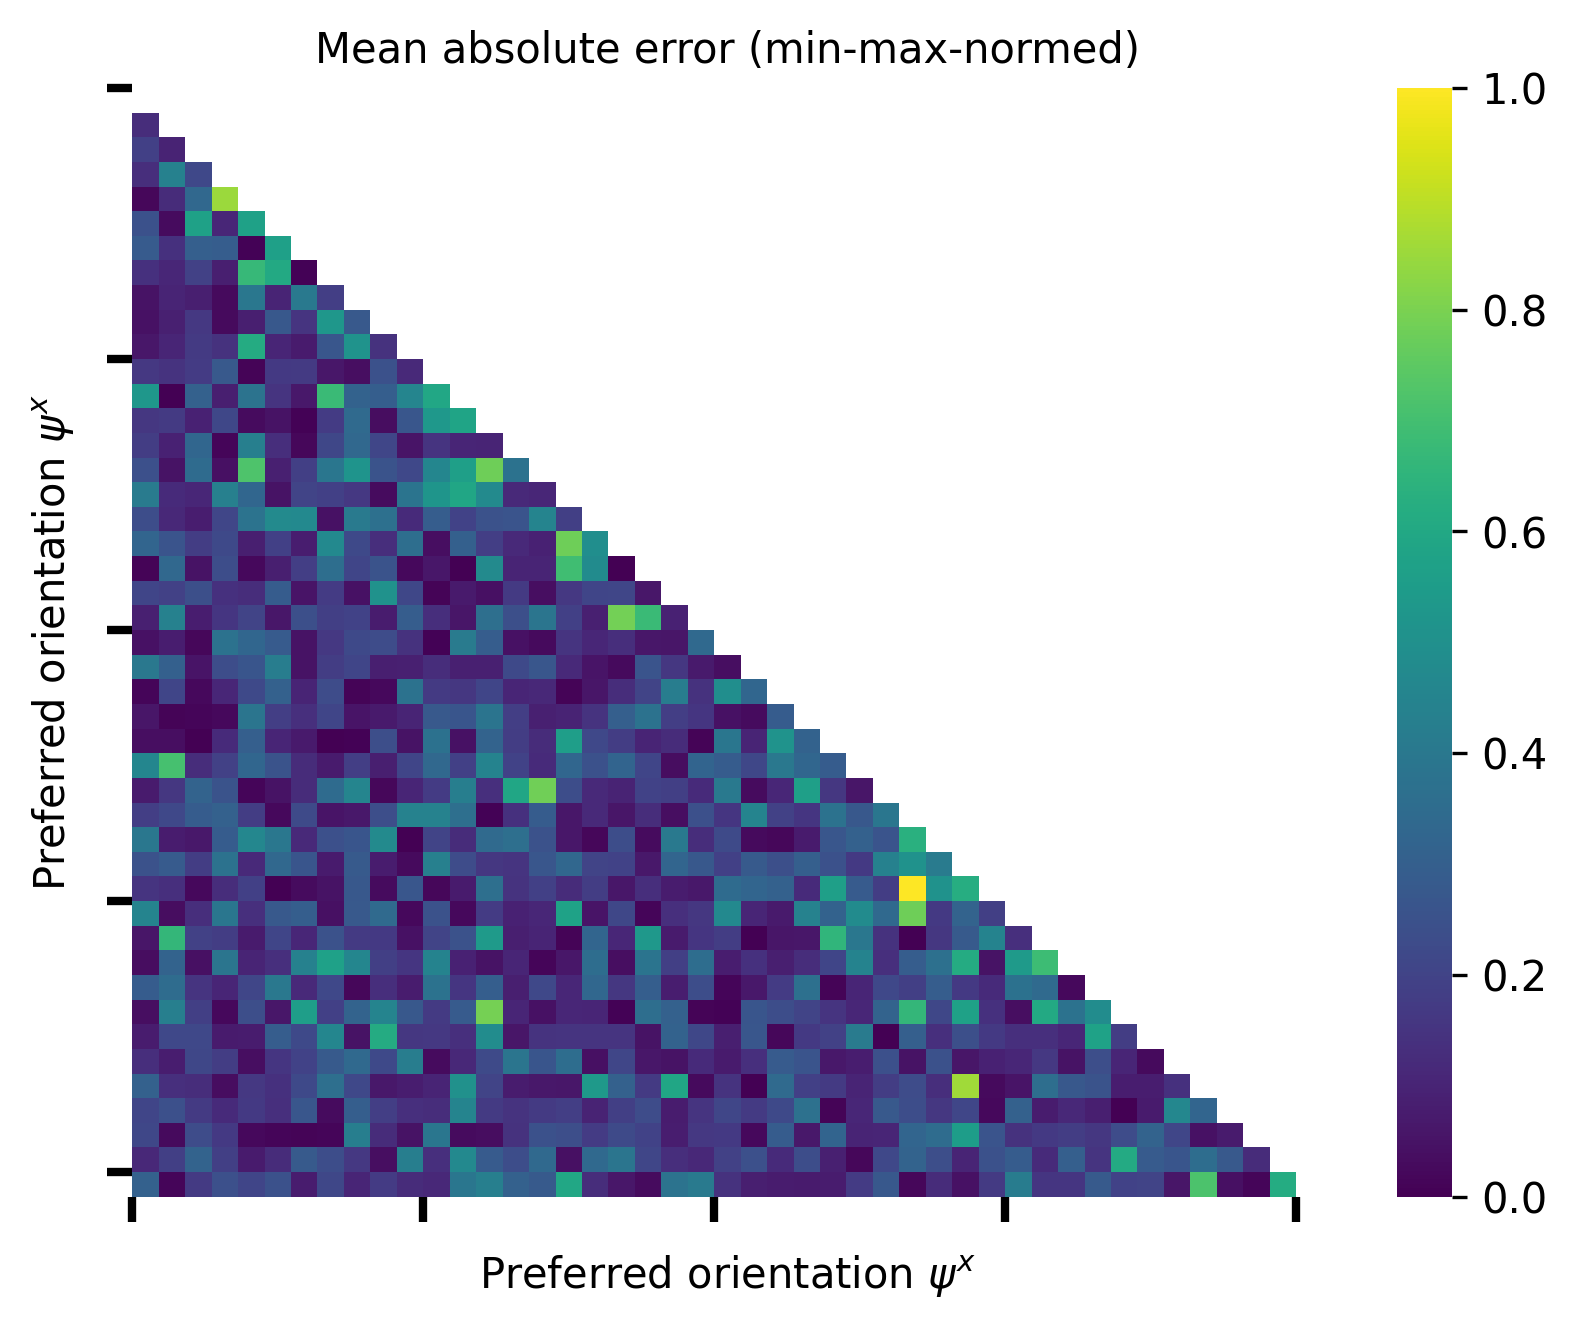

Press enter to continue to 1


In [11]:
for idx, best_val in enumerate(best_val_results):
    flow_path = best_val["model"]
    flow_model = torch.load(flow_path)
    flow_model.eval()
    data_path = best_val["data_fname"]
    train_prop = best_val["train_prop"]
    val_prop = best_val["val_prop"]
    batch_size = int(best_val["batch_size"])
    train_loader, val_loader, test_loader = build_dataloaders(
        data_path, train_prop, val_prop, batch_size
    )
    output = evaluate_flow_prior(flow_model, test_loader)
    print(f"Press enter to continue to {idx+1}")
    break

In [3]:
best_val = (
    result_table & "flow_initial_nonlin = 'log'"
).fetch(download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True)[0]

In [4]:
best_val

{'fp_id': 'f8f756f6b95f27ea16ae957789646279',
 'trainer_id': 'c40a50ce9c77369770dddd5129836477',
 'dl_id': '260a5ea8175f75eaef132f42873ad14a',
 'train_ll_mean': -55.076988220214844,
 'train_ll_sem': 1.2640671730041504,
 'val_ll_mean': -54.96074676513672,
 'val_ll_sem': 2.35827374458313,
 'test_ll_mean': -54.96074676513672,
 'test_ll_sem': 2.35827374458313,
 'tracker_output': '/tmp/f8f756f6b95f27ea16ae957789646279_c40a50ce9c77369770dddd5129836477_260a5ea8175f75eaef132f42873ad14a_tracker_output.pkl',
 'eval_output': '/tmp/f8f756f6b95f27ea16ae957789646279_c40a50ce9c77369770dddd5129836477_260a5ea8175f75eaef132f42873ad14a_eval_output.pkl',
 'model': '/tmp/f8f756f6b95f27ea16ae957789646279_c40a50ce9c77369770dddd5129836477_260a5ea8175f75eaef132f42873ad14a_model.pt',
 'seed': 100,
 'flow_depth': 0,
 'flow_initial_nonlin': 'log',
 'flow_final_nonlin': 'none',
 'flow_nonlin': 'none',
 'flow_base_dist': 'multivariate_normal_lrmn',
 'affine_type': 'none',
 'data_fname': '/src/project/data/synthetic

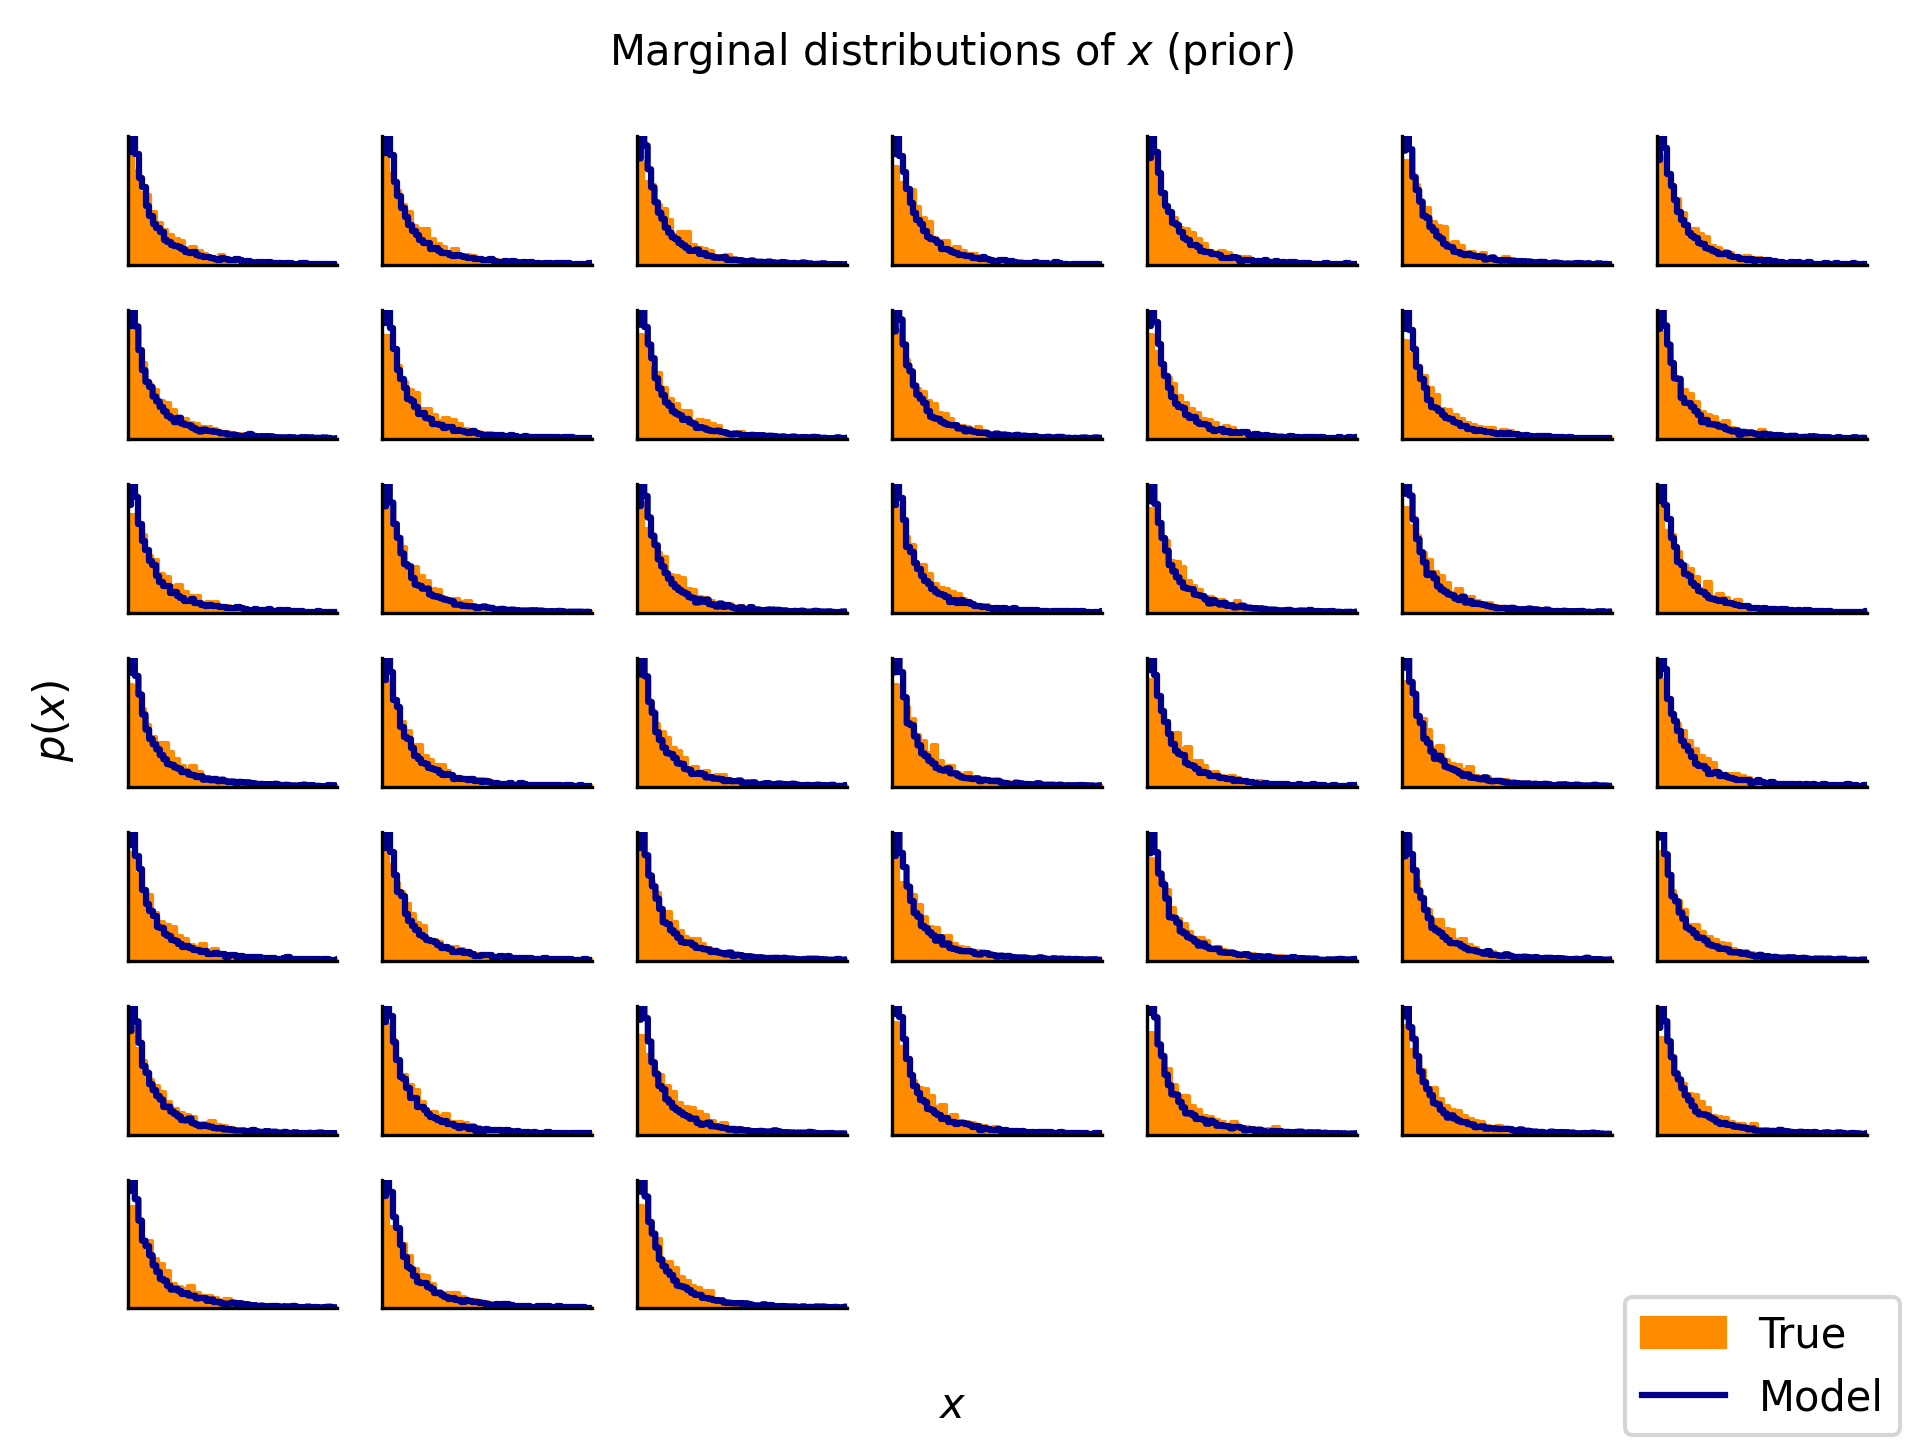

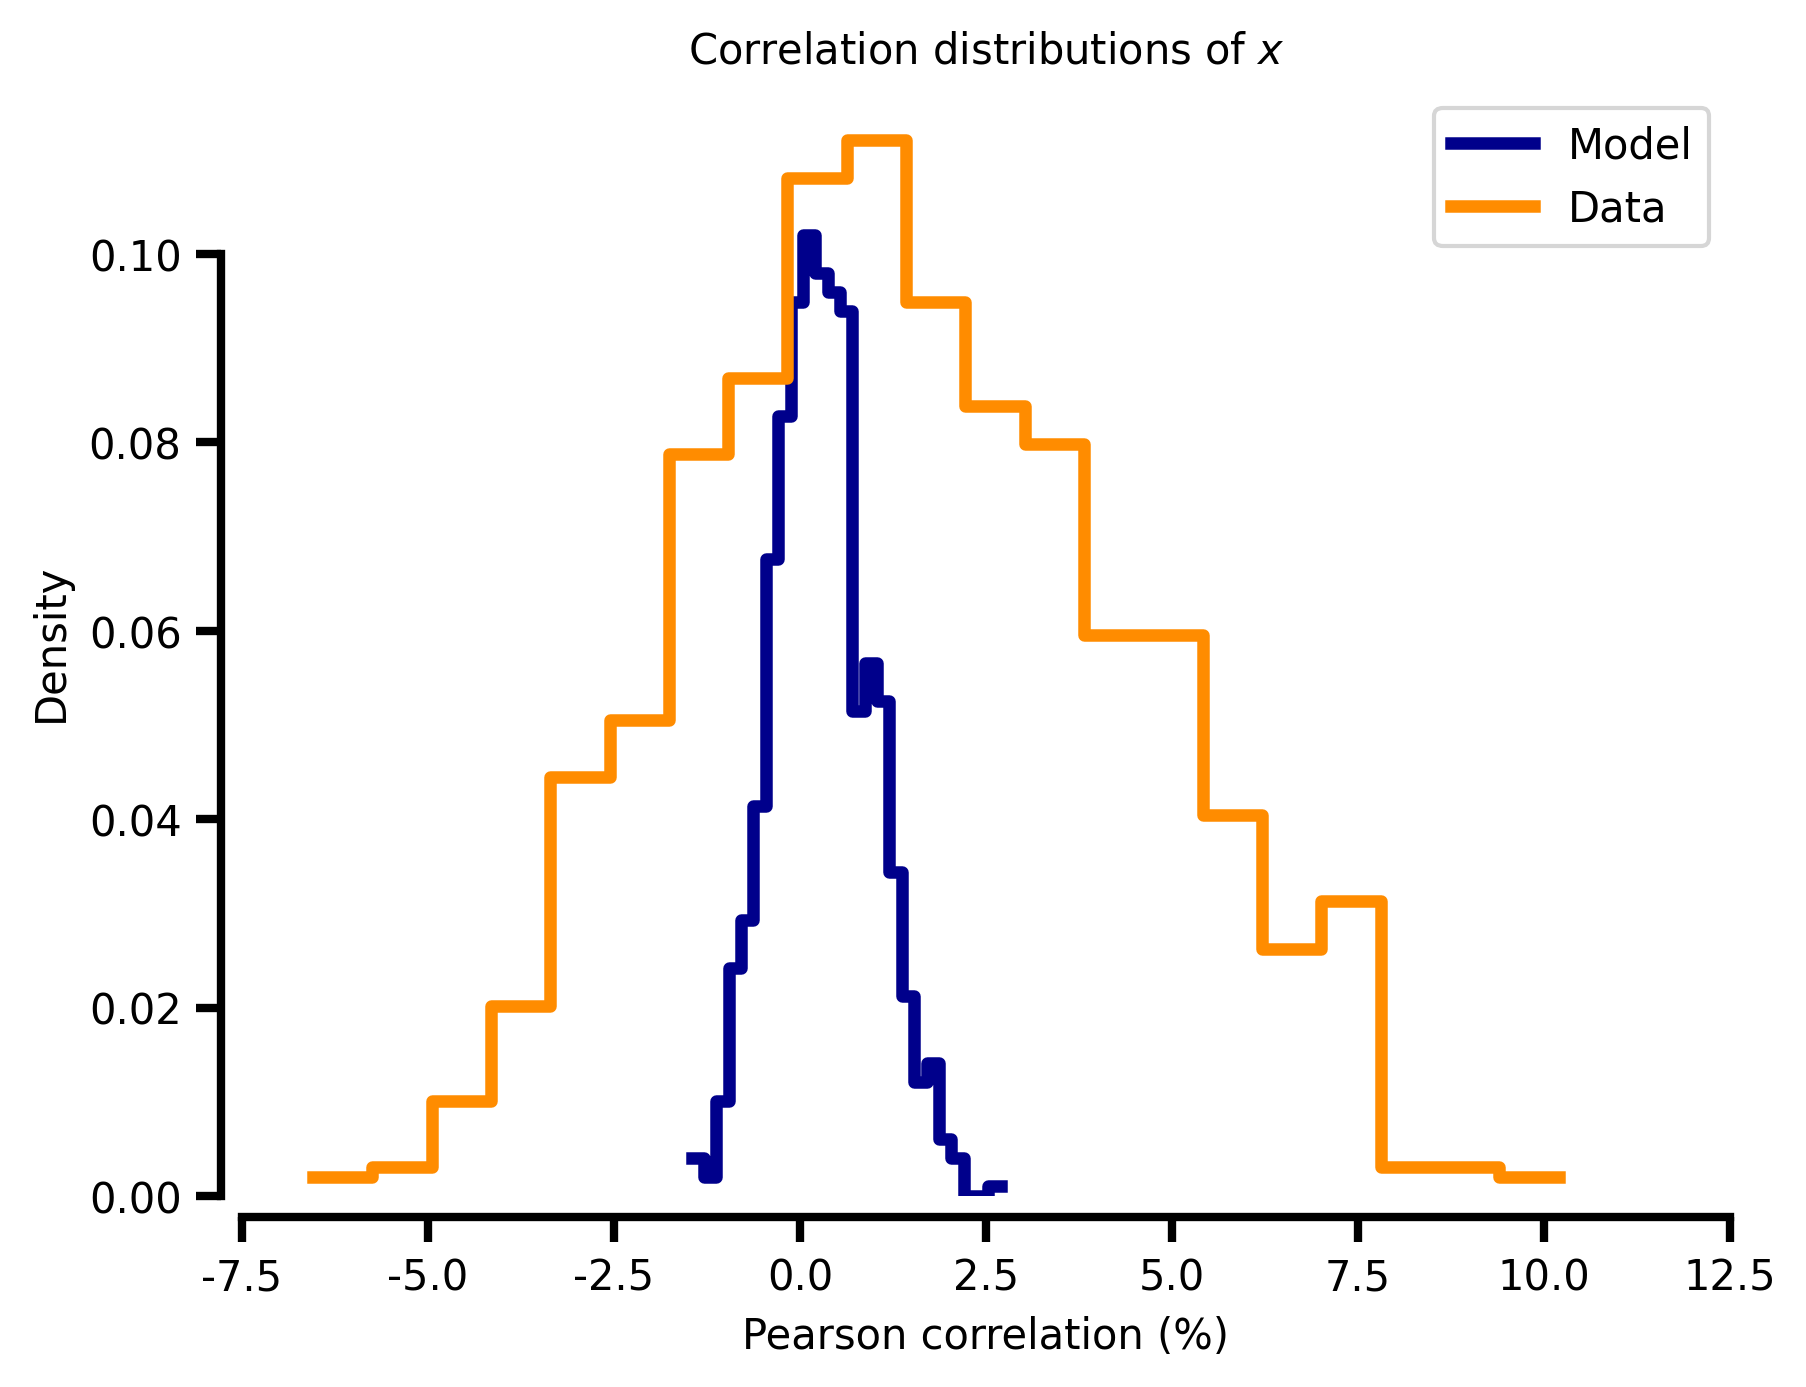

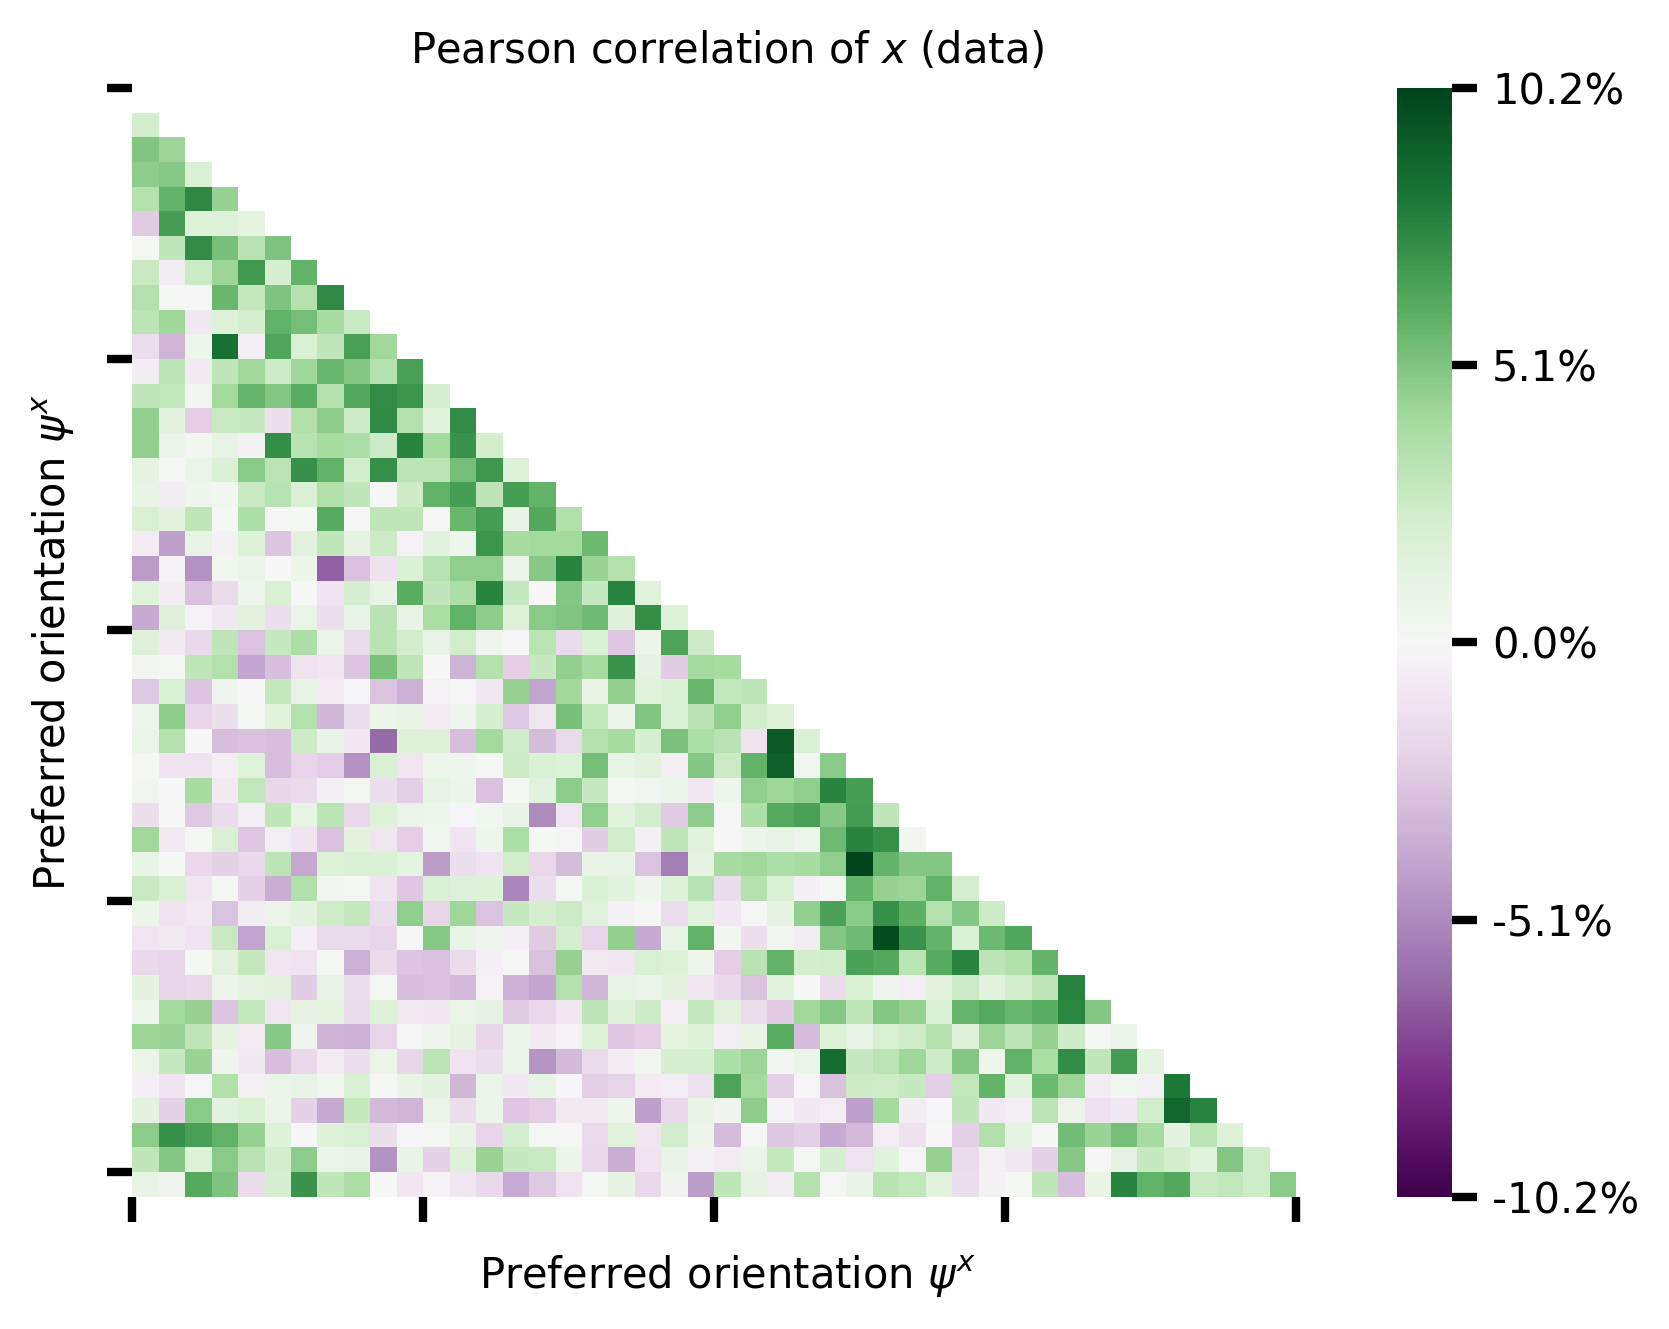

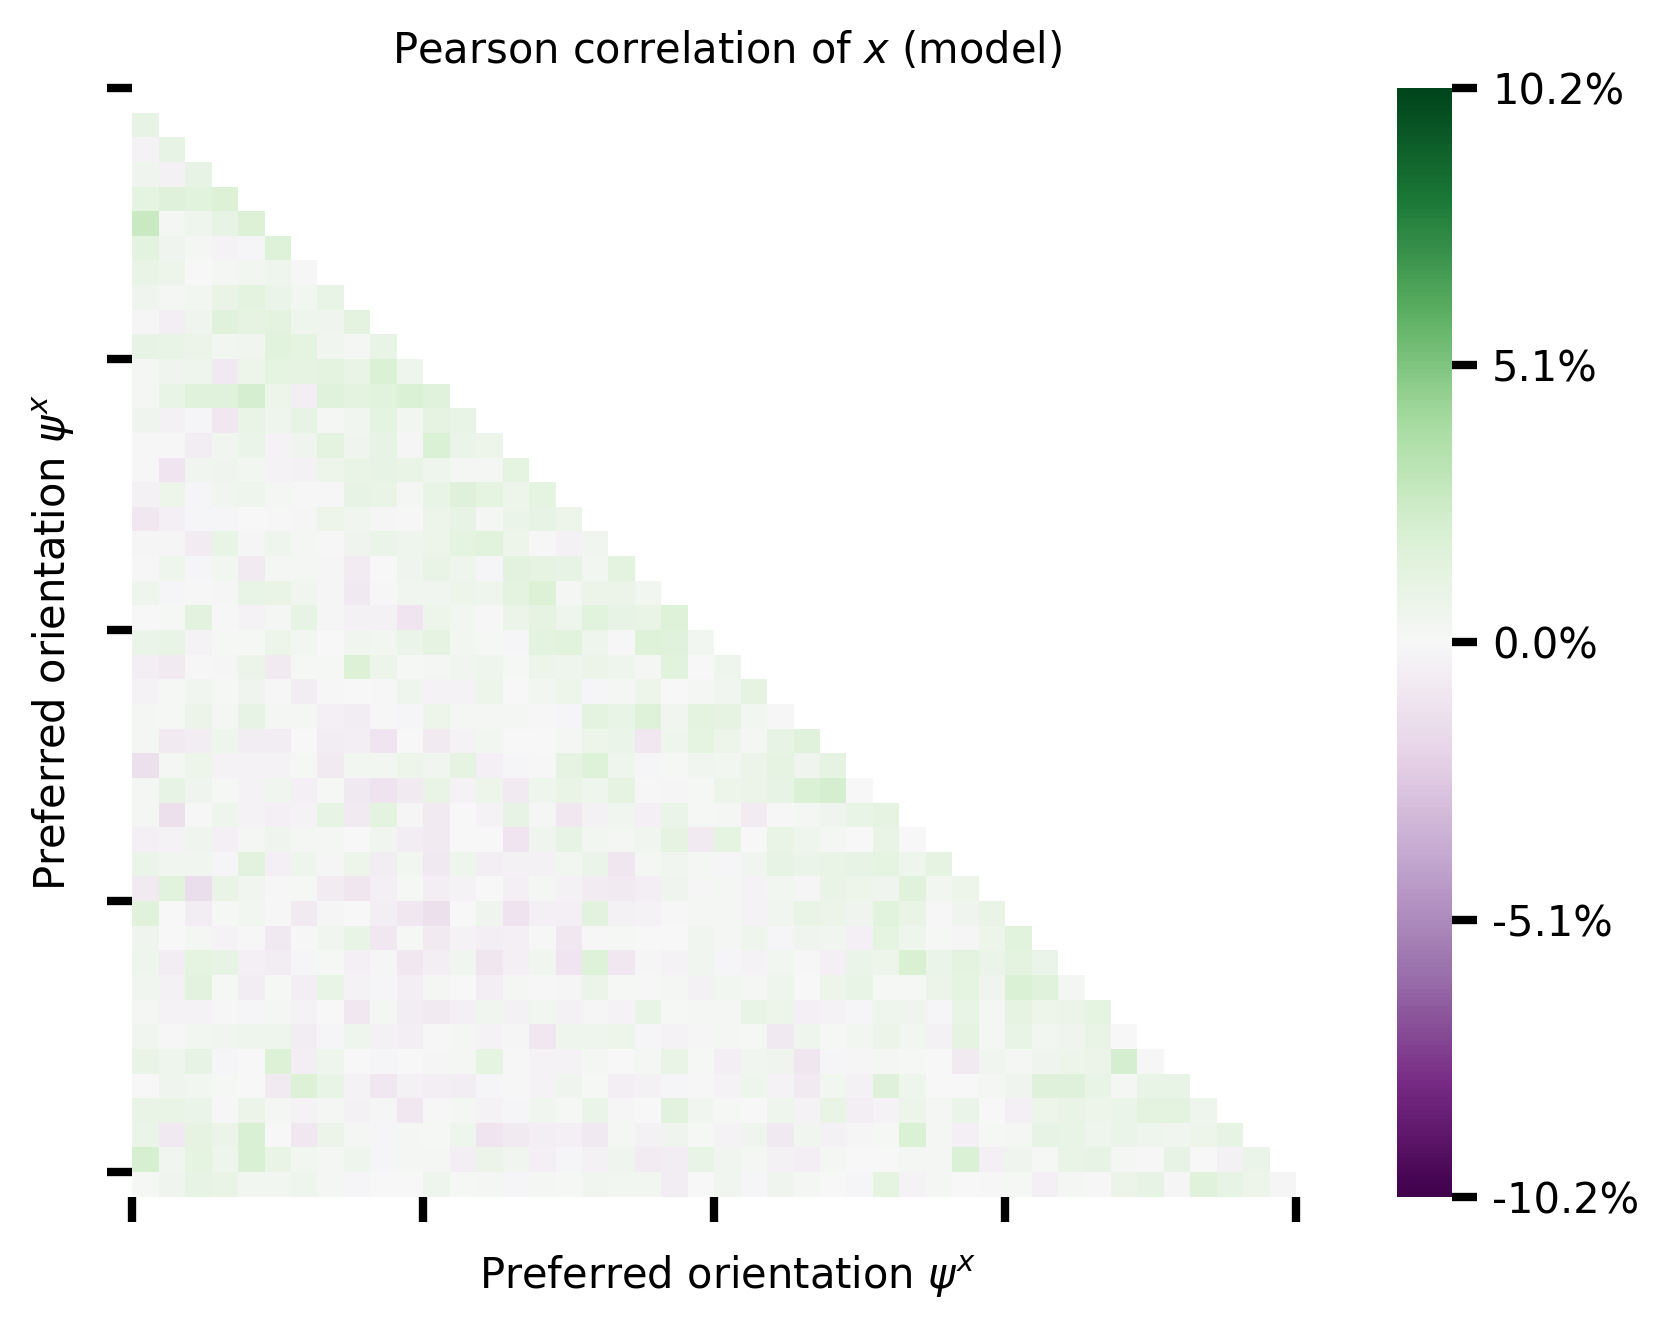

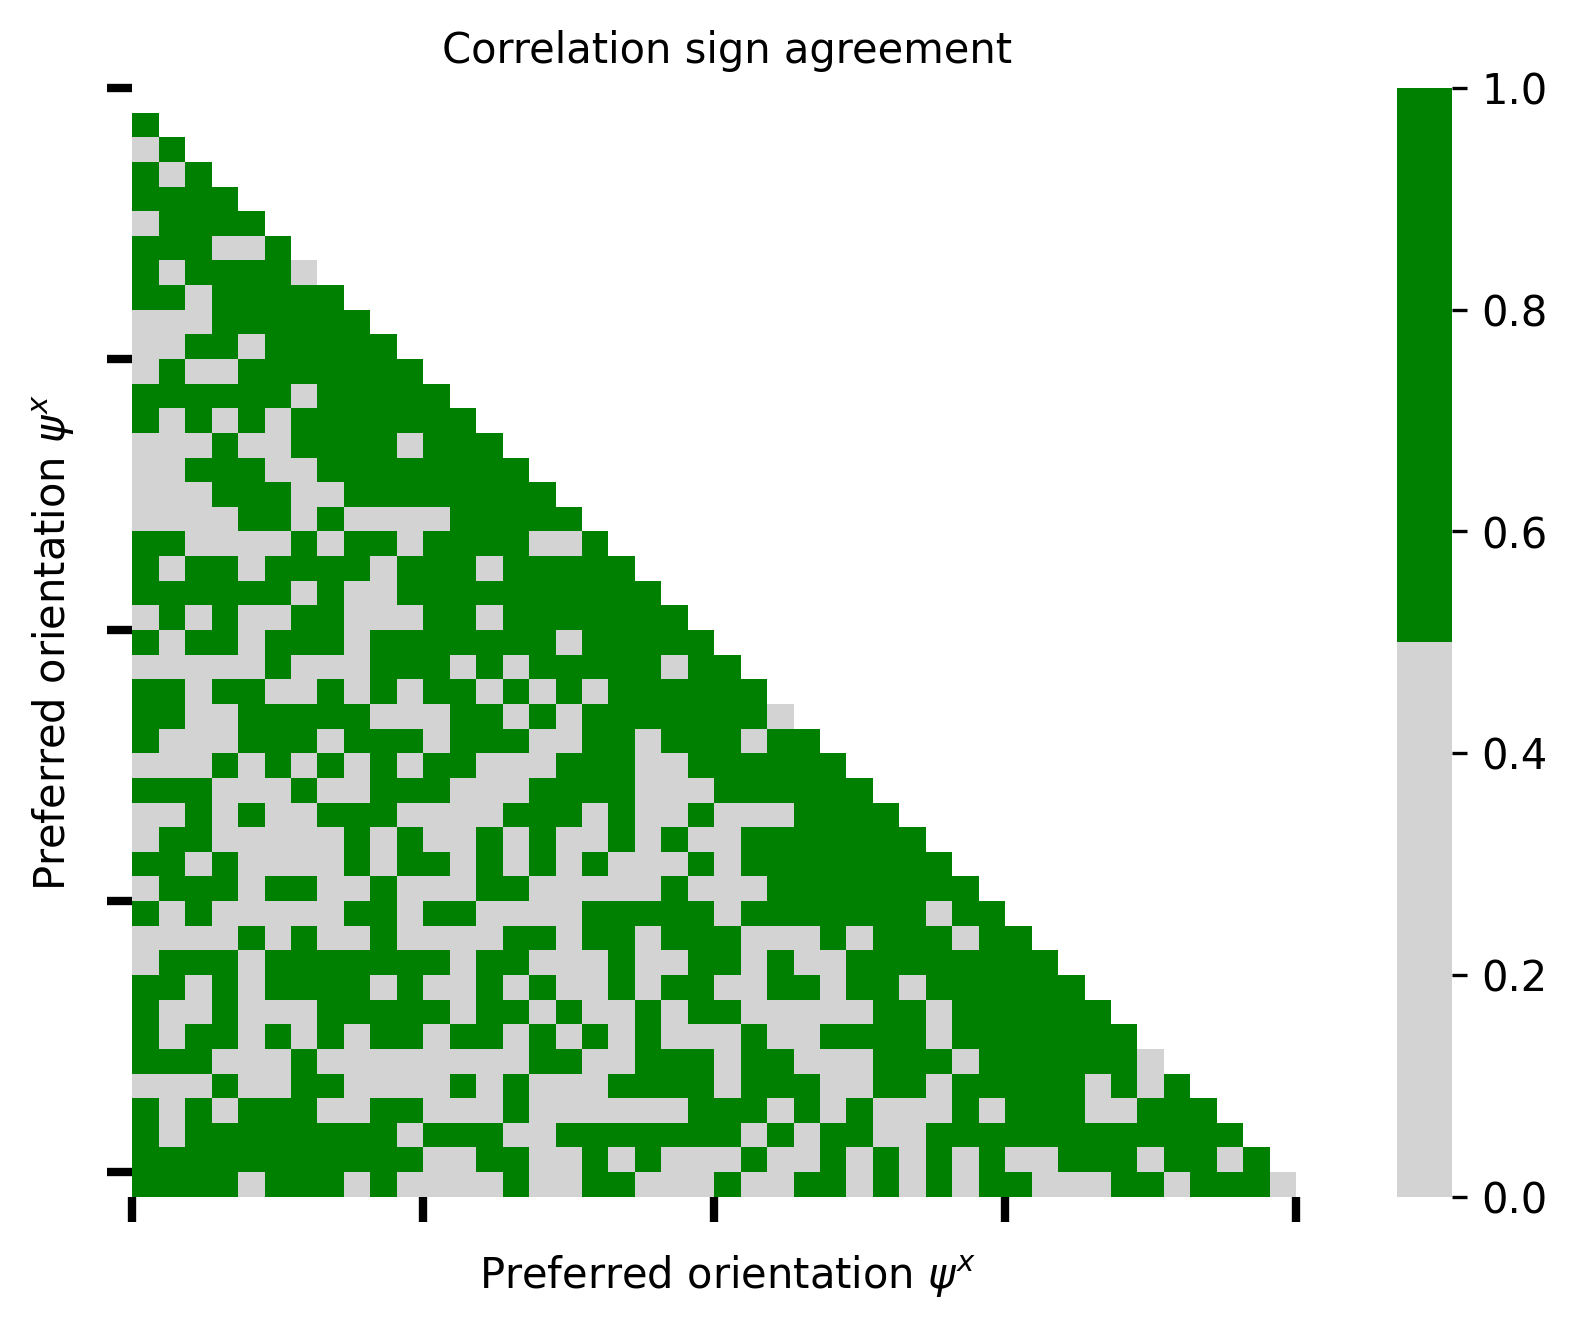

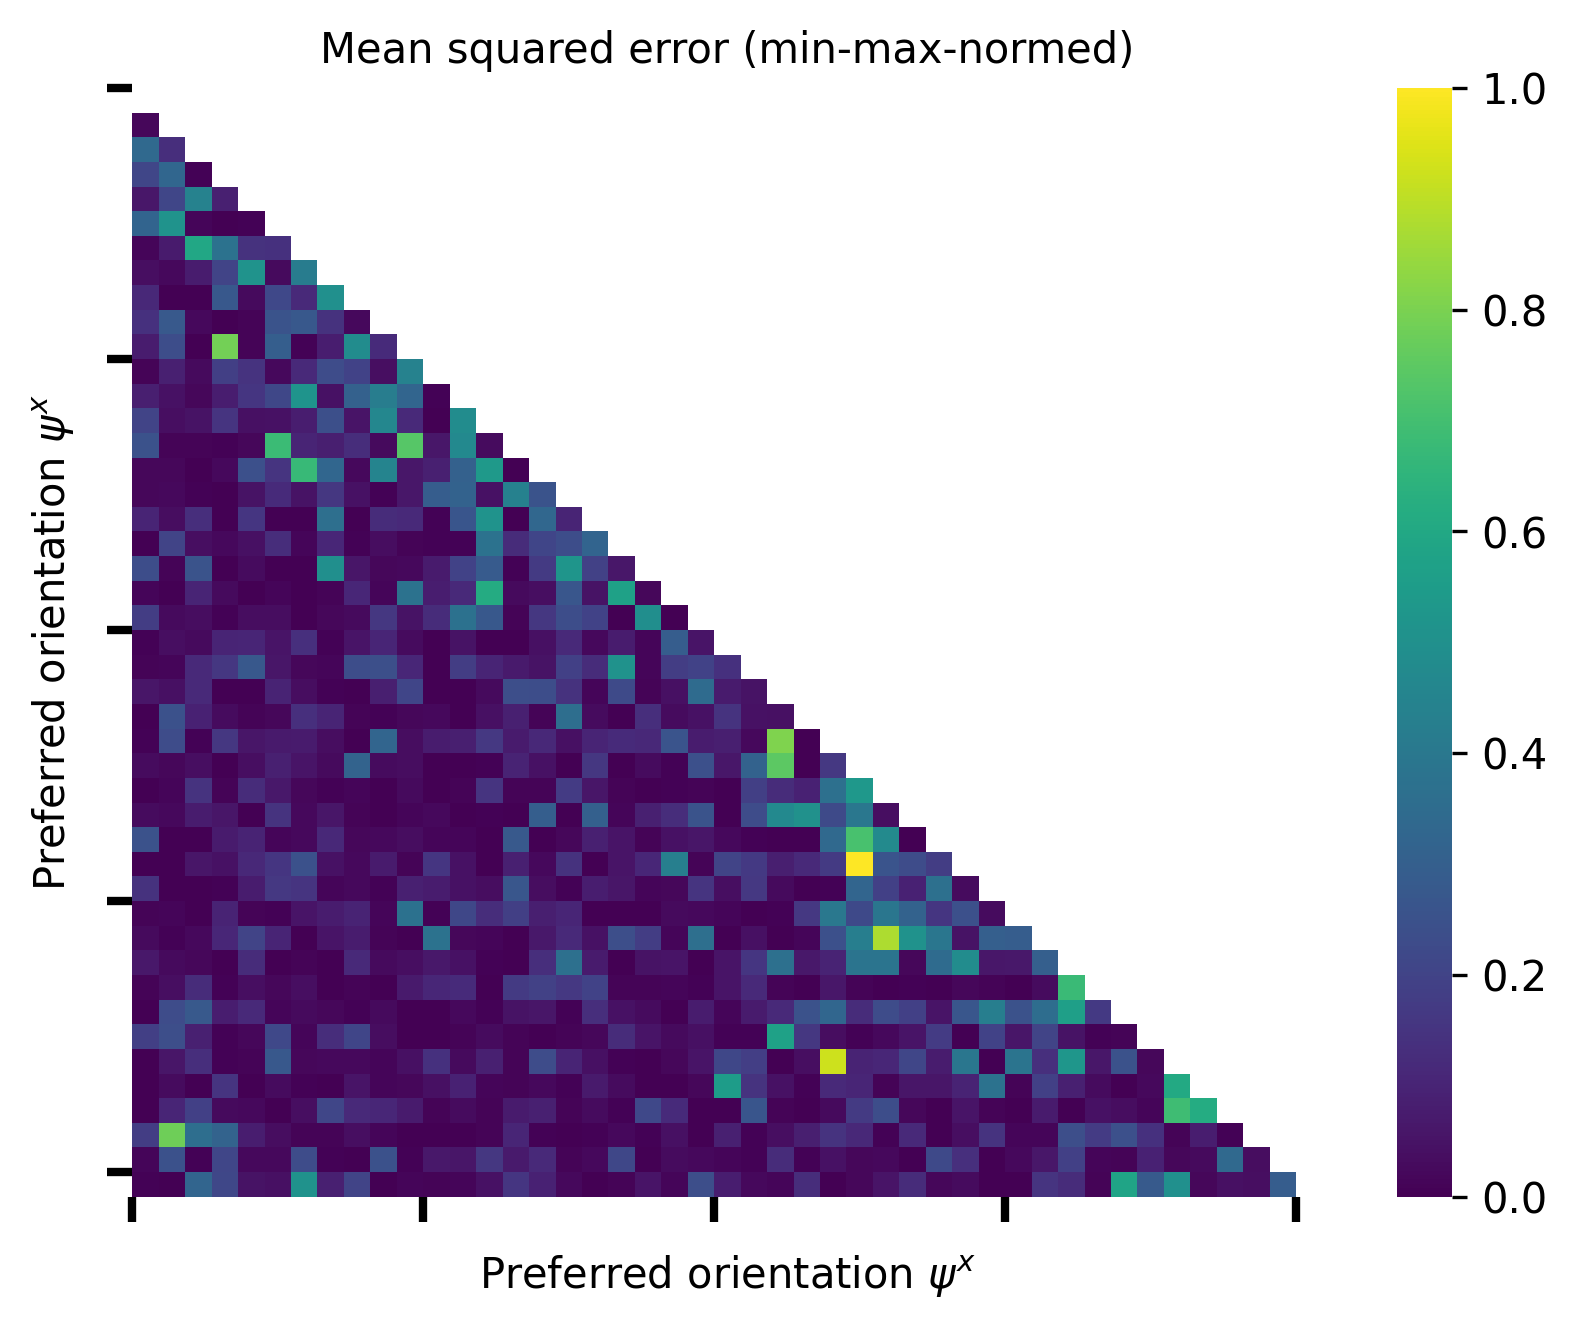

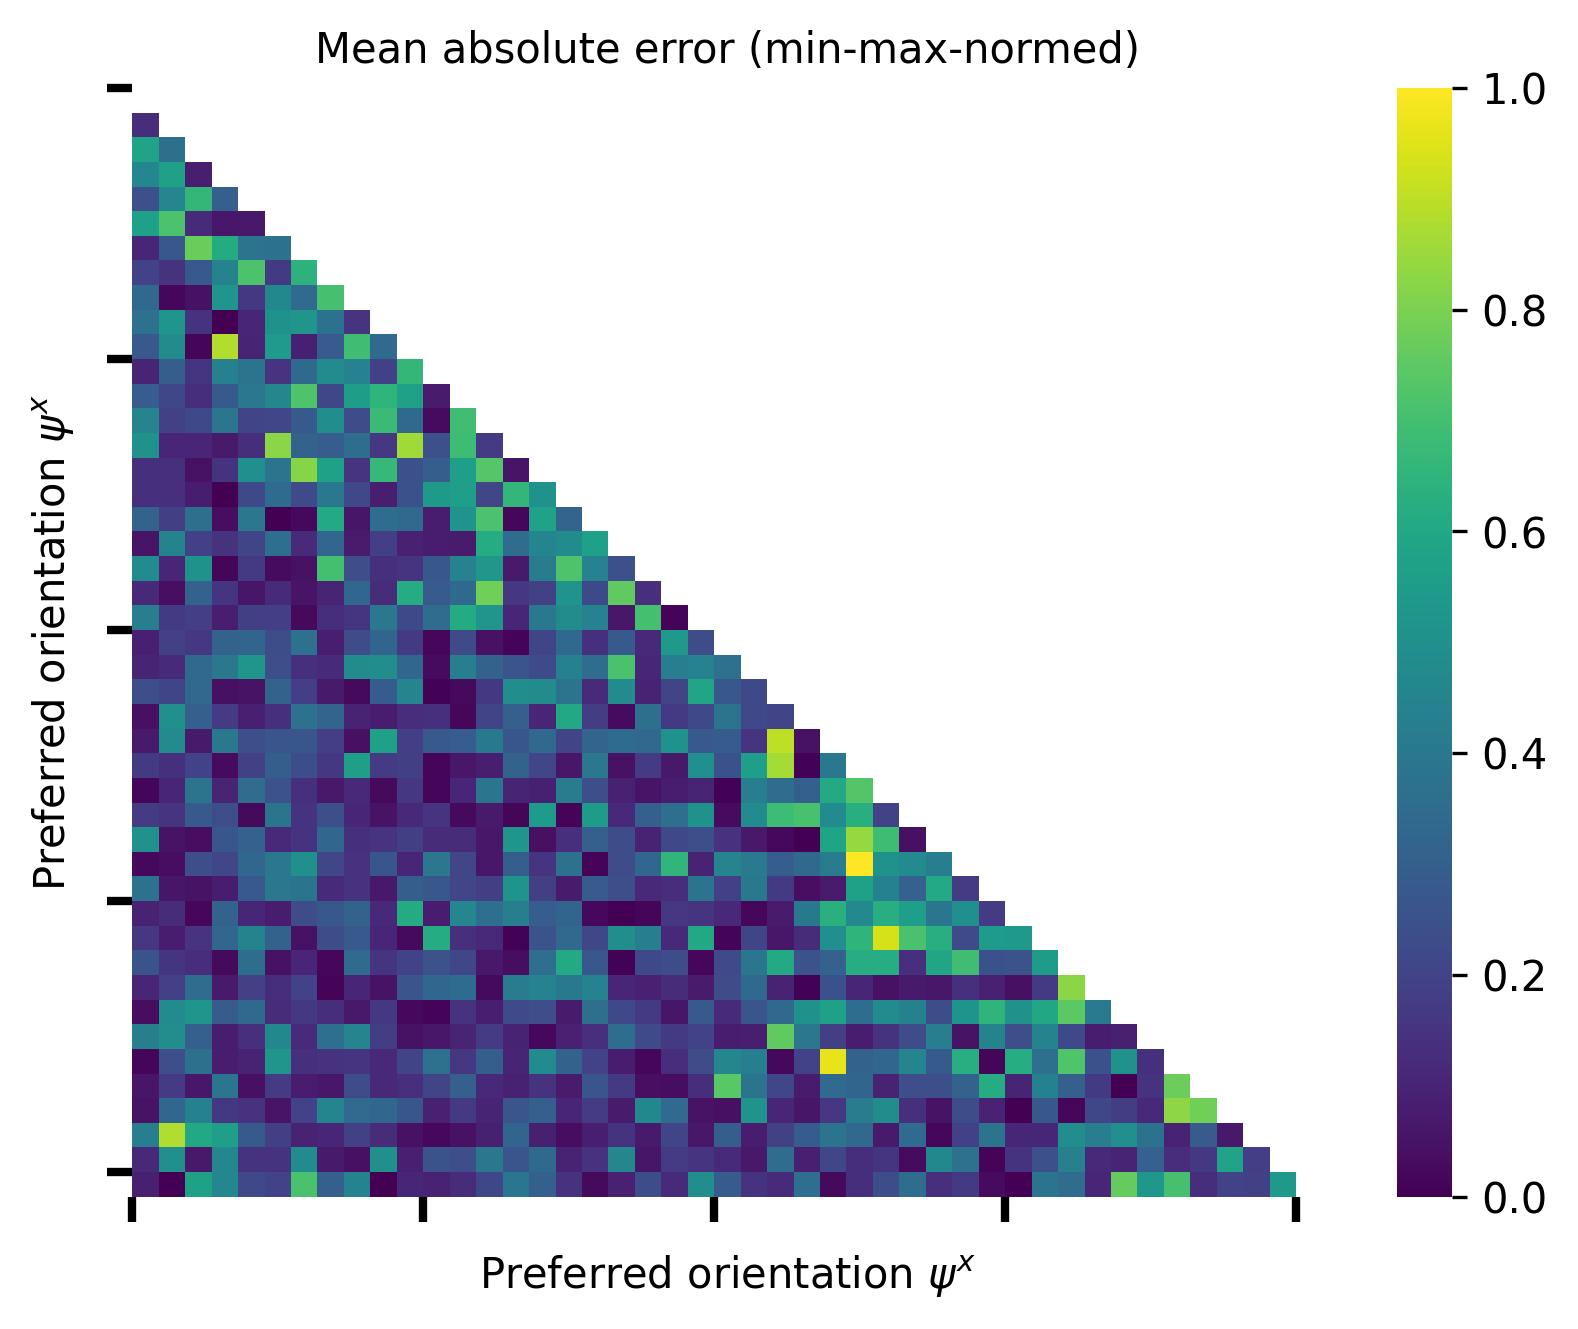

In [7]:
flow_path = best_val["model"]
flow_model = torch.load(flow_path)
flow_model.eval()
data_path = best_val["data_fname"]
train_prop = best_val["train_prop"]
val_prop = best_val["val_prop"]
batch_size = int(best_val["batch_size"])
train_loader, val_loader, test_loader = build_dataloaders(
    data_path, train_prop, val_prop, batch_size
)
output = evaluate_flow_prior(flow_model, val_loader)